In [4540]:
(* ============================================================ *)
(* S117A                                                        *)
(* DEEP DELAYED-DISTINGUISHABILITY STATE DISCOVERY              *)
(*                                                              *)
(* PURPOSE                                                      *)
(* ------------------------------------------------------------ *)
(* Stress-test the residual / future-equivalence state rule.    *)
(*                                                              *)
(* Many hidden states have IDENTICAL immediate output.          *)
(* Some pairs remain observationally identical for many future  *)
(* steps and can only be distinguished by a deep suffix.        *)
(*                                                              *)
(* Core state rule remains:                                     *)
(*                                                              *)
(*   p ~ q  iff  all future experiments give the same output.   *)
(*                                                              *)
(* We test whether the learner avoids premature Union/merge     *)
(* when short-horizon behavior is identical.                    *)
(*                                                              *)
(* LEARNER KNOWS                                                *)
(* ------------------------------------------------------------ *)
(* - input alphabet                                             *)
(* - final binary output                                        *)
(* - membership-query interface                                 *)
(* - counterexample/equivalence interface                       *)
(*                                                              *)
(* LEARNER IS NOT GIVEN                                         *)
(* ------------------------------------------------------------ *)
(* - hidden state count                                         *)
(* - hidden state semantics                                     *)
(* - hidden transition table                                    *)
(* - hidden delay depth                                         *)
(* - which states are deeply aliased                            *)
(* - distinguishing suffixes                                    *)
(* - intermediate hidden states                                 *)
(*                                                              *)
(* TRUE STRUCTURE AND DISTINGUISHABILITY DEPTH ARE AUDITED      *)
(* ONLY AFTER FREEZE.                                           *)
(* ============================================================ *)


ClearAll["Global`S117A*"];
ClearAll["Global`s117A*"];


s117AResult =
Catch[

(

(* ============================================================ *)
(* 0. FAIL SAFE                                                 *)
(* ============================================================ *)

S117AFail[msg_] := (
  Print["STOP: ", msg];
  Throw[$Failed, "S117A_STOP"];
);


Print["================================================"];
Print["S117A DEEP DELAYED-DISTINGUISHABILITY TEST"];
Print["================================================"];


(* ============================================================ *)
(* 1. PUBLIC TASK INTERFACE                                     *)
(* ============================================================ *)

alphabetS117A =
  {0, 1, 2};


Print[
  "Primitive alphabet = ",
  alphabetS117A
];


Print["Output alphabet = {0,1}"];
Print["NO STATE SEMANTICS GIVEN."];
Print["NO TRUE STATE COUNT GIVEN."];
Print["NO DELAY DEPTH GIVEN TO LEARNER."];
Print["LEARNER SEES FINAL BINARY OUTPUT ONLY."];
Print["STATE MERGING MUST FOLLOW FUTURE BEHAVIORAL EQUIVALENCE."];


(* ============================================================ *)
(* 2. PROSPECTIVE HOLDOUT                                       *)
(*                                                              *)
(* Created before learning.                                     *)
(* No outputs accessed before freeze.                           *)
(* ============================================================ *)

holdoutSeedS117A =
  1172001;


holdoutDepthsS117A =
  {
    40,
    100,
    250,
    500
  };


holdoutSequencesPerDepthS117A =
  100;


prospectiveHoldoutSeqsS117A =
  BlockRandom[

    SeedRandom[
      holdoutSeedS117A
    ];


    Flatten[
      Table[

        Table[

          <|

            "Depth" ->
              depth,

            "Sequence" ->
              RandomChoice[
                alphabetS117A,
                depth
              ]

          |>,

          {
            holdoutSequencesPerDepthS117A
          }
        ],

        {
          depth,
          holdoutDepthsS117A
        }
      ],

      1
    ]
  ];


Print[
  "Prospective holdout sequences = ",
  Length[
    prospectiveHoldoutSeqsS117A
  ]
];


Print[
  "Holdout depths = ",
  holdoutDepthsS117A
];


Print["HOLDOUT OUTPUTS REMAIN SEALED."];


(* ============================================================ *)
(* 3. HIDDEN DEEP-ALIASING ENVIRONMENT                          *)
(*                                                              *)
(* ENVIRONMENT ONLY.                                            *)
(*                                                              *)
(* Internal hidden structure deliberately contains a long       *)
(* delayed-distinguishability chain.                            *)
(*                                                              *)
(* Learner never receives these state IDs or their meaning.     *)
(* ============================================================ *)

hiddenDeepDepthS117A =
  20;


hiddenShallowEntryDepthS117A =
  4;


(* hidden states:
      1 = root
      2 = zero sink
      3 = delay-0
      4 = delay-1
      ...
   but these meanings are environment-only.
*)


S117ADelayState[
  depth_Integer
] :=
  3 + depth;


hiddenStartStateS117A =
  1;


S117AEnvStep[
  hiddenState_Integer,
  token_Integer
] :=
Module[
  {
    depth
  },


  Which[

    hiddenState === 1,

      Switch[
        token,

        0,
          S117ADelayState[
            hiddenShallowEntryDepthS117A
          ],

        1,
          S117ADelayState[
            hiddenDeepDepthS117A
          ],

        2,
          1,

        _,
          Missing[
            "UnknownToken"
          ]
      ],


    hiddenState === 2,

      2,


    hiddenState >= 3,

      depth =
        hiddenState - 3;


      If[
        depth == 0,

        2,

        Switch[
          token,

          0,
            2,

          1,
            2,

          2,
            S117ADelayState[
              depth - 1
            ],

          _,
            Missing[
              "UnknownToken"
            ]
        ]
      ],


    True,

      Missing[
        "UnknownHiddenState"
      ]

  ]
];


S117AEnvStateOutput[
  hiddenState_Integer
] :=
  Boole[
    hiddenState ===
      S117ADelayState[0]
  ];


S117AEnvStateAfter[
  seq_List
] :=
Module[
  {
    state
  },


  state =
    hiddenStartStateS117A;


  Do[

    state =
      S117AEnvStep[
        state,
        token
      ];


    If[
      MissingQ[state],

      Return[state]
    ],

    {
      token,
      seq
    }
  ];


  state
];


S117AEnvRawOutput[
  seq_List
] :=
Module[
  {
    state
  },


  state =
    S117AEnvStateAfter[
      seq
    ];


  If[
    MissingQ[state],

    Return[
      Missing[
        "EnvironmentFailure"
      ]
    ]
  ];


  S117AEnvStateOutput[
    state
  ]
];


(* ============================================================ *)
(* 4. MEMBERSHIP QUERY                                          *)
(* ============================================================ *)

membershipCacheS117A =
  <||>;


membershipUniqueCountS117A =
  0;


membershipTotalCallsS117A =
  0;


S117ASeqKey[
  seq_List
] :=
  ToString[
    InputForm[
      seq
    ]
  ];


S117AMembershipY[
  seq_List
] :=
Module[
  {
    key,
    y
  },


  membershipTotalCallsS117A++;


  key =
    S117ASeqKey[
      seq
    ];


  If[
    KeyExistsQ[
      membershipCacheS117A,
      key
    ],

    Return[
      Lookup[
        membershipCacheS117A,
        key
      ]
    ]
  ];


  y =
    S117AEnvRawOutput[
      seq
    ];


  If[
    !MemberQ[
      {0, 1},
      y
    ],

    S117AFail[
      "Membership oracle returned non-binary output."
    ]
  ];


  membershipUniqueCountS117A++;


  AssociateTo[
    membershipCacheS117A,
    key -> y
  ];


  y
];


(* ============================================================ *)
(* 5. RESIDUAL OBSERVATION TABLE                                *)
(* ============================================================ *)

prefixSetS117A =
  {
    {}
  };


suffixSetS117A =
  {
    {}
  };


S117ARow[
  prefix_List
] :=
  Table[

    S117AMembershipY[
      Join[
        prefix,
        suffix
      ]
    ],

    {
      suffix,
      suffixSetS117A
    }
  ];


S117ARowKey[
  row_List
] :=
  ToString[
    InputForm[
      row
    ]
  ];


S117AFrontier[] :=
  DeleteDuplicates[
    Flatten[
      Table[

        Append[
          prefix,
          token
        ],

        {
          prefix,
          prefixSetS117A
        },

        {
          token,
          alphabetS117A
        }
      ],

      1
    ]
  ];


(* ============================================================ *)
(* 6. CLOSEDNESS                                                *)
(* ============================================================ *)

S117AFindUnclosed[] :=
Module[
  {
    rowsInS,
    frontier
  },


  rowsInS =
    S117ARow /@
      prefixSetS117A;


  frontier =
    S117AFrontier[];


  SelectFirst[
    frontier,

    Function[
      candidate,

      !MemberQ[
        rowsInS,
        S117ARow[
          candidate
        ]
      ]
    ],

    Missing[
      "Closed"
    ]
  ]
];


(* ============================================================ *)
(* 7. CONSISTENCY                                               *)
(*                                                              *)
(* Two currently merged states cannot remain merged if the same *)
(* token sends them to distinguishable future residuals.        *)
(* ============================================================ *)

S117AFindInconsistency[] :=
Module[
  {
    n,
    i,
    j,
    p1,
    p2,
    row1,
    row2,
    successorRow1,
    successorRow2,
    diffPosition,
    oldSuffix,
    newSuffix
  },


  n =
    Length[
      prefixSetS117A
    ];


  For[
    i = 1,
    i <= n,
    i++,


    p1 =
      prefixSetS117A[[i]];


    row1 =
      S117ARow[
        p1
      ];


    For[
      j = i + 1,
      j <= n,
      j++,


      p2 =
        prefixSetS117A[[j]];


      row2 =
        S117ARow[
          p2
        ];


      If[
        row1 === row2,


        Do[

          successorRow1 =
            S117ARow[
              Append[
                p1,
                token
              ]
            ];


          successorRow2 =
            S117ARow[
              Append[
                p2,
                token
              ]
            ];


          If[
            successorRow1 =!=
              successorRow2,


            diffPosition =
              FirstPosition[
                MapThread[
                  Unequal,
                  {
                    successorRow1,
                    successorRow2
                  }
                ],
                True
              ];


            If[
              diffPosition ===
                Missing["NotFound"],

              S117AFail[
                "Consistency mismatch found without a distinguishing suffix."
              ]
            ];


            oldSuffix =
              suffixSetS117A[[
                diffPosition[[1]]
              ]];


            newSuffix =
              Join[
                {token},
                oldSuffix
              ];


            Return[
              <|

                "Prefix1" ->
                  p1,

                "Prefix2" ->
                  p2,

                "Token" ->
                  token,

                "OldSuffix" ->
                  oldSuffix,

                "NewSuffix" ->
                  newSuffix

              |>
            ];

          ],

          {
            token,
            alphabetS117A
          }
        ];
      ];

    ];

  ];


  Missing[
    "Consistent"
  ]
];


(* ============================================================ *)
(* 8. STABILIZE TABLE                                           *)
(* ============================================================ *)

tableRepairLogS117A =
  {};


S117AStabilizeTable[] :=
Module[
  {
    unclosed,
    inconsistency
  },


  While[
    True,


    unclosed =
      S117AFindUnclosed[];


    If[
      !MissingQ[
        unclosed
      ],


      AppendTo[
        prefixSetS117A,
        unclosed
      ];


      prefixSetS117A =
        DeleteDuplicates[
          prefixSetS117A
        ];


      AppendTo[
        tableRepairLogS117A,

        <|

          "Type" ->
            "Closure",

          "AddedPrefix" ->
            unclosed,

          "PrefixCount" ->
            Length[
              prefixSetS117A
            ],

          "SuffixCount" ->
            Length[
              suffixSetS117A
            ]

        |>
      ];


      Continue[];
    ];


    inconsistency =
      S117AFindInconsistency[];


    If[
      AssociationQ[
        inconsistency
      ],


      AppendTo[
        suffixSetS117A,
        inconsistency[
          "NewSuffix"
        ]
      ];


      suffixSetS117A =
        DeleteDuplicates[
          suffixSetS117A
        ];


      AppendTo[
        tableRepairLogS117A,

        <|

          "Type" ->
            "Consistency",

          "AddedSuffix" ->
            inconsistency[
              "NewSuffix"
            ],

          "AddedSuffixLength" ->
            Length[
              inconsistency[
                "NewSuffix"
              ]
            ],

          "PrefixCount" ->
            Length[
              prefixSetS117A
            ],

          "SuffixCount" ->
            Length[
              suffixSetS117A
            ]

        |>
      ];


      Continue[];
    ];


    Break[];

  ];

];


(* ============================================================ *)
(* 9. BUILD HYPOTHESIS                                          *)
(*                                                              *)
(* State identity = residual row only.                          *)
(* ============================================================ *)

S117ABuildHypothesis[] :=
Module[
  {
    rows,
    uniqueRows,
    rowToState,
    representativeByState,
    transitionAssoc,
    outputAssoc,
    i,
    rep,
    successorRow,
    successorState
  },


  rows =
    S117ARow /@
      prefixSetS117A;


  uniqueRows =
    DeleteDuplicates[
      rows
    ];


  rowToState =
    Association[
      Table[

        S117ARowKey[
          uniqueRows[[i]]
        ] ->
          i,

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  representativeByState =
    Association[
      Table[

        i ->

          SelectFirst[
            prefixSetS117A,

            Function[
              prefix,

              S117ARow[
                prefix
              ] ===
                uniqueRows[[i]]
            ]
          ],

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  transitionAssoc =
    <||>;


  outputAssoc =
    <||>;


  Do[

    rep =
      Lookup[
        representativeByState,
        i
      ];


    AssociateTo[
      outputAssoc,
      i ->
        S117AMembershipY[
          rep
        ]
    ];


    Do[

      successorRow =
        S117ARow[
          Append[
            rep,
            token
          ]
        ];


      successorState =
        Lookup[
          rowToState,

          S117ARowKey[
            successorRow
          ],

          Missing[
            "UnclosedTransition"
          ]
        ];


      If[
        MissingQ[
          successorState
        ],

        S117AFail[
          "Hypothesis construction encountered an unclosed transition."
        ]
      ];


      AssociateTo[
        transitionAssoc,

        ToString[
          InputForm[
            {
              i,
              token
            }
          ]
        ] ->
          successorState
      ],

      {
        token,
        alphabetS117A
      }
    ],

    {
      i,
      Length[
        uniqueRows
      ]
    }
  ];


  <|

    "StateCount" ->
      Length[
        uniqueRows
      ],

    "Rows" ->
      uniqueRows,

    "RowToState" ->
      rowToState,

    "RepresentativeByState" ->
      representativeByState,

    "Transitions" ->
      transitionAssoc,

    "Outputs" ->
      outputAssoc,

    "StartState" ->
      Lookup[
        rowToState,

        S117ARowKey[
          S117ARow[
            {}
          ]
        ]
      ]

  |>
];


(* ============================================================ *)
(* 10. HYPOTHESIS EXECUTION                                     *)
(* ============================================================ *)

S117AHypothesisTransitionKey[
  state_Integer,
  token_Integer
] :=
  ToString[
    InputForm[
      {
        state,
        token
      }
    ]
  ];


S117AHypothesisStep[
  hypothesis_Association,
  state_Integer,
  token_Integer
] :=
  Lookup[
    hypothesis[
      "Transitions"
    ],

    S117AHypothesisTransitionKey[
      state,
      token
    ],

    Missing[
      "UnknownTransition"
    ]
  ];


S117AHypothesisStateAfter[
  hypothesis_Association,
  seq_List
] :=
Module[
  {
    state
  },


  state =
    hypothesis[
      "StartState"
    ];


  Do[

    state =
      S117AHypothesisStep[
        hypothesis,
        state,
        token
      ];


    If[
      MissingQ[state],
      Return[state]
    ],

    {
      token,
      seq
    }
  ];


  state
];


S117AHypothesisOutput[
  hypothesis_Association,
  seq_List
] :=
Module[
  {
    state
  },


  state =
    S117AHypothesisStateAfter[
      hypothesis,
      seq
    ];


  If[
    MissingQ[state],

    Return[
      Missing[
        "UnknownTransition"
      ]
    ]
  ];


  Lookup[
    hypothesis[
      "Outputs"
    ],

    state,

    Missing[
      "UnknownState"
    ]
  ]
];


(* ============================================================ *)
(* 11. EQUIVALENCE / COUNTEREXAMPLE ORACLE                      *)
(*                                                              *)
(* As in S116A, teacher returns only:                            *)
(* - Equivalent                                                 *)
(* - OR one shortest counterexample INPUT sequence              *)
(*                                                              *)
(* No hidden state or transition is exposed.                    *)
(* ============================================================ *)

equivalenceQueryCountS117A =
  0;


counterexampleLogS117A =
  {};


S117AEquivalenceCounterexample[
  hypothesis_Association
] :=
Module[
  {
    queue,
    visited,
    current,
    learnedState,
    trueState,
    seq,
    pairKey,
    learnedOutput,
    trueOutput,
    token,
    learnedNext,
    trueNext,
    nextKey
  },


  equivalenceQueryCountS117A++;


  queue =
    {
      {
        hypothesis[
          "StartState"
        ],
        hiddenStartStateS117A,
        {}
      }
    };


  visited =
    <||>;


  While[
    Length[
      queue
    ] > 0,


    current =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    learnedState =
      current[[1]];


    trueState =
      current[[2]];


    seq =
      current[[3]];


    pairKey =
      ToString[
        InputForm[
          {
            learnedState,
            trueState
          }
        ]
      ];


    If[
      KeyExistsQ[
        visited,
        pairKey
      ],

      Continue[]
    ];


    AssociateTo[
      visited,
      pairKey -> True
    ];


    learnedOutput =
      Lookup[
        hypothesis[
          "Outputs"
        ],

        learnedState,

        Missing[
          "UnknownOutput"
        ]
      ];


    trueOutput =
      S117AEnvStateOutput[
        trueState
      ];


    If[
      learnedOutput =!=
        trueOutput,

      Return[
        seq
      ]
    ];


    Do[

      learnedNext =
        S117AHypothesisStep[
          hypothesis,
          learnedState,
          token
        ];


      If[
        MissingQ[
          learnedNext
        ],

        Return[
          Append[
            seq,
            token
          ]
        ]
      ];


      trueNext =
        S117AEnvStep[
          trueState,
          token
        ];


      nextKey =
        ToString[
          InputForm[
            {
              learnedNext,
              trueNext
            }
          ]
        ];


      If[
        !KeyExistsQ[
          visited,
          nextKey
        ],

        AppendTo[
          queue,

          {
            learnedNext,
            trueNext,
            Append[
              seq,
              token
            ]
          }
        ];
      ],

      {
        token,
        alphabetS117A
      }
    ];

  ];


  Missing[
    "Equivalent"
  ]
];


(* ============================================================ *)
(* 12. COUNTEREXAMPLE REFINEMENT                                *)
(* ============================================================ *)

S117APrefixesOf[
  seq_List
] :=
  Table[

    Take[
      seq,
      k
    ],

    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S117ASuffixesOf[
  seq_List
] :=
  Table[

    Drop[
      seq,
      k
    ],

    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S117ARefineFromCounterexample[
  counterexample_List
] :=
Module[
  {
    newPrefixes,
    newSuffixes
  },


  newPrefixes =
    S117APrefixesOf[
      counterexample
    ];


  newSuffixes =
    S117ASuffixesOf[
      counterexample
    ];


  prefixSetS117A =
    DeleteDuplicates[
      Join[
        prefixSetS117A,
        newPrefixes
      ]
    ];


  suffixSetS117A =
    DeleteDuplicates[
      Join[
        suffixSetS117A,
        newSuffixes
      ]
    ];

];


(* ============================================================ *)
(* 13. ACTIVE LEARNING LOOP                                     *)
(* ============================================================ *)

learningRoundS117A =
  0;


learningRoundLogS117A =
  {};


candidateHypothesisS117A =
  Missing[
    "NotBuilt"
  ];


equivalentSignalS117A =
  False;


Print["================================================"];
Print["ACTIVE DEEP-RESIDUAL LEARNING"];
Print["================================================"];


learningTimingS117A =
  AbsoluteTiming[

    While[
      !TrueQ[
        equivalentSignalS117A
      ],


      learningRoundS117A++;


      If[
        learningRoundS117A > 100,

        S117AFail[
          "Learning-round safety guard exceeded 100."
        ]
      ];


      S117AStabilizeTable[];


      candidateHypothesisS117A =
        S117ABuildHypothesis[];


      counterexampleS117A =
        S117AEquivalenceCounterexample[
          candidateHypothesisS117A
        ];


      If[
        MissingQ[
          counterexampleS117A
        ],


        equivalentSignalS117A =
          True;


        AppendTo[
          learningRoundLogS117A,

          <|

            "Round" ->
              learningRoundS117A,

            "CandidateStates" ->
              candidateHypothesisS117A[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS117A
              ],

            "SuffixCount" ->
              Length[
                suffixSetS117A
              ],

            "MaxSuffixLength" ->
              Max[
                Length /@
                  suffixSetS117A
              ],

            "MembershipQueries" ->
              membershipUniqueCountS117A,

            "Counterexample" ->
              "Equivalent",

            "CounterexampleLength" ->
              Missing[
                "Equivalent"
              ]

          |>
        ],


        AppendTo[
          counterexampleLogS117A,
          counterexampleS117A
        ];


        AppendTo[
          learningRoundLogS117A,

          <|

            "Round" ->
              learningRoundS117A,

            "CandidateStates" ->
              candidateHypothesisS117A[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS117A
              ],

            "SuffixCount" ->
              Length[
                suffixSetS117A
              ],

            "MaxSuffixLength" ->
              Max[
                Length /@
                  suffixSetS117A
              ],

            "MembershipQueries" ->
              membershipUniqueCountS117A,

            "Counterexample" ->
              counterexampleS117A,

            "CounterexampleLength" ->
              Length[
                counterexampleS117A
              ]

          |>
        ];


        S117ARefineFromCounterexample[
          counterexampleS117A
        ];
      ];


      Print[
        "Round ",
        learningRoundS117A,
        ": states = ",
        candidateHypothesisS117A[
          "StateCount"
        ],
        ", prefixes = ",
        Length[
          prefixSetS117A
        ],
        ", suffixes = ",
        Length[
          suffixSetS117A
        ],
        ", max suffix length = ",
        Max[
          Length /@
            suffixSetS117A
        ],
        ", membership queries = ",
        membershipUniqueCountS117A,
        ", EQ = ",
        If[
          equivalentSignalS117A,

          "Equivalent",

          StringJoin[
            "counterexample length ",
            ToString[
              Length[
                counterexampleS117A
              ]
            ]
          ]
        ]
      ];

    ];

  ];


Print[
  "Learning seconds = ",
  N[
    learningTimingS117A[[1]]
  ]
];


Print[
  "Learning rounds = ",
  learningRoundS117A
];


Print[
  "Equivalence queries = ",
  equivalenceQueryCountS117A
];


Print[
  "Counterexamples = ",
  Length[
    counterexampleLogS117A
  ]
];


Print[
  "Final residual states = ",
  candidateHypothesisS117A[
    "StateCount"
  ]
];


Print[
  "Final distinguishing suffixes = ",
  Length[
    suffixSetS117A
  ]
];


Print[
  "Maximum learned suffix length = ",
  Max[
    Length /@
      suffixSetS117A
  ]
];


Print[
  "Membership queries = ",
  membershipUniqueCountS117A
];


(* ============================================================ *)
(* 14. HOLDOUT LEAKAGE                                          *)
(* ============================================================ *)

holdoutTouchedBeforeFreezeS117A =
  Count[
    prospectiveHoldoutSeqsS117A,

    row_Association /;

      KeyExistsQ[
        membershipCacheS117A,

        S117ASeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


Print[
  "Holdout sequences touched before freeze = ",
  holdoutTouchedBeforeFreezeS117A,
  " / ",
  Length[
    prospectiveHoldoutSeqsS117A
  ]
];


(* ============================================================ *)
(* 15. FREEZE                                                   *)
(* ============================================================ *)

frozenHypothesisS117A =
  candidateHypothesisS117A;


frozenSuffixSetS117A =
  suffixSetS117A;


membershipQueriesBeforeFreezeS117A =
  membershipUniqueCountS117A;


frozenMachineHashS117A =
  Hash[
    {
      frozenHypothesisS117A[
        "StateCount"
      ],
      frozenHypothesisS117A[
        "Transitions"
      ],
      frozenHypothesisS117A[
        "Outputs"
      ],
      frozenHypothesisS117A[
        "StartState"
      ],
      frozenHypothesisS117A[
        "RepresentativeByState"
      ],
      frozenSuffixSetS117A
    },

    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S117A MACHINE FROZEN"];


Print[
  "States = ",
  frozenHypothesisS117A[
    "StateCount"
  ]
];


Print[
  "Transitions = ",
  Length[
    frozenHypothesisS117A[
      "Transitions"
    ]
  ]
];


Print[
  "Distinguishing suffixes = ",
  Length[
    frozenSuffixSetS117A
  ]
];


Print[
  "Max learned suffix length = ",
  Max[
    Length /@
      frozenSuffixSetS117A
  ]
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS117A
];


Print[
  "Machine hash = ",
  frozenMachineHashS117A
];


Print["NO LEARNED STATE OR TRANSITION CHANGES AFTER THIS POINT."];
Print["================================================"];


(* ============================================================ *)
(* 16. PROSPECTIVE LONG HOLDOUT                                 *)
(* ============================================================ *)

Print["================================================"];
Print["OPENING LONG HOLDOUT AFTER FREEZE"];
Print["================================================"];


holdoutRowsS117A =
  Table[

    Module[
      {
        seq,
        learnedY,
        trueY
      },


      seq =
        row[
          "Sequence"
        ];


      learnedY =
        S117AHypothesisOutput[
          frozenHypothesisS117A,
          seq
        ];


      trueY =
        S117AMembershipY[
          seq
        ];


      <|

        "Depth" ->
          row["Depth"],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY ===
              trueY
          )

      |>

    ],

    {
      row,
      prospectiveHoldoutSeqsS117A
    }
  ];


holdoutMatchesS117A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      holdoutRowsS117A,
    True
  ];


holdoutAccuracyS117A =
  N[
    holdoutMatchesS117A /
      Length[
        holdoutRowsS117A
      ]
  ];


holdoutPerDepthS117A =
  Table[

    Module[
      {
        rows,
        matches
      },


      rows =
        Select[
          holdoutRowsS117A,
          #["Depth"] === depth &
        ];


      matches =
        Count[
          (
            TrueQ[
              #["Match"]
            ] &
          ) /@
            rows,
          True
        ];


      <|

        "Depth" ->
          depth,

        "Sequences" ->
          Length[
            rows
          ],

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      depth,
      holdoutDepthsS117A
    }
  ];


Print[
  "Prospective holdout = ",
  holdoutMatchesS117A,
  " / ",
  Length[
    holdoutRowsS117A
  ]
];


(* ============================================================ *)
(* 17. EXHAUSTIVE SHORT AUDIT                                   *)
(* ============================================================ *)

auditMaxLengthS117A =
  7;


auditSequencesS117A =
  Flatten[
    Table[

      Tuples[
        alphabetS117A,
        len
      ],

      {
        len,
        0,
        auditMaxLengthS117A
      }
    ],

    1
  ];


auditRowsS117A =
  Table[

    Module[
      {
        learnedY,
        trueY
      },


      learnedY =
        S117AHypothesisOutput[
          frozenHypothesisS117A,
          seq
        ];


      trueY =
        S117AMembershipY[
          seq
        ];


      <|

        "Length" ->
          Length[
            seq
          ],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY ===
              trueY
          )

      |>

    ],

    {
      seq,
      auditSequencesS117A
    }
  ];


auditMatchesS117A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      auditRowsS117A,
    True
  ];


auditAccuracyS117A =
  N[
    auditMatchesS117A /
      Length[
        auditRowsS117A
      ]
  ];


Print[
  "Exhaustive length 0..",
  auditMaxLengthS117A,
  " = ",
  auditMatchesS117A,
  " / ",
  Length[
    auditRowsS117A
  ]
];


(* ============================================================ *)
(* 18. VERIFY FROZEN HASH                                       *)
(* ============================================================ *)

recomputedFrozenHashS117A =
  Hash[
    {
      frozenHypothesisS117A[
        "StateCount"
      ],
      frozenHypothesisS117A[
        "Transitions"
      ],
      frozenHypothesisS117A[
        "Outputs"
      ],
      frozenHypothesisS117A[
        "StartState"
      ],
      frozenHypothesisS117A[
        "RepresentativeByState"
      ],
      frozenSuffixSetS117A
    },

    "SHA256",
    "HexString"
  ];


frozenHashMatchesS117A =
  recomputedFrozenHashS117A ===
    frozenMachineHashS117A;


Print[
  "Frozen hash unchanged = ",
  frozenHashMatchesS117A
];


If[
  !TrueQ[
    frozenHashMatchesS117A
  ],

  S117AFail[
    "Frozen machine changed after freeze."
  ]
];


(* ============================================================ *)
(* 19. POST-HOC TRUE REACHABLE STATES                           *)
(* ============================================================ *)

Print["================================================"];
Print["POST-HOC DEEP-DISTINGUISHABILITY AUDIT"];
Print["================================================"];


S117ATrueReachableStates[] :=
Module[
  {
    seen,
    queue,
    current,
    next
  },


  seen =
    {
      hiddenStartStateS117A
    };


  queue =
    {
      hiddenStartStateS117A
    };


  While[
    Length[
      queue
    ] > 0,


    current =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    Do[

      next =
        S117AEnvStep[
          current,
          token
        ];


      If[
        !MemberQ[
          seen,
          next
        ],

        AppendTo[
          seen,
          next
        ];


        AppendTo[
          queue,
          next
        ];
      ],

      {
        token,
        alphabetS117A
      }
    ];

  ];


  Sort[
    seen
  ]
];


trueReachableStatesS117A =
  S117ATrueReachableStates[];


trueReachableCountS117A =
  Length[
    trueReachableStatesS117A
  ];


Print[
  "Post-hoc true reachable states = ",
  trueReachableCountS117A
];


(* ============================================================ *)
(* 20. IMMEDIATE OBSERVABILITY / ALIASING AUDIT                 *)
(* ============================================================ *)

immediateOutputGroupsS117A =
  Values[
    GroupBy[
      trueReachableStatesS117A,

      Function[
        state,
        S117AEnvStateOutput[
          state
        ]
      ]
    ]
  ];


immediateOutputBlockSizesS117A =
  Reverse[
    Sort[
      Length /@
        immediateOutputGroupsS117A
    ]
  ];


totalTrueStatePairsS117A =
  Binomial[
    trueReachableCountS117A,
    2
  ];


sameImmediateOutputPairsS117A =
  Total[
    Binomial[
      #,
      2
    ] & /@
      immediateOutputBlockSizesS117A
  ];


immediateAliasFractionS117A =
  N[
    sameImmediateOutputPairsS117A /
      totalTrueStatePairsS117A
  ];


Print[
  "Immediate-output block sizes = ",
  immediateOutputBlockSizesS117A
];


Print[
  "State pairs identical at immediate output = ",
  sameImmediateOutputPairsS117A,
  " / ",
  totalTrueStatePairsS117A
];


Print[
  "Immediate alias fraction = ",
  immediateAliasFractionS117A
];


(* ============================================================ *)
(* 21. TRUE MINIMALITY                                          *)
(* ============================================================ *)

S117ATrueMinimalPartition[] :=
Module[
  {
    partition,
    stateToBlock,
    signatures,
    newPartition,
    oldCanonical,
    newCanonical
  },


  partition =
    Values[
      GroupBy[
        trueReachableStatesS117A,

        Function[
          state,
          S117AEnvStateOutput[
            state
          ]
        ]
      ]
    ];


  While[
    True,


    stateToBlock =
      Association[
        Flatten[
          Table[

            Table[
              state -> blockIndex,

              {
                state,
                partition[[blockIndex]]
              }
            ],

            {
              blockIndex,
              Length[
                partition
              ]
            }
          ]
        ]
      ];


    signatures =
      Association[
        Table[

          state ->

            Join[
              {
                S117AEnvStateOutput[
                  state
                ]
              },

              Table[
                Lookup[
                  stateToBlock,

                  S117AEnvStep[
                    state,
                    token
                  ]
                ],

                {
                  token,
                  alphabetS117A
                }
              ]
            ],

          {
            state,
            trueReachableStatesS117A
          }
        ]
      ];


    newPartition =
      Values[
        GroupBy[
          trueReachableStatesS117A,

          Function[
            state,
            Lookup[
              signatures,
              state
            ]
          ]
        ]
      ];


    oldCanonical =
      Sort[
        Sort /@
          partition
      ];


    newCanonical =
      Sort[
        Sort /@
          newPartition
      ];


    If[
      newCanonical ===
        oldCanonical,

      Break[]
    ];


    partition =
      newPartition;

  ];


  partition
];


trueMinimalPartitionS117A =
  S117ATrueMinimalPartition[];


trueMinimalStateCountS117A =
  Length[
    trueMinimalPartitionS117A
  ];


trueMachineMinimalS117A =
  And[
    trueMinimalStateCountS117A ==
      trueReachableCountS117A,

    AllTrue[
      trueMinimalPartitionS117A,
      Length[#] == 1 &
    ]
  ];


Print[
  "True behavioral-minimal states = ",
  trueMinimalStateCountS117A
];


Print[
  "True machine minimal = ",
  trueMachineMinimalS117A
];


(* ============================================================ *)
(* 22. BOUNDED-HORIZON STATE-SEPARATION PROFILE                 *)
(*                                                              *)
(* Critical S117 audit.                                         *)
(*                                                              *)
(* Depth d means states may only be distinguished using future  *)
(* experiments of length <= d.                                  *)
(*                                                              *)
(* If short-horizon reasoning is insufficient, class count      *)
(* remains below the true minimal-state count.                  *)
(* ============================================================ *)

boundedAuditMaxDepthS117A =
  20;


S117ABoundedPartitionProfile[
  maxDepth_Integer
] :=
Module[
  {
    partition,
    profile,
    stateToBlock,
    signatures,
    depth
  },


  partition =
    Values[
      GroupBy[
        trueReachableStatesS117A,

        Function[
          state,
          S117AEnvStateOutput[
            state
          ]
        ]
      ]
    ];


  profile =
    {
      <|

        "FutureDepth" ->
          0,

        "BehaviorClasses" ->
          Length[
            partition
          ]

      |>
    };


  Do[

    stateToBlock =
      Association[
        Flatten[
          Table[

            Table[
              state -> blockIndex,

              {
                state,
                partition[[blockIndex]]
              }
            ],

            {
              blockIndex,
              Length[
                partition
              ]
            }
          ]
        ]
      ];


    signatures =
      Association[
        Table[

          state ->

            Join[
              {
                S117AEnvStateOutput[
                  state
                ]
              },

              Table[
                Lookup[
                  stateToBlock,

                  S117AEnvStep[
                    state,
                    token
                  ]
                ],

                {
                  token,
                  alphabetS117A
                }
              ]
            ],

          {
            state,
            trueReachableStatesS117A
          }
        ]
      ];


    partition =
      Values[
        GroupBy[
          trueReachableStatesS117A,

          Function[
            state,
            Lookup[
              signatures,
              state
            ]
          ]
        ]
      ];


    AppendTo[
      profile,

      <|

        "FutureDepth" ->
          depth,

        "BehaviorClasses" ->
          Length[
            partition
          ]

      |>
    ],

    {
      depth,
      1,
      maxDepth
    }
  ];


  profile
];


boundedPartitionProfileS117A =
  S117ABoundedPartitionProfile[
    boundedAuditMaxDepthS117A
  ];


fullSeparationRowsS117A =
  Select[
    boundedPartitionProfileS117A,

    #["BehaviorClasses"] ===
      trueMinimalStateCountS117A &
  ];


firstFullSeparationDepthS117A =
  If[
    Length[
      fullSeparationRowsS117A
    ] > 0,

    First[
      fullSeparationRowsS117A
    ][
      "FutureDepth"
    ],

    Missing[
      "NotFullySeparated"
    ]
  ];


selectedBoundedProfileS117A =
  Select[
    boundedPartitionProfileS117A,

    MemberQ[
      {
        0,
        1,
        2,
        4,
        8,
        12,
        16,
        20
      },
      #["FutureDepth"]
    ] &
  ];


Print[
  "First future depth giving full state separation = ",
  firstFullSeparationDepthS117A
];


Print[
  "Bounded-horizon selected profile = ",
  selectedBoundedProfileS117A
];


(* ============================================================ *)
(* 23. EXACT SHORTEST DISTINGUISHING DEPTH FOR EVERY PAIR       *)
(* ============================================================ *)

S117ATruePairDistinguishingDepth[
  state1_Integer,
  state2_Integer
] :=
Module[
  {
    queue,
    visited,
    current,
    s1,
    s2,
    depth,
    key
  },


  queue =
    {
      {
        state1,
        state2,
        0
      }
    };


  visited =
    <||>;


  While[
    Length[
      queue
    ] > 0,


    current =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    s1 =
      current[[1]];


    s2 =
      current[[2]];


    depth =
      current[[3]];


    key =
      ToString[
        InputForm[
          Sort[
            {
              s1,
              s2
            }
          ]
        ]
      ];


    If[
      KeyExistsQ[
        visited,
        key
      ],

      Continue[]
    ];


    AssociateTo[
      visited,
      key -> True
    ];


    If[
      S117AEnvStateOutput[
        s1
      ] =!=
        S117AEnvStateOutput[
          s2
        ],

      Return[
        depth
      ]
    ];


    Do[

      AppendTo[
        queue,

        {
          S117AEnvStep[
            s1,
            token
          ],

          S117AEnvStep[
            s2,
            token
          ],

          depth + 1
        }
      ],

      {
        token,
        alphabetS117A
      }
    ];

  ];


  Missing[
    "NotDistinguishable"
  ]
];


trueStatePairsS117A =
  Subsets[
    trueReachableStatesS117A,
    {
      2
    }
  ];


pairDistinguishabilityRowsS117A =
  Table[

    <|

      "State1" ->
        pair[[1]],

      "State2" ->
        pair[[2]],

      "ShortestDistinguishingDepth" ->
        S117ATruePairDistinguishingDepth[
          pair[[1]],
          pair[[2]]
        ]

    |>,

    {
      pair,
      trueStatePairsS117A
    }
  ];


distinguishingDepthValuesS117A =
  Cases[
    (
      #[
        "ShortestDistinguishingDepth"
      ] &
    ) /@
      pairDistinguishabilityRowsS117A,

    _Integer
  ];


distinguishingDepthHistogramS117A =
  Counts[
    distinguishingDepthValuesS117A
  ];


trueMaxDistinguishingDepthS117A =
  Max[
    distinguishingDepthValuesS117A
  ];


deepestPairS117A =
  SelectFirst[
    pairDistinguishabilityRowsS117A,

    #[
      "ShortestDistinguishingDepth"
    ] ===
      trueMaxDistinguishingDepthS117A &,

    Missing[
      "NoDeepPair"
    ]
  ];


Print[
  "Maximum TRUE shortest distinguishing depth = ",
  trueMaxDistinguishingDepthS117A
];


Print[
  "Distinguishing-depth histogram = ",
  distinguishingDepthHistogramS117A
];


Print[
  "Deepest pair = ",
  deepestPairS117A
];


(* ============================================================ *)
(* 24. VERIFY LEARNER ACTUALLY ACQUIRED A DEEP WITNESS          *)
(* ============================================================ *)

S117AEnvStateAfterFrom[
  startState_Integer,
  seq_List
] :=
  Fold[
    S117AEnvStep,
    startState,
    seq
  ];


S117AEnvOutputFromState[
  startState_Integer,
  seq_List
] :=
  S117AEnvStateOutput[
    S117AEnvStateAfterFrom[
      startState,
      seq
    ]
  ];


deepWitnessesInLearnedSuffixSetS117A =
  If[
    AssociationQ[
      deepestPairS117A
    ],

    Select[
      frozenSuffixSetS117A,

      Function[
        suffix,

        S117AEnvOutputFromState[
          deepestPairS117A[
            "State1"
          ],
          suffix
        ] =!=

        S117AEnvOutputFromState[
          deepestPairS117A[
            "State2"
          ],
          suffix
        ]
      ]
    ],

    {}
  ];


shortestLearnedDeepWitnessLengthS117A =
  If[
    Length[
      deepWitnessesInLearnedSuffixSetS117A
    ] > 0,

    Min[
      Length /@
        deepWitnessesInLearnedSuffixSetS117A
    ],

    Missing[
      "NoLearnedWitness"
    ]
  ];


maxLearnedSuffixLengthS117A =
  Max[
    Length /@
      frozenSuffixSetS117A
  ];


Print[
  "Maximum learned suffix length = ",
  maxLearnedSuffixLengthS117A
];


Print[
  "Shortest learned suffix that distinguishes deepest pair = ",
  shortestLearnedDeepWitnessLengthS117A
];


(* ============================================================ *)
(* 25. POST-HOC LEARNED -> TRUE STATE BIJECTION                 *)
(* ============================================================ *)

learnedStateCountS117A =
  frozenHypothesisS117A[
    "StateCount"
  ];


stateCorrespondenceS117A =
  Table[

    Module[
      {
        rep,
        trueState
      },


      rep =
        Lookup[
          frozenHypothesisS117A[
            "RepresentativeByState"
          ],
          learnedState
        ];


      trueState =
        S117AEnvStateAfter[
          rep
        ];


      <|

        "LearnedState" ->
          learnedState,

        "RepresentativeSeq" ->
          rep,

        "RepresentativeLength" ->
          Length[
            rep
          ],

        "TrueStatePostHoc" ->
          trueState

      |>

    ],

    {
      learnedState,
      Range[
        learnedStateCountS117A
      ]
    }
  ];


mappedTrueStatesS117A =
  (
    #["TrueStatePostHoc"] &
  ) /@
    stateCorrespondenceS117A;


stateBijectionPassedS117A =
  And[
    learnedStateCountS117A ==
      trueReachableCountS117A,

    Length[
      DeleteDuplicates[
        mappedTrueStatesS117A
      ]
    ] ==
      learnedStateCountS117A,

    Sort[
      DeleteDuplicates[
        mappedTrueStatesS117A
      ]
    ] ===
      Sort[
        trueReachableStatesS117A
      ]
  ];


Print[
  "Learned states = ",
  learnedStateCountS117A
];


Print[
  "State-space bijection = ",
  stateBijectionPassedS117A
];


(* ============================================================ *)
(* 26. POST-HOC PHI                                             *)
(* ============================================================ *)

phiS117A =
  Association[
    Table[

      row[
        "LearnedState"
      ] ->
        row[
          "TrueStatePostHoc"
        ],

      {
        row,
        stateCorrespondenceS117A
      }
    ]
  ];


startStateMatchS117A =
  Lookup[
    phiS117A,

    frozenHypothesisS117A[
      "StartState"
    ],

    Missing[
      "NoStartMapping"
    ]
  ] ===
    hiddenStartStateS117A;


Print[
  "Start-state correspondence = ",
  startStateMatchS117A
];


(* ============================================================ *)
(* 27. COMPLETE TRANSITION ISOMORPHISM                          *)
(* ============================================================ *)

transitionAuditRowsS117A =
  Flatten[
    Table[

      Module[
        {
          learnedDestination,
          trueSource,
          mappedDestination,
          trueDestination
        },


        learnedDestination =
          S117AHypothesisStep[
            frozenHypothesisS117A,
            learnedState,
            token
          ];


        trueSource =
          Lookup[
            phiS117A,
            learnedState,
            Missing[
              "NoPhi"
            ]
          ];


        mappedDestination =
          If[
            IntegerQ[
              learnedDestination
            ],

            Lookup[
              phiS117A,
              learnedDestination,
              Missing[
                "NoDestinationPhi"
              ]
            ],

            Missing[
              "NoLearnedDestination"
            ]
          ];


        trueDestination =
          If[
            IntegerQ[
              trueSource
            ],

            S117AEnvStep[
              trueSource,
              token
            ],

            Missing[
              "NoTrueSource"
            ]
          ];


        <|

          "LearnedSource" ->
            learnedState,

          "Token" ->
            token,

          "LearnedDestination" ->
            learnedDestination,

          "MappedDestination" ->
            mappedDestination,

          "TrueDestination" ->
            trueDestination,

          "Match" ->
            (
              mappedDestination ===
                trueDestination
            )

        |>

      ],

      {
        learnedState,
        Range[
          learnedStateCountS117A
        ]
      },

      {
        token,
        alphabetS117A
      }
    ],

    1
  ];


transitionTotalS117A =
  Length[
    transitionAuditRowsS117A
  ];


transitionMatchesS117A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      transitionAuditRowsS117A,
    True
  ];


transitionIsomorphismPassedS117A =
  transitionMatchesS117A ==
    transitionTotalS117A;


Print[
  "Transition correspondence = ",
  transitionMatchesS117A,
  " / ",
  transitionTotalS117A
];


(* ============================================================ *)
(* 28. STATE OUTPUT AUDIT                                       *)
(* ============================================================ *)

stateOutputAuditRowsS117A =
  Table[

    Module[
      {
        trueState,
        learnedOutput,
        trueOutput
      },


      trueState =
        Lookup[
          phiS117A,
          learnedState
        ];


      learnedOutput =
        Lookup[
          frozenHypothesisS117A[
            "Outputs"
          ],
          learnedState
        ];


      trueOutput =
        S117AEnvStateOutput[
          trueState
        ];


      <|

        "LearnedState" ->
          learnedState,

        "TrueState" ->
          trueState,

        "LearnedOutput" ->
          learnedOutput,

        "TrueOutput" ->
          trueOutput,

        "Match" ->
          (
            learnedOutput ===
              trueOutput
          )

      |>

    ],

    {
      learnedState,
      Range[
        learnedStateCountS117A
      ]
    }
  ];


stateOutputMatchesS117A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      stateOutputAuditRowsS117A,
    True
  ];


stateOutputExactS117A =
  stateOutputMatchesS117A ==
    learnedStateCountS117A;


Print[
  "State-output correspondence = ",
  stateOutputMatchesS117A,
  " / ",
  learnedStateCountS117A
];


(* ============================================================ *)
(* 29. SYNCHRONIZED PRODUCT                                     *)
(* ============================================================ *)

S117AProductClosure[] :=
Module[
  {
    startPair,
    reached,
    frontier,
    nextPairs,
    newPairs,
    learnedNext,
    trueNext,
    guard
  },


  startPair =
    {
      frozenHypothesisS117A[
        "StartState"
      ],
      hiddenStartStateS117A
    };


  reached =
    {
      startPair
    };


  frontier =
    {
      startPair
    };


  guard =
    0;


  While[
    Length[
      frontier
    ] > 0,


    guard++;


    If[
      guard > 5000,

      Return[
        $Failed
      ]
    ];


    nextPairs =
      DeleteDuplicates[
        Flatten[
          Table[

            learnedNext =
              S117AHypothesisStep[
                frozenHypothesisS117A,
                pair[[1]],
                token
              ];


            trueNext =
              S117AEnvStep[
                pair[[2]],
                token
              ];


            {
              learnedNext,
              trueNext
            },

            {
              pair,
              frontier
            },

            {
              token,
              alphabetS117A
            }
          ],

          1
        ]
      ];


    If[
      AnyTrue[
        nextPairs,

        Function[
          pair,
          !IntegerQ[
            pair[[1]]
          ]
        ]
      ],

      Return[
        $Failed
      ]
    ];


    newPairs =
      Select[
        nextPairs,

        Function[
          pair,
          !MemberQ[
            reached,
            pair
          ]
        ]
      ];


    reached =
      Join[
        reached,
        newPairs
      ];


    frontier =
      newPairs;

  ];


  reached
];


productPairsS117A =
  S117AProductClosure[];


If[
  productPairsS117A === $Failed,

  S117AFail[
    "Synchronized product exploration failed."
  ]
];


productPairCountS117A =
  Length[
    productPairsS117A
  ];


productLearnedFunctionalS117A =
  AllTrue[
    Range[
      learnedStateCountS117A
    ],

    Function[
      learnedState,

      Length[
        DeleteDuplicates[
          (
            #[[2]] &
          ) /@
            Select[
              productPairsS117A,
              #[[1]] ===
                learnedState &
            ]
        ]
      ] == 1
    ]
  ];


productTrueFunctionalS117A =
  AllTrue[
    trueReachableStatesS117A,

    Function[
      trueState,

      Length[
        DeleteDuplicates[
          (
            #[[1]] &
          ) /@
            Select[
              productPairsS117A,
              #[[2]] ===
                trueState &
            ]
        ]
      ] == 1
    ]
  ];


productBijectionPassedS117A =
  And[
    productPairCountS117A ==
      learnedStateCountS117A,

    productLearnedFunctionalS117A,

    productTrueFunctionalS117A
  ];


Print[
  "Synchronized product pairs = ",
  productPairCountS117A
];


Print[
  "Product learned->true functional = ",
  productLearnedFunctionalS117A
];


Print[
  "Product true->learned functional = ",
  productTrueFunctionalS117A
];


(* ============================================================ *)
(* 30. GLOBAL EXACTNESS                                         *)
(* ============================================================ *)

exactMachineIsomorphismS117A =
  And[
    frozenHashMatchesS117A,
    trueMachineMinimalS117A,
    stateBijectionPassedS117A,
    startStateMatchS117A,
    transitionIsomorphismPassedS117A,
    stateOutputExactS117A,
    productBijectionPassedS117A
  ];


allFiniteSequenceEquivalentS117A =
  exactMachineIsomorphismS117A;


(* ============================================================ *)
(* 31. DEEP-DISTINGUISHABILITY SUCCESS GATES                    *)
(* ============================================================ *)

deepDistinguishabilityConfirmedS117A =
  And[
    IntegerQ[
      trueMaxDistinguishingDepthS117A
    ],

    trueMaxDistinguishingDepthS117A >=
      20,

    IntegerQ[
      firstFullSeparationDepthS117A
    ],

    firstFullSeparationDepthS117A >=
      20
  ];


learnerAcquiredDeepWitnessS117A =
  And[
    IntegerQ[
      shortestLearnedDeepWitnessLengthS117A
    ],

    shortestLearnedDeepWitnessLengthS117A ===
      trueMaxDistinguishingDepthS117A
  ];


shortHorizonInsufficientS117A =
  And[
    Lookup[
      boundedPartitionProfileS117A[[5]],
      "BehaviorClasses"
    ] <
      trueMinimalStateCountS117A,

    trueMaxDistinguishingDepthS117A >
      4
  ];


prospectiveStrongS117A =
  And[
    holdoutTouchedBeforeFreezeS117A == 0,
    equivalentSignalS117A,
    Abs[
      holdoutAccuracyS117A - 1.
    ] < 10^-12,
    Abs[
      auditAccuracyS117A - 1.
    ] < 10^-12,
    deepDistinguishabilityConfirmedS117A,
    learnerAcquiredDeepWitnessS117A,
    shortHorizonInsufficientS117A,
    exactMachineIsomorphismS117A
  ];


diagnosisS117A =
  Which[

    prospectiveStrongS117A,

      "DEEP_DELAYED_DISTINGUISHABILITY_SUCCESS_RESIDUAL_STATE_LEARNING_AVOIDS_PREMATURE_UNION_AND_RECOVERS_THE_EXACT_MACHINE_DESPITE_LONG_HORIZON_OBSERVATIONAL_ALIASING",


    !deepDistinguishabilityConfirmedS117A,

      "BENCHMARK_DID_NOT_ESTABLISH_THE_REQUIRED_DEEP_DELAYED_DISTINGUISHABILITY",


    !learnerAcquiredDeepWitnessS117A,

      "LEARNER_RECOVERS_BEHAVIOR_BUT_DID_NOT_ACQUIRE_A_SHORTEST_DEEP_DISTINGUISHING_SUFFIX_FOR_THE_HARDEST_STATE_PAIR",


    !stateBijectionPassedS117A,

      "DELAYED_OBSERVATIONAL_ALIASING_CAUSED_STATE_OVERMERGING_OR_OVERSPLITTING",


    !transitionIsomorphismPassedS117A,

      "STATE_COUNT_RECOVERED_BUT_TRANSITION_STRUCTURE_IS_NOT_EXACT",


    holdoutAccuracyS117A < 1.,

      "FROZEN_MACHINE_FAILS_LONG_SEQUENCE_PROSPECTIVE_HOLDOUT",


    True,

      "INCONCLUSIVE"

  ];


(* ============================================================ *)
(* 32. FINAL REPORT                                             *)
(* ============================================================ *)

finalS117A =
  <|

    "Stage" ->
      "S117A_DeepDelayedDistinguishability",

    "StateSemanticPriorUsed" ->
      False,

    "TrueStateCountUsedForLearning" ->
      False,

    "HiddenDelayDepthUsedByLearner" ->
      False,

    "MembershipOutputOnly" ->
      True,

    "CounterexampleOracleUsed" ->
      True,

    "LearningRounds" ->
      learningRoundS117A,

    "EquivalenceQueries" ->
      equivalenceQueryCountS117A,

    "Counterexamples" ->
      Length[
        counterexampleLogS117A
      ],

    "CounterexampleLengths" ->
      (
        Length /@
          counterexampleLogS117A
      ),

    "MembershipQueriesBeforeFreeze" ->
      membershipQueriesBeforeFreezeS117A,

    "LearnedStates" ->
      learnedStateCountS117A,

    "FinalSuffixCount" ->
      Length[
        frozenSuffixSetS117A
      ],

    "MaximumLearnedSuffixLength" ->
      maxLearnedSuffixLengthS117A,

    "HoldoutTouchedBeforeFreeze" ->
      holdoutTouchedBeforeFreezeS117A,

    "HoldoutMatches" ->
      holdoutMatchesS117A,

    "HoldoutAccuracy" ->
      holdoutAccuracyS117A,

    "ExhaustiveSequences" ->
      Length[
        auditRowsS117A
      ],

    "ExhaustiveMatches" ->
      auditMatchesS117A,

    "ExhaustiveAccuracy" ->
      auditAccuracyS117A,

    "TrueReachableStatesPostHoc" ->
      trueReachableCountS117A,

    "TrueMinimalStatesPostHoc" ->
      trueMinimalStateCountS117A,

    "TrueMachineMinimal" ->
      trueMachineMinimalS117A,

    "ImmediateOutputBlockSizes" ->
      immediateOutputBlockSizesS117A,

    "ImmediateAliasFraction" ->
      immediateAliasFractionS117A,

    "TrueMaxDistinguishingDepth" ->
      trueMaxDistinguishingDepthS117A,

    "FirstFullSeparationDepth" ->
      firstFullSeparationDepthS117A,

    "ShortestLearnedDeepWitnessLength" ->
      shortestLearnedDeepWitnessLengthS117A,

    "DistinguishingDepthHistogram" ->
      distinguishingDepthHistogramS117A,

    "StateBijectionPassed" ->
      stateBijectionPassedS117A,

    "StartStateMatch" ->
      startStateMatchS117A,

    "TransitionMatches" ->
      transitionMatchesS117A,

    "TransitionTotal" ->
      transitionTotalS117A,

    "StateOutputMatches" ->
      stateOutputMatchesS117A,

    "StateOutputTotal" ->
      learnedStateCountS117A,

    "ProductPairs" ->
      productPairCountS117A,

    "ProductBijectionPassed" ->
      productBijectionPassedS117A,

    "DeepDistinguishabilityConfirmed" ->
      deepDistinguishabilityConfirmedS117A,

    "LearnerAcquiredDeepWitness" ->
      learnerAcquiredDeepWitnessS117A,

    "ShortHorizonInsufficient" ->
      shortHorizonInsufficientS117A,

    "ExactMachineIsomorphism" ->
      exactMachineIsomorphismS117A,

    "AllFiniteSequenceEquivalent" ->
      allFiniteSequenceEquivalentS117A,

    "ProspectiveStrong" ->
      prospectiveStrongS117A,

    "Diagnosis" ->
      diagnosisS117A,

    "MachineHash" ->
      frozenMachineHashS117A

  |>;


(* ============================================================ *)
(* 33. FINAL PRINT                                              *)
(* ============================================================ *)

Print["================================================"];
Print["S117A COMPLETE"];


Print[
  "Learning rounds = ",
  learningRoundS117A
];


Print[
  "Counterexample lengths = ",
  Length /@
    counterexampleLogS117A
];


Print[
  "Membership queries = ",
  membershipQueriesBeforeFreezeS117A
];


Print[
  "Learned states = ",
  learnedStateCountS117A
];


Print[
  "Maximum learned suffix length = ",
  maxLearnedSuffixLengthS117A
];


Print[
  "Prospective holdout = ",
  holdoutMatchesS117A,
  " / ",
  Length[
    holdoutRowsS117A
  ]
];


Print[
  "Exhaustive audit = ",
  auditMatchesS117A,
  " / ",
  Length[
    auditRowsS117A
  ]
];


Print[
  "True reachable/minimal states = ",
  trueReachableCountS117A,
  " / ",
  trueMinimalStateCountS117A
];


Print[
  "Immediate output blocks = ",
  immediateOutputBlockSizesS117A
];


Print[
  "Immediate alias fraction = ",
  immediateAliasFractionS117A
];


Print[
  "TRUE maximum distinguishing depth = ",
  trueMaxDistinguishingDepthS117A
];


Print[
  "First full-separation future depth = ",
  firstFullSeparationDepthS117A
];


Print[
  "Shortest learned witness for deepest pair = ",
  shortestLearnedDeepWitnessLengthS117A
];


Print[
  "State-space bijection = ",
  stateBijectionPassedS117A
];


Print[
  "Transition correspondence = ",
  transitionMatchesS117A,
  " / ",
  transitionTotalS117A
];


Print[
  "State-output correspondence = ",
  stateOutputMatchesS117A,
  " / ",
  learnedStateCountS117A
];


Print[
  "Synchronized product pairs = ",
  productPairCountS117A
];


Print[
  "Deep distinguishability confirmed = ",
  deepDistinguishabilityConfirmedS117A
];


Print[
  "Learner acquired deepest witness = ",
  learnerAcquiredDeepWitnessS117A
];


Print[
  "Short horizon insufficient = ",
  shortHorizonInsufficientS117A
];


Print[
  "Exact machine isomorphism = ",
  exactMachineIsomorphismS117A
];


Print[
  "All finite-sequence equivalent = ",
  allFiniteSequenceEquivalentS117A
];


Print[
  "Diagnosis = ",
  diagnosisS117A
];


Print["================================================"];


finalS117A

),

"S117A_STOP"
];

S117A DEEP DELAYED-DISTINGUISHABILITY TEST
Primitive alphabet = {0, 1, 2}
Output alphabet = {0,1}
NO STATE SEMANTICS GIVEN.
NO TRUE STATE COUNT GIVEN.
NO DELAY DEPTH GIVEN TO LEARNER.
LEARNER SEES FINAL BINARY OUTPUT ONLY.
STATE MERGING MUST FOLLOW FUTURE BEHAVIORAL EQUIVALENCE.
Prospective holdout sequences = 400
Holdout depths = {40, 100, 250, 500}
HOLDOUT OUTPUTS REMAIN SEALED.
ACTIVE DEEP-RESIDUAL LEARNING
Round 1: states = 1, prefixes = 6, suffixes = 6, max suffix length = 5,\
 
>    membership queries = 4, EQ = counterexample length 5
Round 2: states = 7, prefixes = 27, suffixes = 23, max suffix length = 21,\
 
>    membership queries = 97, EQ = counterexample length 21
Round 3: states = 23, prefixes = 28, suffixes = 23, max suffix length\
 
>    = 21, membership queries = 1339, EQ = Equivalent
Learning seconds = 1.12831
Learning rounds = 3
Equivalence queries = 3
Counterexamples = 2
Final residual states = 23
Final distinguishing suffixes = 23
Maximum learned suffix length = 21


In [4586]:
(* ============================================================ *)
(* S118A                                                        *)
(* SELF-DISCOVERED COUNTEREXAMPLE STATE LEARNING                *)
(*                                                              *)
(* PURPOSE                                                      *)
(* ------------------------------------------------------------ *)
(* Remove the perfect equivalence/counterexample teacher used   *)
(* in S116A/S117A.                                              *)
(*                                                              *)
(* The learner builds a residual-state machine and then tries   *)
(* to FALSIFY ITS OWN MODEL using a frozen experiment policy.   *)
(*                                                              *)
(* For every experiment sequence w:                             *)
(*                                                              *)
(*       predicted = learnedMachine[w]                          *)
(*       observed  = membershipOracle[w]                        *)
(*                                                              *)
(* If predicted != observed, w becomes a self-discovered        *)
(* counterexample.                                              *)
(*                                                              *)
(* NO equivalence oracle is used during learning.               *)
(*                                                              *)
(* The self-test policy is frozen BEFORE the hidden benchmark   *)
(* is generated.                                                *)
(*                                                              *)
(* LEARNER IS NOT GIVEN                                         *)
(* ------------------------------------------------------------ *)
(* - true state count                                           *)
(* - true state semantics                                       *)
(* - true transition table                                      *)
(* - true delay depth                                           *)
(* - token roles                                                *)
(* - distinguishing suffixes                                    *)
(* - intermediate hidden states                                 *)
(*                                                              *)
(* POST-HOC truth inspection happens only after freeze.          *)
(* ============================================================ *)


ClearAll["Global`S118A*"];
ClearAll["Global`s118A*"];


s118AResult =
Catch[

(

(* ============================================================ *)
(* 0. FAIL SAFE                                                 *)
(* ============================================================ *)

S118AFail[msg_] := (
  Print["STOP: ", msg];
  Throw[$Failed, "S118A_STOP"];
);


Print["================================================"];
Print["S118A SELF-DISCOVERED COUNTEREXAMPLE LEARNING"];
Print["================================================"];


(* ============================================================ *)
(* 1. PUBLIC ALPHABET                                           *)
(* ============================================================ *)

alphabetS118A =
  {0, 1, 2};


Print[
  "Primitive alphabet = ",
  alphabetS118A
];


Print["Output alphabet = {0,1}"];
Print["NO EQUIVALENCE ORACLE."];
Print["NO TEACHER-PROVIDED COUNTEREXAMPLES."];
Print["COUNTEREXAMPLES MUST BE DISCOVERED BY MODEL FALSIFICATION."];


(* ============================================================ *)
(* 2. FREEZE SELF-FALSIFICATION POLICY FIRST                    *)
(*                                                              *)
(* IMPORTANT: this policy is defined BEFORE hidden benchmark    *)
(* generation.                                                  *)
(*                                                              *)
(* Probe grammar:                                               *)
(*                                                              *)
(*   short exhaustive sequences                                 *)
(*   +                                                          *)
(*   stem . repeated-motif                                      *)
(*                                                              *)
(* where                                                        *)
(*   stem length <= 2                                           *)
(*   motif length <= 2                                          *)
(*   total depth <= 48                                          *)
(*                                                              *)
(* All alphabet symbols are treated symmetrically.              *)
(* ============================================================ *)

selfTestMaxDepthS118A =
  48;


selfTestStemMaxLengthS118A =
  2;


selfTestMotifMaxLengthS118A =
  2;


selfTestShortExhaustiveDepthS118A =
  3;


selfTestPolicySpecS118A =
  <|

    "Alphabet" ->
      alphabetS118A,

    "MaximumProbeDepth" ->
      selfTestMaxDepthS118A,

    "StemMaximumLength" ->
      selfTestStemMaxLengthS118A,

    "MotifMaximumLength" ->
      selfTestMotifMaxLengthS118A,

    "ShortExhaustiveDepth" ->
      selfTestShortExhaustiveDepthS118A,

    "ProbeForm" ->
      "ShortExhaustivePlusStemRepeatedMotif"

  |>;


frozenSelfTestPolicyHashS118A =
  Hash[
    selfTestPolicySpecS118A,
    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["SELF-FALSIFICATION POLICY FROZEN"];
Print[
  "Maximum probe depth = ",
  selfTestMaxDepthS118A
];
Print[
  "Maximum stem length = ",
  selfTestStemMaxLengthS118A
];
Print[
  "Maximum motif length = ",
  selfTestMotifMaxLengthS118A
];
Print[
  "Policy hash = ",
  frozenSelfTestPolicyHashS118A
];
Print["HIDDEN BENCHMARK HAS NOT YET BEEN GENERATED."];
Print["================================================"];


(* ============================================================ *)
(* 3. BUILD THE FROZEN PROBE BANK                               *)
(*                                                              *)
(* No hidden benchmark information is used here.                *)
(* ============================================================ *)

S118ABuildProbeBank[
  maxDepth_Integer
] :=
Module[
  {
    shortSeqs,
    stems,
    motifs,
    patterned,
    maxRepeat,
    seqs
  },


  shortSeqs =
    Flatten[
      Table[

        Tuples[
          alphabetS118A,
          len
        ],

        {
          len,
          0,
          selfTestShortExhaustiveDepthS118A
        }
      ],

      1
    ];


  stems =
    Flatten[
      Table[

        Tuples[
          alphabetS118A,
          len
        ],

        {
          len,
          0,
          selfTestStemMaxLengthS118A
        }
      ],

      1
    ];


  motifs =
    Flatten[
      Table[

        Tuples[
          alphabetS118A,
          len
        ],

        {
          len,
          1,
          selfTestMotifMaxLengthS118A
        }
      ],

      1
    ];


  patterned =
    Flatten[

      Table[

        maxRepeat =
          Floor[
            (
              maxDepth -
              Length[
                stem
              ]
            ) /
            Length[
              motif
            ]
          ];


        If[
          maxRepeat >= 1,

          Table[

            Join[
              stem,

              Flatten[
                ConstantArray[
                  motif,
                  repeatCount
                ],
                1
              ]
            ],

            {
              repeatCount,
              1,
              maxRepeat
            }
          ],

          {}
        ],

        {
          stem,
          stems
        },

        {
          motif,
          motifs
        }
      ],

      2
    ];


  seqs =
    DeleteDuplicates[
      Join[
        shortSeqs,
        patterned
      ]
    ];


  SortBy[
    seqs,

    Function[
      seq,
      {
        Length[
          seq
        ],
        ToString[
          InputForm[
            seq
          ]
        ]
      }
    ]
  ]
];


selfTestProbeBankS118A =
  S118ABuildProbeBank[
    selfTestMaxDepthS118A
  ];


Print[
  "Frozen self-test probe bank sequences = ",
  Length[
    selfTestProbeBankS118A
  ]
];


Print[
  "Probe-bank maximum sequence length = ",
  Max[
    Length /@
      selfTestProbeBankS118A
  ]
];


(* ============================================================ *)
(* 4. NOW GENERATE A NEW HIDDEN BENCHMARK                       *)
(*                                                              *)
(* This occurs AFTER policy freeze.                             *)
(*                                                              *)
(* Hidden benchmark has:                                        *)
(* - random deep delay in [18,36]                               *)
(* - random shallow delay in [3,7]                              *)
(* - random permutation of token roles                          *)
(*                                                              *)
(* The learner never reads these values.                        *)
(* ============================================================ *)

hiddenBenchmarkSeedS118A =
  1182601;


{
  hiddenDeepDepthS118A,
  hiddenShallowDepthS118A,
  hiddenRolePermutationS118A
} =
  BlockRandom[

    SeedRandom[
      hiddenBenchmarkSeedS118A
    ];


    {
      RandomInteger[
        {18, 36}
      ],

      RandomInteger[
        {3, 7}
      ],

      RandomSample[
        alphabetS118A
      ]
    }
  ];


hiddenDeepEntryTokenS118A =
  hiddenRolePermutationS118A[[1]];


hiddenShallowEntryTokenS118A =
  hiddenRolePermutationS118A[[2]];


hiddenCarryTokenS118A =
  hiddenRolePermutationS118A[[3]];


(* ------------------------------------------------------------ *)
(* Hidden states:                                               *)
(*                                                              *)
(* 1 = root                                                     *)
(* 2 = zero sink                                                *)
(* 3+d = delay-depth d                                          *)
(*                                                              *)
(* Only delay-depth 0 has output 1.                             *)
(*                                                              *)
(* These meanings are environment-only.                         *)
(* ------------------------------------------------------------ *)

S118ADelayState[
  depth_Integer
] :=
  3 + depth;


hiddenStartStateS118A =
  1;


S118AEnvStep[
  hiddenState_Integer,
  token_Integer
] :=
Module[
  {
    depth
  },


  Which[

    hiddenState === 1,

      Which[

        token ===
          hiddenDeepEntryTokenS118A,

          S118ADelayState[
            hiddenDeepDepthS118A
          ],


        token ===
          hiddenShallowEntryTokenS118A,

          S118ADelayState[
            hiddenShallowDepthS118A
          ],


        token ===
          hiddenCarryTokenS118A,

          1,


        True,

          Missing[
            "UnknownToken"
          ]
      ],


    hiddenState === 2,

      2,


    hiddenState >= 3,

      depth =
        hiddenState - 3;


      If[
        depth == 0,

        2,

        If[
          token ===
            hiddenCarryTokenS118A,

          S118ADelayState[
            depth - 1
          ],

          2
        ]
      ],


    True,

      Missing[
        "UnknownHiddenState"
      ]
  ]
];


S118AEnvStateOutput[
  hiddenState_Integer
] :=
  Boole[
    hiddenState ===
      S118ADelayState[0]
  ];


S118AEnvStateAfter[
  seq_List
] :=
Module[
  {
    state
  },


  state =
    hiddenStartStateS118A;


  Do[

    state =
      S118AEnvStep[
        state,
        token
      ];


    If[
      MissingQ[
        state
      ],

      Return[
        state
      ]
    ],

    {
      token,
      seq
    }
  ];


  state
];


S118AEnvRawOutput[
  seq_List
] :=
Module[
  {
    state
  },


  state =
    S118AEnvStateAfter[
      seq
    ];


  If[
    MissingQ[
      state
    ],

    Return[
      Missing[
        "EnvironmentFailure"
      ]
    ]
  ];


  S118AEnvStateOutput[
    state
  ]
];


Print["NEW HIDDEN BENCHMARK GENERATED AFTER POLICY FREEZE."];
Print["Hidden state count / delay / token roles remain sealed."];


(* ============================================================ *)
(* 5. PROSPECTIVE HOLDOUT                                       *)
(*                                                              *)
(* Generated after benchmark construction but BEFORE learning.  *)
(* Outputs remain sealed.                                       *)
(*                                                              *)
(* Depths are all > training probe depth 48.                    *)
(* ============================================================ *)

holdoutSeedS118A =
  1182602;


holdoutDepthsS118A =
  {
    80,
    200,
    500,
    1000
  };


holdoutSequencesPerDepthS118A =
  100;


prospectiveHoldoutSeqsS118A =
  BlockRandom[

    SeedRandom[
      holdoutSeedS118A
    ];


    Flatten[
      Table[

        Table[

          <|

            "Depth" ->
              depth,

            "Sequence" ->
              RandomChoice[
                alphabetS118A,
                depth
              ]

          |>,

          {
            holdoutSequencesPerDepthS118A
          }
        ],

        {
          depth,
          holdoutDepthsS118A
        }
      ],

      1
    ]
  ];


Print[
  "Prospective holdout sequences = ",
  Length[
    prospectiveHoldoutSeqsS118A
  ]
];


Print[
  "Holdout depths = ",
  holdoutDepthsS118A
];


Print["HOLDOUT OUTPUTS REMAIN SEALED."];


(* ============================================================ *)
(* 6. MEMBERSHIP QUERY INTERFACE                                *)
(*                                                              *)
(* This is the ONLY source of environment information during    *)
(* learning.                                                    *)
(* ============================================================ *)

membershipCacheS118A =
  <||>;


membershipFirstSourceS118A =
  <||>;


membershipUniqueCountS118A =
  0;


membershipTotalCallsS118A =
  0;


membershipNewBySourceS118A =
  <|
    "Table" -> 0,
    "SelfTest" -> 0,
    "Holdout" -> 0,
    "Audit" -> 0
  |>;


S118ASeqKey[
  seq_List
] :=
  ToString[
    InputForm[
      seq
    ]
  ];


S118AMembershipY[
  seq_List,
  source_String : "Table"
] :=
Module[
  {
    key,
    y,
    oldCount
  },


  membershipTotalCallsS118A++;


  key =
    S118ASeqKey[
      seq
    ];


  If[
    KeyExistsQ[
      membershipCacheS118A,
      key
    ],

    Return[
      Lookup[
        membershipCacheS118A,
        key
      ]
    ]
  ];


  y =
    S118AEnvRawOutput[
      seq
    ];


  If[
    !MemberQ[
      {0, 1},
      y
    ],

    S118AFail[
      "Membership oracle returned non-binary output."
    ]
  ];


  membershipUniqueCountS118A++;


  AssociateTo[
    membershipCacheS118A,
    key -> y
  ];


  AssociateTo[
    membershipFirstSourceS118A,
    key -> source
  ];


  oldCount =
    Lookup[
      membershipNewBySourceS118A,
      source,
      0
    ];


  AssociateTo[
    membershipNewBySourceS118A,
    source -> (oldCount + 1)
  ];


  y
];


(* ============================================================ *)
(* 7. RESIDUAL OBSERVATION TABLE                                *)
(* ============================================================ *)

prefixSetS118A =
  {
    {}
  };


suffixSetS118A =
  {
    {}
  };


S118ARow[
  prefix_List
] :=
  Table[

    S118AMembershipY[
      Join[
        prefix,
        suffix
      ],
      "Table"
    ],

    {
      suffix,
      suffixSetS118A
    }
  ];


S118ARowKey[
  row_List
] :=
  ToString[
    InputForm[
      row
    ]
  ];


S118AFrontier[] :=
  DeleteDuplicates[
    Flatten[
      Table[

        Append[
          prefix,
          token
        ],

        {
          prefix,
          prefixSetS118A
        },

        {
          token,
          alphabetS118A
        }
      ],

      1
    ]
  ];


(* ============================================================ *)
(* 8. CLOSEDNESS                                                *)
(* ============================================================ *)

S118AFindUnclosed[] :=
Module[
  {
    rowsInS,
    frontier
  },


  rowsInS =
    S118ARow /@
      prefixSetS118A;


  frontier =
    S118AFrontier[];


  SelectFirst[
    frontier,

    Function[
      candidate,

      !MemberQ[
        rowsInS,
        S118ARow[
          candidate
        ]
      ]
    ],

    Missing[
      "Closed"
    ]
  ]
];


(* ============================================================ *)
(* 9. CONSISTENCY                                               *)
(* ============================================================ *)

S118AFindInconsistency[] :=
Module[
  {
    n,
    i,
    j,
    p1,
    p2,
    row1,
    row2,
    successorRow1,
    successorRow2,
    diffPosition,
    oldSuffix,
    newSuffix
  },


  n =
    Length[
      prefixSetS118A
    ];


  For[
    i = 1,
    i <= n,
    i++,


    p1 =
      prefixSetS118A[[i]];


    row1 =
      S118ARow[
        p1
      ];


    For[
      j = i + 1,
      j <= n,
      j++,


      p2 =
        prefixSetS118A[[j]];


      row2 =
        S118ARow[
          p2
        ];


      If[
        row1 === row2,


        Do[

          successorRow1 =
            S118ARow[
              Append[
                p1,
                token
              ]
            ];


          successorRow2 =
            S118ARow[
              Append[
                p2,
                token
              ]
            ];


          If[
            successorRow1 =!=
              successorRow2,


            diffPosition =
              FirstPosition[
                MapThread[
                  Unequal,
                  {
                    successorRow1,
                    successorRow2
                  }
                ],
                True
              ];


            If[
              diffPosition ===
                Missing[
                  "NotFound"
                ],

              S118AFail[
                "Consistency mismatch found without distinguishing suffix."
              ]
            ];


            oldSuffix =
              suffixSetS118A[[
                diffPosition[[1]]
              ]];


            newSuffix =
              Join[
                {token},
                oldSuffix
              ];


            Return[
              <|

                "Prefix1" ->
                  p1,

                "Prefix2" ->
                  p2,

                "Token" ->
                  token,

                "OldSuffix" ->
                  oldSuffix,

                "NewSuffix" ->
                  newSuffix

              |>
            ];

          ],

          {
            token,
            alphabetS118A
          }
        ];
      ];

    ];

  ];


  Missing[
    "Consistent"
  ]
];


(* ============================================================ *)
(* 10. STABILIZE OBSERVATION TABLE                              *)
(* ============================================================ *)

tableRepairLogS118A =
  {};


S118AStabilizeTable[] :=
Module[
  {
    unclosed,
    inconsistency
  },


  While[
    True,


    unclosed =
      S118AFindUnclosed[];


    If[
      !MissingQ[
        unclosed
      ],


      AppendTo[
        prefixSetS118A,
        unclosed
      ];


      prefixSetS118A =
        DeleteDuplicates[
          prefixSetS118A
        ];


      AppendTo[
        tableRepairLogS118A,

        <|

          "Type" ->
            "Closure",

          "AddedPrefix" ->
            unclosed,

          "PrefixCount" ->
            Length[
              prefixSetS118A
            ],

          "SuffixCount" ->
            Length[
              suffixSetS118A
            ]

        |>
      ];


      Continue[];
    ];


    inconsistency =
      S118AFindInconsistency[];


    If[
      AssociationQ[
        inconsistency
      ],


      AppendTo[
        suffixSetS118A,
        inconsistency[
          "NewSuffix"
        ]
      ];


      suffixSetS118A =
        DeleteDuplicates[
          suffixSetS118A
        ];


      AppendTo[
        tableRepairLogS118A,

        <|

          "Type" ->
            "Consistency",

          "AddedSuffix" ->
            inconsistency[
              "NewSuffix"
            ],

          "AddedSuffixLength" ->
            Length[
              inconsistency[
                "NewSuffix"
              ]
            ],

          "PrefixCount" ->
            Length[
              prefixSetS118A
            ],

          "SuffixCount" ->
            Length[
              suffixSetS118A
            ]

        |>
      ];


      Continue[];
    ];


    Break[];

  ];

];


(* ============================================================ *)
(* 11. BUILD CURRENT HYPOTHESIS                                 *)
(* ============================================================ *)

S118ABuildHypothesis[] :=
Module[
  {
    rows,
    uniqueRows,
    rowToState,
    representativeByState,
    transitionAssoc,
    outputAssoc,
    i,
    rep,
    successorRow,
    successorState
  },


  rows =
    S118ARow /@
      prefixSetS118A;


  uniqueRows =
    DeleteDuplicates[
      rows
    ];


  rowToState =
    Association[
      Table[

        S118ARowKey[
          uniqueRows[[i]]
        ] ->
          i,

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  representativeByState =
    Association[
      Table[

        i ->

          SelectFirst[
            prefixSetS118A,

            Function[
              prefix,

              S118ARow[
                prefix
              ] ===
                uniqueRows[[i]]
            ]
          ],

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  transitionAssoc =
    <||>;


  outputAssoc =
    <||>;


  Do[

    rep =
      Lookup[
        representativeByState,
        i
      ];


    AssociateTo[
      outputAssoc,

      i ->
        S118AMembershipY[
          rep,
          "Table"
        ]
    ];


    Do[

      successorRow =
        S118ARow[
          Append[
            rep,
            token
          ]
        ];


      successorState =
        Lookup[
          rowToState,

          S118ARowKey[
            successorRow
          ],

          Missing[
            "UnclosedTransition"
          ]
        ];


      If[
        MissingQ[
          successorState
        ],

        S118AFail[
          "Hypothesis construction encountered an unclosed transition."
        ]
      ];


      AssociateTo[
        transitionAssoc,

        ToString[
          InputForm[
            {
              i,
              token
            }
          ]
        ] ->
          successorState
      ],

      {
        token,
        alphabetS118A
      }
    ],

    {
      i,
      Length[
        uniqueRows
      ]
    }
  ];


  <|

    "StateCount" ->
      Length[
        uniqueRows
      ],

    "Rows" ->
      uniqueRows,

    "RowToState" ->
      rowToState,

    "RepresentativeByState" ->
      representativeByState,

    "Transitions" ->
      transitionAssoc,

    "Outputs" ->
      outputAssoc,

    "StartState" ->
      Lookup[
        rowToState,

        S118ARowKey[
          S118ARow[
            {}
          ]
        ]
      ]

  |>
];


(* ============================================================ *)
(* 12. HYPOTHESIS EXECUTION                                     *)
(* ============================================================ *)

S118AHypothesisTransitionKey[
  state_Integer,
  token_Integer
] :=
  ToString[
    InputForm[
      {
        state,
        token
      }
    ]
  ];


S118AHypothesisStep[
  hypothesis_Association,
  state_Integer,
  token_Integer
] :=
  Lookup[
    hypothesis[
      "Transitions"
    ],

    S118AHypothesisTransitionKey[
      state,
      token
    ],

    Missing[
      "UnknownTransition"
    ]
  ];


S118AHypothesisStateAfter[
  hypothesis_Association,
  seq_List
] :=
Module[
  {
    state
  },


  state =
    hypothesis[
      "StartState"
    ];


  Do[

    state =
      S118AHypothesisStep[
        hypothesis,
        state,
        token
      ];


    If[
      MissingQ[
        state
      ],

      Return[
        state
      ]
    ],

    {
      token,
      seq
    }
  ];


  state
];


S118AHypothesisOutput[
  hypothesis_Association,
  seq_List
] :=
Module[
  {
    state
  },


  state =
    S118AHypothesisStateAfter[
      hypothesis,
      seq
    ];


  If[
    MissingQ[
      state
    ],

    Return[
      Missing[
        "UnknownTransition"
      ]
    ]
  ];


  Lookup[
    hypothesis[
      "Outputs"
    ],

    state,

    Missing[
      "UnknownState"
    ]
  ]
];


(* ============================================================ *)
(* 13. SELF-FALSIFICATION                                       *)
(*                                                              *)
(* THIS REPLACES THE EQUIVALENCE ORACLE.                        *)
(*                                                              *)
(* The model predicts every frozen-policy experiment.           *)
(* It then obtains ordinary final binary observations.          *)
(*                                                              *)
(* First prediction failure becomes a self-discovered CE.       *)
(* ============================================================ *)

selfTestRoundCountS118A =
  0;


selfTestProbeAttemptsS118A =
  0;


selfDiscoveredCounterexampleLogS118A =
  {};


S118ASelfFindCounterexample[
  hypothesis_Association
] :=
Module[
  {
    predicted,
    observed
  },


  selfTestRoundCountS118A++;


  Do[

    selfTestProbeAttemptsS118A++;


    predicted =
      S118AHypothesisOutput[
        hypothesis,
        seq
      ];


    observed =
      S118AMembershipY[
        seq,
        "SelfTest"
      ];


    If[
      predicted =!=
        observed,

      Return[
        <|

          "Sequence" ->
            seq,

          "Length" ->
            Length[
              seq
            ],

          "Predicted" ->
            predicted,

          "Observed" ->
            observed

        |>
      ]
    ],

    {
      seq,
      selfTestProbeBankS118A
    }
  ];


  Missing[
    "NoContradictionWithinFrozenProbePolicy"
  ]
];


(* ============================================================ *)
(* 14. COUNTEREXAMPLE REFINEMENT                                *)
(* ============================================================ *)

S118APrefixesOf[
  seq_List
] :=
  Table[

    Take[
      seq,
      k
    ],

    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S118ASuffixesOf[
  seq_List
] :=
  Table[

    Drop[
      seq,
      k
    ],

    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S118ARefineFromCounterexample[
  counterexample_List
] :=
Module[
  {
    newPrefixes,
    newSuffixes
  },


  newPrefixes =
    S118APrefixesOf[
      counterexample
    ];


  newSuffixes =
    S118ASuffixesOf[
      counterexample
    ];


  prefixSetS118A =
    DeleteDuplicates[
      Join[
        prefixSetS118A,
        newPrefixes
      ]
    ];


  suffixSetS118A =
    DeleteDuplicates[
      Join[
        suffixSetS118A,
        newSuffixes
      ]
    ];

];


(* ============================================================ *)
(* 15. LEARNING LOOP                                            *)
(*                                                              *)
(* Stabilize residual model                                     *)
(* -> build hypothesis                                          *)
(* -> try to falsify itself                                     *)
(* -> if prediction fails, refine from its OWN experiment       *)
(*                                                              *)
(* Stop when entire frozen probe policy finds no contradiction. *)
(*                                                              *)
(* IMPORTANT: this is NOT a universal equivalence certificate.  *)
(* Global exactness is evaluated only post-freeze.              *)
(* ============================================================ *)

learningRoundS118A =
  0;


learningRoundLogS118A =
  {};


candidateHypothesisS118A =
  Missing[
    "NotBuilt"
  ];


selfTestStableS118A =
  False;


Print["================================================"];
Print["ACTIVE SELF-FALSIFICATION LEARNING"];
Print["================================================"];


learningTimingS118A =
  AbsoluteTiming[

    While[
      !TrueQ[
        selfTestStableS118A
      ],


      learningRoundS118A++;


      If[
        learningRoundS118A > 100,

        S118AFail[
          "Learning-round safety guard exceeded 100."
        ]
      ];


      S118AStabilizeTable[];


      candidateHypothesisS118A =
        S118ABuildHypothesis[];


      selfTestResultS118A =
        S118ASelfFindCounterexample[
          candidateHypothesisS118A
        ];


      If[
        MissingQ[
          selfTestResultS118A
        ],


        selfTestStableS118A =
          True;


        AppendTo[
          learningRoundLogS118A,

          <|

            "Round" ->
              learningRoundS118A,

            "CandidateStates" ->
              candidateHypothesisS118A[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS118A
              ],

            "SuffixCount" ->
              Length[
                suffixSetS118A
              ],

            "MaximumSuffixLength" ->
              Max[
                Length /@
                  suffixSetS118A
              ],

            "UniqueMembershipQueries" ->
              membershipUniqueCountS118A,

            "SelfTestResult" ->
              "NoContradiction",

            "CounterexampleLength" ->
              Missing[
                "None"
              ]

          |>
        ],


        AppendTo[
          selfDiscoveredCounterexampleLogS118A,
          selfTestResultS118A
        ];


        AppendTo[
          learningRoundLogS118A,

          <|

            "Round" ->
              learningRoundS118A,

            "CandidateStates" ->
              candidateHypothesisS118A[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS118A
              ],

            "SuffixCount" ->
              Length[
                suffixSetS118A
              ],

            "MaximumSuffixLength" ->
              Max[
                Length /@
                  suffixSetS118A
              ],

            "UniqueMembershipQueries" ->
              membershipUniqueCountS118A,

            "SelfTestResult" ->
              "Counterexample",

            "CounterexampleLength" ->
              selfTestResultS118A[
                "Length"
              ],

            "Predicted" ->
              selfTestResultS118A[
                "Predicted"
              ],

            "Observed" ->
              selfTestResultS118A[
                "Observed"
              ]

          |>
        ];


        S118ARefineFromCounterexample[
          selfTestResultS118A[
            "Sequence"
          ]
        ];
      ];


      Print[
        "Round ",
        learningRoundS118A,
        ": states = ",
        candidateHypothesisS118A[
          "StateCount"
        ],
        ", prefixes = ",
        Length[
          prefixSetS118A
        ],
        ", suffixes = ",
        Length[
          suffixSetS118A
        ],
        ", max suffix = ",
        Max[
          Length /@
            suffixSetS118A
        ],
        ", membership queries = ",
        membershipUniqueCountS118A,
        ", self-test = ",
        If[
          selfTestStableS118A,

          "NO CONTRADICTION",

          StringJoin[
            "SELF-DISCOVERED CE LENGTH ",
            ToString[
              selfTestResultS118A[
                "Length"
              ]
            ]
          ]
        ]
      ];

    ];

  ];


Print[
  "Learning seconds = ",
  N[
    learningTimingS118A[[1]]
  ]
];


Print[
  "Learning rounds = ",
  learningRoundS118A
];


Print[
  "Self-test rounds = ",
  selfTestRoundCountS118A
];


Print[
  "Self-discovered counterexamples = ",
  Length[
    selfDiscoveredCounterexampleLogS118A
  ]
];


Print[
  "Counterexample lengths = ",
  (
    #["Length"] &
  ) /@
    selfDiscoveredCounterexampleLogS118A
];


Print[
  "Final residual states = ",
  candidateHypothesisS118A[
    "StateCount"
  ]
];


Print[
  "Final suffixes = ",
  Length[
    suffixSetS118A
  ]
];


Print[
  "Maximum suffix length = ",
  Max[
    Length /@
      suffixSetS118A
  ]
];


Print[
  "Unique membership queries = ",
  membershipUniqueCountS118A
];


Print[
  "Self-test probe attempts = ",
  selfTestProbeAttemptsS118A
];


Print[
  "New membership queries by first source = ",
  membershipNewBySourceS118A
];


(* ============================================================ *)
(* 16. HOLDOUT LEAKAGE CHECK                                    *)
(* ============================================================ *)

holdoutTouchedBeforeFreezeS118A =
  Count[
    prospectiveHoldoutSeqsS118A,

    row_Association /;

      KeyExistsQ[
        membershipCacheS118A,

        S118ASeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


Print[
  "Holdout sequences touched before freeze = ",
  holdoutTouchedBeforeFreezeS118A,
  " / ",
  Length[
    prospectiveHoldoutSeqsS118A
  ]
];


(* ============================================================ *)
(* 17. VERIFY SELF-TEST POLICY STILL FROZEN                     *)
(* ============================================================ *)

recomputedSelfTestPolicyHashS118A =
  Hash[
    selfTestPolicySpecS118A,
    "SHA256",
    "HexString"
  ];


selfTestPolicyHashUnchangedS118A =
  recomputedSelfTestPolicyHashS118A ===
    frozenSelfTestPolicyHashS118A;


Print[
  "Self-test policy hash unchanged = ",
  selfTestPolicyHashUnchangedS118A
];


If[
  !TrueQ[
    selfTestPolicyHashUnchangedS118A
  ],

  S118AFail[
    "Self-falsification policy changed after benchmark generation."
  ]
];


(* ============================================================ *)
(* 18. FREEZE LEARNED MACHINE                                   *)
(* ============================================================ *)

frozenHypothesisS118A =
  candidateHypothesisS118A;


frozenSuffixSetS118A =
  suffixSetS118A;


membershipQueriesBeforeFreezeS118A =
  membershipUniqueCountS118A;


frozenMachineHashS118A =
  Hash[
    {
      frozenHypothesisS118A[
        "StateCount"
      ],
      frozenHypothesisS118A[
        "Transitions"
      ],
      frozenHypothesisS118A[
        "Outputs"
      ],
      frozenHypothesisS118A[
        "StartState"
      ],
      frozenHypothesisS118A[
        "RepresentativeByState"
      ],
      frozenSuffixSetS118A
    },

    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S118A MACHINE FROZEN"];


Print[
  "States = ",
  frozenHypothesisS118A[
    "StateCount"
  ]
];


Print[
  "Transitions = ",
  Length[
    frozenHypothesisS118A[
      "Transitions"
    ]
  ]
];


Print[
  "Suffixes = ",
  Length[
    frozenSuffixSetS118A
  ]
];


Print[
  "Maximum suffix length = ",
  Max[
    Length /@
      frozenSuffixSetS118A
  ]
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS118A
];


Print[
  "Machine hash = ",
  frozenMachineHashS118A
];


Print["NO LEARNED STATE OR TRANSITION CHANGES AFTER THIS POINT."];
Print["================================================"];


(* ============================================================ *)
(* 19. OPEN PROSPECTIVE HOLDOUT                                 *)
(* ============================================================ *)

Print["================================================"];
Print["OPENING PROSPECTIVE HOLDOUT AFTER FREEZE"];
Print["================================================"];


holdoutRowsS118A =
  Table[

    Module[
      {
        seq,
        learnedY,
        trueY
      },


      seq =
        row[
          "Sequence"
        ];


      learnedY =
        S118AHypothesisOutput[
          frozenHypothesisS118A,
          seq
        ];


      trueY =
        S118AMembershipY[
          seq,
          "Holdout"
        ];


      <|

        "Depth" ->
          row[
            "Depth"
          ],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY ===
              trueY
          )

      |>

    ],

    {
      row,
      prospectiveHoldoutSeqsS118A
    }
  ];


holdoutMatchesS118A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      holdoutRowsS118A,
    True
  ];


holdoutAccuracyS118A =
  N[
    holdoutMatchesS118A /
      Length[
        holdoutRowsS118A
      ]
  ];


holdoutPerDepthS118A =
  Table[

    Module[
      {
        rows,
        matches
      },


      rows =
        Select[
          holdoutRowsS118A,
          #["Depth"] === depth &
        ];


      matches =
        Count[
          (
            TrueQ[
              #["Match"]
            ] &
          ) /@
            rows,
          True
        ];


      <|

        "Depth" ->
          depth,

        "Sequences" ->
          Length[
            rows
          ],

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      depth,
      holdoutDepthsS118A
    }
  ];


Print[
  "Prospective holdout = ",
  holdoutMatchesS118A,
  " / ",
  Length[
    holdoutRowsS118A
  ]
];


(* ============================================================ *)
(* 20. EXHAUSTIVE SHORT AUDIT                                   *)
(* ============================================================ *)

auditMaxLengthS118A =
  7;


auditSequencesS118A =
  Flatten[
    Table[

      Tuples[
        alphabetS118A,
        len
      ],

      {
        len,
        0,
        auditMaxLengthS118A
      }
    ],

    1
  ];


auditRowsS118A =
  Table[

    Module[
      {
        learnedY,
        trueY
      },


      learnedY =
        S118AHypothesisOutput[
          frozenHypothesisS118A,
          seq
        ];


      trueY =
        S118AMembershipY[
          seq,
          "Audit"
        ];


      <|

        "Length" ->
          Length[
            seq
          ],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY ===
              trueY
          )

      |>

    ],

    {
      seq,
      auditSequencesS118A
    }
  ];


auditMatchesS118A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      auditRowsS118A,
    True
  ];


auditAccuracyS118A =
  N[
    auditMatchesS118A /
      Length[
        auditRowsS118A
      ]
  ];


Print[
  "Exhaustive length 0..",
  auditMaxLengthS118A,
  " = ",
  auditMatchesS118A,
  " / ",
  Length[
    auditRowsS118A
  ]
];


(* ============================================================ *)
(* 21. VERIFY FROZEN MACHINE HASH                               *)
(* ============================================================ *)

recomputedFrozenMachineHashS118A =
  Hash[
    {
      frozenHypothesisS118A[
        "StateCount"
      ],
      frozenHypothesisS118A[
        "Transitions"
      ],
      frozenHypothesisS118A[
        "Outputs"
      ],
      frozenHypothesisS118A[
        "StartState"
      ],
      frozenHypothesisS118A[
        "RepresentativeByState"
      ],
      frozenSuffixSetS118A
    },

    "SHA256",
    "HexString"
  ];


frozenMachineHashUnchangedS118A =
  recomputedFrozenMachineHashS118A ===
    frozenMachineHashS118A;


Print[
  "Frozen machine hash unchanged = ",
  frozenMachineHashUnchangedS118A
];


If[
  !TrueQ[
    frozenMachineHashUnchangedS118A
  ],

  S118AFail[
    "Frozen learned machine changed after freeze."
  ]
];


(* ============================================================ *)
(* 22. ONLY NOW OPEN HIDDEN BENCHMARK STRUCTURE                 *)
(* ============================================================ *)

Print["================================================"];
Print["POST-HOC HIDDEN BENCHMARK OPENED"];
Print["================================================"];


Print[
  "Hidden deep delay = ",
  hiddenDeepDepthS118A
];


Print[
  "Hidden shallow delay = ",
  hiddenShallowDepthS118A
];


Print[
  "Hidden token-role permutation = ",
  hiddenRolePermutationS118A
];


Print[
  "Deep-entry token = ",
  hiddenDeepEntryTokenS118A
];


Print[
  "Shallow-entry token = ",
  hiddenShallowEntryTokenS118A
];


Print[
  "Carry token = ",
  hiddenCarryTokenS118A
];


(* ============================================================ *)
(* 23. TRUE REACHABLE STATES                                    *)
(* ============================================================ *)

S118ATrueReachableStates[] :=
Module[
  {
    seen,
    queue,
    current,
    next
  },


  seen =
    {
      hiddenStartStateS118A
    };


  queue =
    {
      hiddenStartStateS118A
    };


  While[
    Length[
      queue
    ] > 0,


    current =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    Do[

      next =
        S118AEnvStep[
          current,
          token
        ];


      If[
        !MemberQ[
          seen,
          next
        ],

        AppendTo[
          seen,
          next
        ];


        AppendTo[
          queue,
          next
        ];
      ],

      {
        token,
        alphabetS118A
      }
    ];

  ];


  Sort[
    seen
  ]
];


trueReachableStatesS118A =
  S118ATrueReachableStates[];


trueReachableCountS118A =
  Length[
    trueReachableStatesS118A
  ];


Print[
  "Post-hoc true reachable states = ",
  trueReachableCountS118A
];


(* ============================================================ *)
(* 24. TRUE MINIMALITY                                          *)
(* ============================================================ *)

S118ATrueMinimalPartition[] :=
Module[
  {
    partition,
    stateToBlock,
    signatures,
    newPartition,
    oldCanonical,
    newCanonical
  },


  partition =
    Values[
      GroupBy[
        trueReachableStatesS118A,

        Function[
          state,
          S118AEnvStateOutput[
            state
          ]
        ]
      ]
    ];


  While[
    True,


    stateToBlock =
      Association[
        Flatten[
          Table[

            Table[
              state -> blockIndex,

              {
                state,
                partition[[blockIndex]]
              }
            ],

            {
              blockIndex,
              Length[
                partition
              ]
            }
          ]
        ]
      ];


    signatures =
      Association[
        Table[

          state ->

            Join[
              {
                S118AEnvStateOutput[
                  state
                ]
              },

              Table[
                Lookup[
                  stateToBlock,

                  S118AEnvStep[
                    state,
                    token
                  ]
                ],

                {
                  token,
                  alphabetS118A
                }
              ]
            ],

          {
            state,
            trueReachableStatesS118A
          }
        ]
      ];


    newPartition =
      Values[
        GroupBy[
          trueReachableStatesS118A,

          Function[
            state,
            Lookup[
              signatures,
              state
            ]
          ]
        ]
      ];


    oldCanonical =
      Sort[
        Sort /@
          partition
      ];


    newCanonical =
      Sort[
        Sort /@
          newPartition
      ];


    If[
      newCanonical ===
        oldCanonical,

      Break[]
    ];


    partition =
      newPartition;

  ];


  partition
];


trueMinimalPartitionS118A =
  S118ATrueMinimalPartition[];


trueMinimalStateCountS118A =
  Length[
    trueMinimalPartitionS118A
  ];


trueMachineMinimalS118A =
  And[
    trueMinimalStateCountS118A ==
      trueReachableCountS118A,

    AllTrue[
      trueMinimalPartitionS118A,
      Length[#] == 1 &
    ]
  ];


Print[
  "True behavioral-minimal states = ",
  trueMinimalStateCountS118A
];


Print[
  "True machine minimal = ",
  trueMachineMinimalS118A
];


(* ============================================================ *)
(* 25. IMMEDIATE ALIASING                                       *)
(* ============================================================ *)

immediateOutputGroupsS118A =
  Values[
    GroupBy[
      trueReachableStatesS118A,

      Function[
        state,
        S118AEnvStateOutput[
          state
        ]
      ]
    ]
  ];


immediateOutputBlockSizesS118A =
  Reverse[
    Sort[
      Length /@
        immediateOutputGroupsS118A
    ]
  ];


totalTrueStatePairsS118A =
  Binomial[
    trueReachableCountS118A,
    2
  ];


sameImmediateOutputPairsS118A =
  Total[
    (
      Binomial[
        #,
        2
      ] &
    ) /@
      immediateOutputBlockSizesS118A
  ];


immediateAliasFractionS118A =
  If[
    totalTrueStatePairsS118A > 0,

    N[
      sameImmediateOutputPairsS118A /
        totalTrueStatePairsS118A
    ],

    0.
  ];


Print[
  "Immediate-output block sizes = ",
  immediateOutputBlockSizesS118A
];


Print[
  "Immediate alias fraction = ",
  immediateAliasFractionS118A
];


(* ============================================================ *)
(* 26. BOUNDED-HORIZON SEPARATION PROFILE                       *)
(* ============================================================ *)

boundedAuditMaxDepthS118A =
  selfTestMaxDepthS118A;


S118ABoundedPartitionProfile[
  maxDepth_Integer
] :=
Module[
  {
    partition,
    profile,
    stateToBlock,
    signatures,
    depth
  },


  partition =
    Values[
      GroupBy[
        trueReachableStatesS118A,

        Function[
          state,
          S118AEnvStateOutput[
            state
          ]
        ]
      ]
    ];


  profile =
    {
      <|

        "FutureDepth" ->
          0,

        "BehaviorClasses" ->
          Length[
            partition
          ]

      |>
    };


  Do[

    stateToBlock =
      Association[
        Flatten[
          Table[

            Table[
              state -> blockIndex,

              {
                state,
                partition[[blockIndex]]
              }
            ],

            {
              blockIndex,
              Length[
                partition
              ]
            }
          ]
        ]
      ];


    signatures =
      Association[
        Table[

          state ->

            Join[
              {
                S118AEnvStateOutput[
                  state
                ]
              },

              Table[
                Lookup[
                  stateToBlock,

                  S118AEnvStep[
                    state,
                    token
                  ]
                ],

                {
                  token,
                  alphabetS118A
                }
              ]
            ],

          {
            state,
            trueReachableStatesS118A
          }
        ]
      ];


    partition =
      Values[
        GroupBy[
          trueReachableStatesS118A,

          Function[
            state,
            Lookup[
              signatures,
              state
            ]
          ]
        ]
      ];


    AppendTo[
      profile,

      <|

        "FutureDepth" ->
          depth,

        "BehaviorClasses" ->
          Length[
            partition
          ]

      |>
    ],

    {
      depth,
      1,
      maxDepth
    }
  ];


  profile
];


boundedPartitionProfileS118A =
  S118ABoundedPartitionProfile[
    boundedAuditMaxDepthS118A
  ];


fullSeparationRowsS118A =
  Select[
    boundedPartitionProfileS118A,

    #["BehaviorClasses"] ===
      trueMinimalStateCountS118A &
  ];


firstFullSeparationDepthS118A =
  If[
    Length[
      fullSeparationRowsS118A
    ] > 0,

    First[
      fullSeparationRowsS118A
    ][
      "FutureDepth"
    ],

    Missing[
      "NotFullySeparated"
    ]
  ];


selectedBoundedProfileS118A =
  Select[
    boundedPartitionProfileS118A,

    MemberQ[
      {
        0,
        1,
        2,
        4,
        8,
        12,
        16,
        20,
        24,
        28,
        32,
        36,
        40,
        44,
        48
      },
      #["FutureDepth"]
    ] &
  ];


Print[
  "First full-separation future depth = ",
  firstFullSeparationDepthS118A
];


(* ============================================================ *)
(* 27. TRUE PAIR DISTINGUISHING DEPTH                           *)
(* ============================================================ *)

S118ATruePairDistinguishingDepth[
  state1_Integer,
  state2_Integer
] :=
Module[
  {
    queue,
    visited,
    current,
    s1,
    s2,
    depth,
    key
  },


  queue =
    {
      {
        state1,
        state2,
        0
      }
    };


  visited =
    <||>;


  While[
    Length[
      queue
    ] > 0,


    current =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    s1 =
      current[[1]];


    s2 =
      current[[2]];


    depth =
      current[[3]];


    key =
      ToString[
        InputForm[
          Sort[
            {
              s1,
              s2
            }
          ]
        ]
      ];


    If[
      KeyExistsQ[
        visited,
        key
      ],

      Continue[]
    ];


    AssociateTo[
      visited,
      key -> True
    ];


    If[
      S118AEnvStateOutput[
        s1
      ] =!=
        S118AEnvStateOutput[
          s2
        ],

      Return[
        depth
      ]
    ];


    Do[

      AppendTo[
        queue,

        {
          S118AEnvStep[
            s1,
            token
          ],

          S118AEnvStep[
            s2,
            token
          ],

          depth + 1
        }
      ],

      {
        token,
        alphabetS118A
      }
    ];

  ];


  Missing[
    "NotDistinguishable"
  ]
];


trueStatePairsS118A =
  Subsets[
    trueReachableStatesS118A,
    {2}
  ];


pairDistinguishabilityRowsS118A =
  Table[

    <|

      "State1" ->
        pair[[1]],

      "State2" ->
        pair[[2]],

      "ShortestDistinguishingDepth" ->
        S118ATruePairDistinguishingDepth[
          pair[[1]],
          pair[[2]]
        ]

    |>,

    {
      pair,
      trueStatePairsS118A
    }
  ];


distinguishingDepthValuesS118A =
  Cases[
    (
      #[
        "ShortestDistinguishingDepth"
      ] &
    ) /@
      pairDistinguishabilityRowsS118A,
    _Integer
  ];


trueMaxDistinguishingDepthS118A =
  Max[
    distinguishingDepthValuesS118A
  ];


distinguishingDepthHistogramS118A =
  Counts[
    distinguishingDepthValuesS118A
  ];


deepestPairS118A =
  SelectFirst[
    pairDistinguishabilityRowsS118A,

    #[
      "ShortestDistinguishingDepth"
    ] ===
      trueMaxDistinguishingDepthS118A &,

    Missing[
      "NoDeepPair"
    ]
  ];


Print[
  "Maximum TRUE shortest distinguishing depth = ",
  trueMaxDistinguishingDepthS118A
];


Print[
  "Distinguishing-depth histogram = ",
  distinguishingDepthHistogramS118A
];


Print[
  "Deepest pair = ",
  deepestPairS118A
];


(* ============================================================ *)
(* 28. DID LEARNER ACQUIRE A TRUE DEEP WITNESS?                 *)
(* ============================================================ *)

S118AEnvStateAfterFrom[
  startState_Integer,
  seq_List
] :=
  Fold[
    S118AEnvStep,
    startState,
    seq
  ];


S118AEnvOutputFromState[
  startState_Integer,
  seq_List
] :=
  S118AEnvStateOutput[
    S118AEnvStateAfterFrom[
      startState,
      seq
    ]
  ];


deepWitnessesInLearnedSuffixSetS118A =
  If[
    AssociationQ[
      deepestPairS118A
    ],

    Select[
      frozenSuffixSetS118A,

      Function[
        suffix,

        S118AEnvOutputFromState[
          deepestPairS118A[
            "State1"
          ],
          suffix
        ] =!=

        S118AEnvOutputFromState[
          deepestPairS118A[
            "State2"
          ],
          suffix
        ]
      ]
    ],

    {}
  ];


shortestLearnedDeepWitnessLengthS118A =
  If[
    Length[
      deepWitnessesInLearnedSuffixSetS118A
    ] > 0,

    Min[
      Length /@
        deepWitnessesInLearnedSuffixSetS118A
    ],

    Missing[
      "NoLearnedWitness"
    ]
  ];


maxLearnedSuffixLengthS118A =
  Max[
    Length /@
      frozenSuffixSetS118A
  ];


Print[
  "Maximum learned suffix length = ",
  maxLearnedSuffixLengthS118A
];


Print[
  "Shortest learned witness for deepest pair = ",
  shortestLearnedDeepWitnessLengthS118A
];


(* ============================================================ *)
(* 29. LEARNED -> TRUE STATE MAPPING                            *)
(* ============================================================ *)

learnedStateCountS118A =
  frozenHypothesisS118A[
    "StateCount"
  ];


stateCorrespondenceS118A =
  Table[

    Module[
      {
        rep,
        trueState
      },


      rep =
        Lookup[
          frozenHypothesisS118A[
            "RepresentativeByState"
          ],
          learnedState
        ];


      trueState =
        S118AEnvStateAfter[
          rep
        ];


      <|

        "LearnedState" ->
          learnedState,

        "RepresentativeSeq" ->
          rep,

        "RepresentativeLength" ->
          Length[
            rep
          ],

        "TrueStatePostHoc" ->
          trueState

      |>

    ],

    {
      learnedState,
      Range[
        learnedStateCountS118A
      ]
    }
  ];


mappedTrueStatesS118A =
  (
    #["TrueStatePostHoc"] &
  ) /@
    stateCorrespondenceS118A;


stateBijectionPassedS118A =
  And[
    learnedStateCountS118A ==
      trueReachableCountS118A,

    Length[
      DeleteDuplicates[
        mappedTrueStatesS118A
      ]
    ] ==
      learnedStateCountS118A,

    Sort[
      DeleteDuplicates[
        mappedTrueStatesS118A
      ]
    ] ===
      Sort[
        trueReachableStatesS118A
      ]
  ];


Print[
  "Learned states = ",
  learnedStateCountS118A
];


Print[
  "State-space bijection = ",
  stateBijectionPassedS118A
];


(* ============================================================ *)
(* 30. PHI                                                      *)
(* ============================================================ *)

phiS118A =
  Association[
    Table[

      row[
        "LearnedState"
      ] ->
        row[
          "TrueStatePostHoc"
        ],

      {
        row,
        stateCorrespondenceS118A
      }
    ]
  ];


startStateMatchS118A =
  Lookup[
    phiS118A,

    frozenHypothesisS118A[
      "StartState"
    ],

    Missing[
      "NoStartMapping"
    ]
  ] ===
    hiddenStartStateS118A;


Print[
  "Start-state correspondence = ",
  startStateMatchS118A
];


(* ============================================================ *)
(* 31. COMPLETE TRANSITION ISOMORPHISM                          *)
(* ============================================================ *)

transitionAuditRowsS118A =
  Flatten[
    Table[

      Module[
        {
          learnedDestination,
          trueSource,
          mappedDestination,
          trueDestination
        },


        learnedDestination =
          S118AHypothesisStep[
            frozenHypothesisS118A,
            learnedState,
            token
          ];


        trueSource =
          Lookup[
            phiS118A,
            learnedState,
            Missing[
              "NoPhi"
            ]
          ];


        mappedDestination =
          If[
            IntegerQ[
              learnedDestination
            ],

            Lookup[
              phiS118A,
              learnedDestination,
              Missing[
                "NoDestinationPhi"
              ]
            ],

            Missing[
              "NoLearnedDestination"
            ]
          ];


        trueDestination =
          If[
            IntegerQ[
              trueSource
            ],

            S118AEnvStep[
              trueSource,
              token
            ],

            Missing[
              "NoTrueSource"
            ]
          ];


        <|

          "LearnedSource" ->
            learnedState,

          "Token" ->
            token,

          "MappedDestination" ->
            mappedDestination,

          "TrueDestination" ->
            trueDestination,

          "Match" ->
            (
              mappedDestination ===
                trueDestination
            )

        |>

      ],

      {
        learnedState,
        Range[
          learnedStateCountS118A
        ]
      },

      {
        token,
        alphabetS118A
      }
    ],

    1
  ];


transitionTotalS118A =
  Length[
    transitionAuditRowsS118A
  ];


transitionMatchesS118A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      transitionAuditRowsS118A,
    True
  ];


transitionIsomorphismPassedS118A =
  transitionMatchesS118A ==
    transitionTotalS118A;


Print[
  "Transition correspondence = ",
  transitionMatchesS118A,
  " / ",
  transitionTotalS118A
];


(* ============================================================ *)
(* 32. STATE OUTPUT AUDIT                                       *)
(* ============================================================ *)

stateOutputAuditRowsS118A =
  Table[

    Module[
      {
        trueState,
        learnedOutput,
        trueOutput
      },


      trueState =
        Lookup[
          phiS118A,
          learnedState
        ];


      learnedOutput =
        Lookup[
          frozenHypothesisS118A[
            "Outputs"
          ],
          learnedState
        ];


      trueOutput =
        S118AEnvStateOutput[
          trueState
        ];


      <|

        "LearnedState" ->
          learnedState,

        "TrueState" ->
          trueState,

        "LearnedOutput" ->
          learnedOutput,

        "TrueOutput" ->
          trueOutput,

        "Match" ->
          (
            learnedOutput ===
              trueOutput
          )

      |>

    ],

    {
      learnedState,
      Range[
        learnedStateCountS118A
      ]
    }
  ];


stateOutputMatchesS118A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      stateOutputAuditRowsS118A,
    True
  ];


stateOutputExactS118A =
  stateOutputMatchesS118A ==
    learnedStateCountS118A;


Print[
  "State-output correspondence = ",
  stateOutputMatchesS118A,
  " / ",
  learnedStateCountS118A
];


(* ============================================================ *)
(* 33. SYNCHRONIZED PRODUCT                                     *)
(* ============================================================ *)

S118AProductClosure[] :=
Module[
  {
    startPair,
    reached,
    frontier,
    nextPairs,
    newPairs,
    learnedNext,
    trueNext,
    guard
  },


  startPair =
    {
      frozenHypothesisS118A[
        "StartState"
      ],
      hiddenStartStateS118A
    };


  reached =
    {
      startPair
    };


  frontier =
    {
      startPair
    };


  guard =
    0;


  While[
    Length[
      frontier
    ] > 0,


    guard++;


    If[
      guard > 5000,

      Return[
        $Failed
      ]
    ];


    nextPairs =
      DeleteDuplicates[
        Flatten[
          Table[

            learnedNext =
              S118AHypothesisStep[
                frozenHypothesisS118A,
                pair[[1]],
                token
              ];


            trueNext =
              S118AEnvStep[
                pair[[2]],
                token
              ];


            {
              learnedNext,
              trueNext
            },

            {
              pair,
              frontier
            },

            {
              token,
              alphabetS118A
            }
          ],

          1
        ]
      ];


    If[
      AnyTrue[
        nextPairs,

        Function[
          pair,
          !IntegerQ[
            pair[[1]]
          ]
        ]
      ],

      Return[
        $Failed
      ]
    ];


    newPairs =
      Select[
        nextPairs,

        Function[
          pair,
          !MemberQ[
            reached,
            pair
          ]
        ]
      ];


    reached =
      Join[
        reached,
        newPairs
      ];


    frontier =
      newPairs;

  ];


  reached
];


productPairsS118A =
  S118AProductClosure[];


If[
  productPairsS118A ===
    $Failed,

  S118AFail[
    "Synchronized product exploration failed."
  ]
];


productPairCountS118A =
  Length[
    productPairsS118A
  ];


productLearnedFunctionalS118A =
  AllTrue[
    Range[
      learnedStateCountS118A
    ],

    Function[
      learnedState,

      Length[
        DeleteDuplicates[
          (
            #[[2]] &
          ) /@
            Select[
              productPairsS118A,
              #[[1]] ===
                learnedState &
            ]
        ]
      ] == 1
    ]
  ];


productTrueFunctionalS118A =
  AllTrue[
    trueReachableStatesS118A,

    Function[
      trueState,

      Length[
        DeleteDuplicates[
          (
            #[[1]] &
          ) /@
            Select[
              productPairsS118A,
              #[[2]] ===
                trueState &
            ]
        ]
      ] == 1
    ]
  ];


productBijectionPassedS118A =
  And[
    productPairCountS118A ==
      learnedStateCountS118A,

    productLearnedFunctionalS118A,

    productTrueFunctionalS118A
  ];


Print[
  "Synchronized product pairs = ",
  productPairCountS118A
];


Print[
  "Product learned->true functional = ",
  productLearnedFunctionalS118A
];


Print[
  "Product true->learned functional = ",
  productTrueFunctionalS118A
];


(* ============================================================ *)
(* 34. GLOBAL EXACTNESS                                         *)
(* ============================================================ *)

exactMachineIsomorphismS118A =
  And[
    frozenMachineHashUnchangedS118A,
    selfTestPolicyHashUnchangedS118A,
    trueMachineMinimalS118A,
    stateBijectionPassedS118A,
    startStateMatchS118A,
    transitionIsomorphismPassedS118A,
    stateOutputExactS118A,
    productBijectionPassedS118A
  ];


allFiniteSequenceEquivalentS118A =
  exactMachineIsomorphismS118A;


(* ============================================================ *)
(* 35. SELF-DISCOVERY GATES                                     *)
(* ============================================================ *)

noEquivalenceOracleUsedS118A =
  True;


teacherProvidedCounterexamplesS118A =
  0;


selfCounterexampleDiscoveryConfirmedS118A =
  And[
    Length[
      selfDiscoveredCounterexampleLogS118A
    ] >= 1,

    AllTrue[
      selfDiscoveredCounterexampleLogS118A,

      Function[
        ce,
        ce["Predicted"] =!=
          ce["Observed"]
      ]
    ]
  ];


deepCounterexampleDiscoveredS118A =
  If[
    Length[
      selfDiscoveredCounterexampleLogS118A
    ] > 0,

    Max[
      (
        #["Length"] &
      ) /@
        selfDiscoveredCounterexampleLogS118A
    ] >=
      trueMaxDistinguishingDepthS118A,

    False
  ];


learnerAcquiredDeepWitnessS118A =
  And[
    IntegerQ[
      shortestLearnedDeepWitnessLengthS118A
    ],

    shortestLearnedDeepWitnessLengthS118A ===
      trueMaxDistinguishingDepthS118A
  ];


selfTestPolicyCoversTrueDepthS118A =
  trueMaxDistinguishingDepthS118A <=
    selfTestMaxDepthS118A;


prospectiveStrongS118A =
  And[
    holdoutTouchedBeforeFreezeS118A == 0,
    selfTestStableS118A,
    selfCounterexampleDiscoveryConfirmedS118A,
    noEquivalenceOracleUsedS118A,
    teacherProvidedCounterexamplesS118A == 0,
    selfTestPolicyCoversTrueDepthS118A,
    learnerAcquiredDeepWitnessS118A,
    Abs[
      holdoutAccuracyS118A - 1.
    ] < 10^-12,
    Abs[
      auditAccuracyS118A - 1.
    ] < 10^-12,
    exactMachineIsomorphismS118A
  ];


diagnosisS118A =
  Which[

    prospectiveStrongS118A,

      "SELF_DISCOVERED_COUNTEREXAMPLE_SUCCESS_MODEL_FALSIFICATION_RECOVERS_THE_EXACT_DEEP_DELAYED_MINIMAL_MACHINE_WITHOUT_A_PERFECT_EQUIVALENCE_TEACHER",


    !selfCounterexampleDiscoveryConfirmedS118A,

      "SELF_FALSIFICATION_POLICY_FAILED_TO_DISCOVER_ANY_MODEL_ERROR",


    !selfTestPolicyCoversTrueDepthS118A,

      "TRUE_DISTINGUISHABILITY_DEPTH_EXCEEDS_THE_PREDECLARED_SELF_TEST_BUDGET",


    !stateBijectionPassedS118A,

      "SELF_DISCOVERED_COUNTEREXAMPLES_ARE_INSUFFICIENT_TO_RECOVER_THE_TRUE_MINIMAL_STATE_SPACE",


    !transitionIsomorphismPassedS118A,

      "STATE_SPACE_RECOVERED_BUT_TRANSITION_STRUCTURE_IS_NOT_EXACT",


    !learnerAcquiredDeepWitnessS118A,

      "MODEL_DID_NOT_ACQUIRE_A_SHORTEST_WITNESS_FOR_THE_DEEPEST_TRUE_STATE_PAIR",


    holdoutAccuracyS118A < 1.,

      "FROZEN_SELF_TAUGHT_MACHINE_FAILS_PROSPECTIVE_LONG_HOLDOUT",


    True,

      "INCONCLUSIVE"

  ];


(* ============================================================ *)
(* 36. FINAL REPORT                                             *)
(* ============================================================ *)

finalS118A =
  <|

    "Stage" ->
      "S118A_SelfDiscoveredCounterexamples",

    "PerfectEquivalenceOracleUsed" ->
      False,

    "TeacherProvidedCounterexamples" ->
      0,

    "SelfTestPolicyFrozenBeforeBenchmark" ->
      True,

    "SelfTestPolicyHashUnchanged" ->
      selfTestPolicyHashUnchangedS118A,

    "SelfTestMaximumDepth" ->
      selfTestMaxDepthS118A,

    "SelfTestProbeBankSize" ->
      Length[
        selfTestProbeBankS118A
      ],

    "LearningRounds" ->
      learningRoundS118A,

    "SelfTestRounds" ->
      selfTestRoundCountS118A,

    "SelfDiscoveredCounterexamples" ->
      Length[
        selfDiscoveredCounterexampleLogS118A
      ],

    "SelfDiscoveredCounterexampleLengths" ->
      (
        #["Length"] &
      ) /@
        selfDiscoveredCounterexampleLogS118A,

    "SelfTestProbeAttempts" ->
      selfTestProbeAttemptsS118A,

    "MembershipQueriesBeforeFreeze" ->
      membershipQueriesBeforeFreezeS118A,

    "MembershipNewBySource" ->
      membershipNewBySourceS118A,

    "LearnedStates" ->
      learnedStateCountS118A,

    "LearnedSuffixes" ->
      Length[
        frozenSuffixSetS118A
      ],

    "MaximumLearnedSuffixLength" ->
      maxLearnedSuffixLengthS118A,

    "HoldoutTouchedBeforeFreeze" ->
      holdoutTouchedBeforeFreezeS118A,

    "HoldoutMatches" ->
      holdoutMatchesS118A,

    "HoldoutAccuracy" ->
      holdoutAccuracyS118A,

    "ExhaustiveMatches" ->
      auditMatchesS118A,

    "ExhaustiveTotal" ->
      Length[
        auditRowsS118A
      ],

    "ExhaustiveAccuracy" ->
      auditAccuracyS118A,

    "HiddenDeepDelayPostHoc" ->
      hiddenDeepDepthS118A,

    "HiddenShallowDelayPostHoc" ->
      hiddenShallowDepthS118A,

    "TrueReachableStatesPostHoc" ->
      trueReachableCountS118A,

    "TrueMinimalStatesPostHoc" ->
      trueMinimalStateCountS118A,

    "TrueMachineMinimal" ->
      trueMachineMinimalS118A,

    "ImmediateOutputBlockSizes" ->
      immediateOutputBlockSizesS118A,

    "ImmediateAliasFraction" ->
      immediateAliasFractionS118A,

    "TrueMaximumDistinguishingDepth" ->
      trueMaxDistinguishingDepthS118A,

    "FirstFullSeparationDepth" ->
      firstFullSeparationDepthS118A,

    "ShortestLearnedDeepWitness" ->
      shortestLearnedDeepWitnessLengthS118A,

    "StateBijectionPassed" ->
      stateBijectionPassedS118A,

    "StartStateMatch" ->
      startStateMatchS118A,

    "TransitionMatches" ->
      transitionMatchesS118A,

    "TransitionTotal" ->
      transitionTotalS118A,

    "StateOutputMatches" ->
      stateOutputMatchesS118A,

    "StateOutputTotal" ->
      learnedStateCountS118A,

    "ProductPairs" ->
      productPairCountS118A,

    "ProductBijectionPassed" ->
      productBijectionPassedS118A,

    "SelfCounterexampleDiscoveryConfirmed" ->
      selfCounterexampleDiscoveryConfirmedS118A,

    "DeepCounterexampleDiscovered" ->
      deepCounterexampleDiscoveredS118A,

    "LearnerAcquiredDeepWitness" ->
      learnerAcquiredDeepWitnessS118A,

    "ExactMachineIsomorphism" ->
      exactMachineIsomorphismS118A,

    "AllFiniteSequenceEquivalent" ->
      allFiniteSequenceEquivalentS118A,

    "ProspectiveStrong" ->
      prospectiveStrongS118A,

    "Diagnosis" ->
      diagnosisS118A,

    "MachineHash" ->
      frozenMachineHashS118A

  |>;


(* ============================================================ *)
(* 37. FINAL PRINT                                              *)
(* ============================================================ *)

Print["================================================"];
Print["S118A COMPLETE"];


Print[
  "Learning rounds = ",
  learningRoundS118A
];


Print[
  "Perfect equivalence oracle used = False"
];


Print[
  "Teacher-provided counterexamples = 0"
];


Print[
  "Self-discovered counterexamples = ",
  Length[
    selfDiscoveredCounterexampleLogS118A
  ]
];


Print[
  "Self-discovered CE lengths = ",
  (
    #["Length"] &
  ) /@
    selfDiscoveredCounterexampleLogS118A
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS118A
];


Print[
  "Learned states = ",
  learnedStateCountS118A
];


Print[
  "Maximum learned suffix length = ",
  maxLearnedSuffixLengthS118A
];


Print[
  "Prospective holdout = ",
  holdoutMatchesS118A,
  " / ",
  Length[
    holdoutRowsS118A
  ]
];


Print[
  "Exhaustive audit = ",
  auditMatchesS118A,
  " / ",
  Length[
    auditRowsS118A
  ]
];


Print[
  "Post-hoc hidden deep delay = ",
  hiddenDeepDepthS118A
];


Print[
  "Post-hoc hidden shallow delay = ",
  hiddenShallowDepthS118A
];


Print[
  "True reachable/minimal states = ",
  trueReachableCountS118A,
  " / ",
  trueMinimalStateCountS118A
];


Print[
  "Immediate output blocks = ",
  immediateOutputBlockSizesS118A
];


Print[
  "Immediate alias fraction = ",
  immediateAliasFractionS118A
];


Print[
  "TRUE maximum distinguishing depth = ",
  trueMaxDistinguishingDepthS118A
];


Print[
  "First full-separation depth = ",
  firstFullSeparationDepthS118A
];


Print[
  "Shortest learned witness for deepest pair = ",
  shortestLearnedDeepWitnessLengthS118A
];


Print[
  "State-space bijection = ",
  stateBijectionPassedS118A
];


Print[
  "Transition correspondence = ",
  transitionMatchesS118A,
  " / ",
  transitionTotalS118A
];


Print[
  "State-output correspondence = ",
  stateOutputMatchesS118A,
  " / ",
  learnedStateCountS118A
];


Print[
  "Synchronized product pairs = ",
  productPairCountS118A
];


Print[
  "Self-counterexample discovery confirmed = ",
  selfCounterexampleDiscoveryConfirmedS118A
];


Print[
  "Deep counterexample discovered = ",
  deepCounterexampleDiscoveredS118A
];


Print[
  "Learner acquired deepest witness = ",
  learnerAcquiredDeepWitnessS118A
];


Print[
  "Exact machine isomorphism = ",
  exactMachineIsomorphismS118A
];


Print[
  "All finite-sequence equivalent = ",
  allFiniteSequenceEquivalentS118A
];


Print[
  "Diagnosis = ",
  diagnosisS118A
];


Print["================================================"];


finalS118A

),

"S118A_STOP"
];

S118A SELF-DISCOVERED COUNTEREXAMPLE LEARNING
Primitive alphabet = {0, 1, 2}
Output alphabet = {0,1}
NO EQUIVALENCE ORACLE.
NO TEACHER-PROVIDED COUNTEREXAMPLES.
COUNTEREXAMPLES MUST BE DISCOVERED BY MODEL FALSIFICATION.
SELF-FALSIFICATION POLICY FROZEN
Maximum probe depth = 48
Maximum stem length = 2
Maximum motif length = 2
Policy hash = 53969bc9f62895269421cf82254efe4d8707bd8c139240d7784d2e9509f481ce
HIDDEN BENCHMARK HAS NOT YET BEEN GENERATED.
Frozen self-test probe bank sequences = 2893
Probe-bank maximum sequence length = 48
NEW HIDDEN BENCHMARK GENERATED AFTER POLICY FREEZE.
Hidden state count / delay / token roles remain sealed.
Prospective holdout sequences = 400
Holdout depths = {80, 200, 500, 1000}
HOLDOUT OUTPUTS REMAIN SEALED.
ACTIVE SELF-FALSIFICATION LEARNING
Round 1: states = 1, prefixes = 1, suffixes = 1, max suffix = 0, membership\
 
>    queries = 137, self-test = NO CONTRADICTION
Learning seconds = 0.067839
Learning rounds = 1
Self-test rounds = 1
Self-discovered cou

Dataset[{<|Round -> 1, CandidateStates -> 1, PrefixCount -> 1, SuffixCount -> 1, 
 
>     MaximumSuffixLength -> 0, UniqueMembershipQueries -> 137, 
 
>     SelfTestResult -> NoContradiction, CounterexampleLength -> Missing[None]|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Round, CandidateStates, PrefixCount, 
 
>      SuffixCount, MaximumSuffixLength, UniqueMembershipQueries, SelfTestResult, 
 
>      CounterexampleLength}, {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[String], TypeSystem`UnknownType}], 1], 
 
>   <||>]
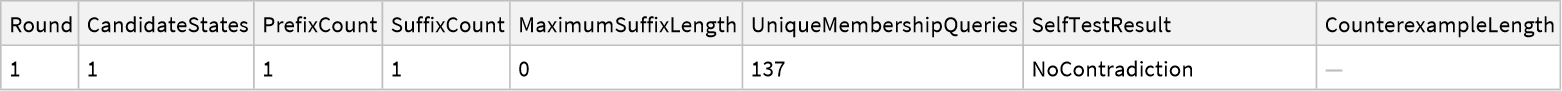

In [4630]:
Dataset[
  learningRoundLogS118A
]

In [4635]:
Dataset[
  selectedBoundedProfileS118A
]

Dataset[{<|FutureDepth -> 0, BehaviorClasses -> 2|>, 
 
>    <|FutureDepth -> 1, BehaviorClasses -> 3|>, 
 
>    <|FutureDepth -> 2, BehaviorClasses -> 4|>, 
 
>    <|FutureDepth -> 4, BehaviorClasses -> 6|>, 
 
>    <|FutureDepth -> 8, BehaviorClasses -> 11|>, 
 
>    <|FutureDepth -> 12, BehaviorClasses -> 15|>, 
 
>    <|FutureDepth -> 16, BehaviorClasses -> 19|>, 
 
>    <|FutureDepth -> 20, BehaviorClasses -> 23|>, 
 
>    <|FutureDepth -> 24, BehaviorClasses -> 27|>, 
 
>    <|FutureDepth -> 28, BehaviorClasses -> 31|>, 
 
>    <|FutureDepth -> 32, BehaviorClasses -> 35|>, 
 
>    <|FutureDepth -> 36, BehaviorClasses -> 39|>, 
 
>    <|FutureDepth -> 40, BehaviorClasses -> 39|>, 
 
>    <|FutureDepth -> 44, BehaviorClasses -> 39|>, 
 
>    <|FutureDepth -> 48, BehaviorClasses -> 39|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{FutureDepth, BehaviorClasses}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 15], <||>]

In [4640]:
Dataset[
  holdoutPerDepthS118A
]

Dataset[{<|Depth -> 80, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 200, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 500, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 1000, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Sequences, Matches, Accuracy}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 4], <||>]

<|PolicyMaxDepth -> 48, ProbeBankSize -> 2893, Rounds -> 1, SelfDiscoveredCEs -> 0, 
 
>   CELengths -> {}, MembershipQueries -> 137, 
 
>   MembershipBySource -> 
 
>    <|Table -> 4, SelfTest -> 133, Holdout -> 400, Audit -> 3143|>, LearnedStates -> 1, 
 
>   MaxLearnedSuffix -> 0, HiddenDeepDelayPostHoc -> 36, TrueStates -> 39, 
 
>   TrueMinimalStates -> 39, TrueMaxDistinguishingDepth -> 36, 
 
>   FirstFullSeparationDepth -> 36, 
 
>   ShortestLearnedDeepWitness -> Missing[NoLearnedWitness], 
 
>   HoldoutTouchedBeforeFreeze -> 0, HoldoutAccuracy -> 1., StateBijection -> False, 
 
>   TransitionMatches -> 1, TransitionTotal -> 3, SelfCounterexampleDiscovery -> False, 
 
>   DeepCounterexampleDiscovered -> False, ExactMachineIsomorphism -> False, 
 
>   AllFiniteSequenceEquivalent -> False, 
 
>   Diagnosis -> SELF_FALSIFICATION_POLICY_FAILED_TO_DISCOVER_ANY_MODEL_ERROR|>
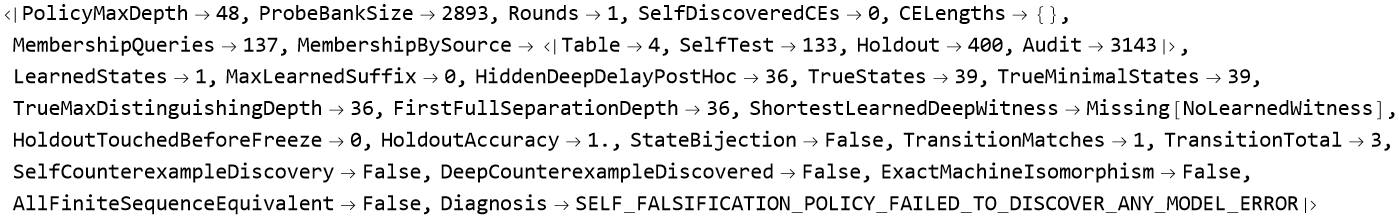

In [4645]:
<|

  "PolicyMaxDepth" ->
    selfTestMaxDepthS118A,

  "ProbeBankSize" ->
    Length[
      selfTestProbeBankS118A
    ],

  "Rounds" ->
    learningRoundS118A,

  "SelfDiscoveredCEs" ->
    Length[
      selfDiscoveredCounterexampleLogS118A
    ],

  "CELengths" ->
    (
      #["Length"] &
    ) /@
      selfDiscoveredCounterexampleLogS118A,

  "MembershipQueries" ->
    membershipQueriesBeforeFreezeS118A,

  "MembershipBySource" ->
    membershipNewBySourceS118A,

  "LearnedStates" ->
    learnedStateCountS118A,

  "MaxLearnedSuffix" ->
    maxLearnedSuffixLengthS118A,

  "HiddenDeepDelayPostHoc" ->
    hiddenDeepDepthS118A,

  "TrueStates" ->
    trueReachableCountS118A,

  "TrueMinimalStates" ->
    trueMinimalStateCountS118A,

  "TrueMaxDistinguishingDepth" ->
    trueMaxDistinguishingDepthS118A,

  "FirstFullSeparationDepth" ->
    firstFullSeparationDepthS118A,

  "ShortestLearnedDeepWitness" ->
    shortestLearnedDeepWitnessLengthS118A,

  "HoldoutTouchedBeforeFreeze" ->
    holdoutTouchedBeforeFreezeS118A,

  "HoldoutAccuracy" ->
    holdoutAccuracyS118A,

  "StateBijection" ->
    stateBijectionPassedS118A,

  "TransitionMatches" ->
    transitionMatchesS118A,

  "TransitionTotal" ->
    transitionTotalS118A,

  "SelfCounterexampleDiscovery" ->
    selfCounterexampleDiscoveryConfirmedS118A,

  "DeepCounterexampleDiscovered" ->
    deepCounterexampleDiscoveredS118A,

  "ExactMachineIsomorphism" ->
    exactMachineIsomorphismS118A,

  "AllFiniteSequenceEquivalent" ->
    allFiniteSequenceEquivalentS118A,

  "Diagnosis" ->
    diagnosisS118A

|>

<|ProbeBankLength -> 2893, ShallowWitnessInBank -> True, 
 
>   ShallowWitnessPosition -> {{137}}, DeepWitnessInBank -> True, 
 
>   DeepWitnessPosition -> {{2168}}, LearnedShallowPrediction -> 0, 
 
>   TrueShallowOutput -> 1, LearnedDeepPrediction -> 0, TrueDeepOutput -> 1, 
 
>   SelfTestAttempts -> 137|>
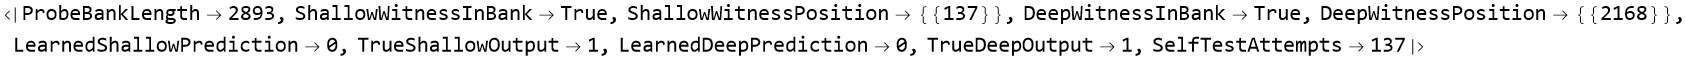

In [4650]:
witnessShallowS118A =
  {1, 0, 0, 0, 0};

witnessDeepS118A =
  Join[
    {2},
    ConstantArray[
      0,
      36
    ]
  ];

<|

  "ProbeBankLength" ->
    Length[
      selfTestProbeBankS118A
    ],

  "ShallowWitnessInBank" ->
    MemberQ[
      selfTestProbeBankS118A,
      witnessShallowS118A
    ],

  "ShallowWitnessPosition" ->
    Position[
      selfTestProbeBankS118A,
      witnessShallowS118A,
      {1},
      1
    ],

  "DeepWitnessInBank" ->
    MemberQ[
      selfTestProbeBankS118A,
      witnessDeepS118A
    ],

  "DeepWitnessPosition" ->
    Position[
      selfTestProbeBankS118A,
      witnessDeepS118A,
      {1},
      1
    ],

  "LearnedShallowPrediction" ->
    S118AHypothesisOutput[
      frozenHypothesisS118A,
      witnessShallowS118A
    ],

  "TrueShallowOutput" ->
    S118AEnvRawOutput[
      witnessShallowS118A
    ],

  "LearnedDeepPrediction" ->
    S118AHypothesisOutput[
      frozenHypothesisS118A,
      witnessDeepS118A
    ],

  "TrueDeepOutput" ->
    S118AEnvRawOutput[
      witnessDeepS118A
    ],

  "SelfTestAttempts" ->
    selfTestProbeAttemptsS118A

|>

In [4657]:
(* ============================================================ *)
(* S118A-R2 FIXED                                               *)
(* SELF-DISCOVERED COUNTEREXAMPLES WITHOUT EQUIVALENCE TEACHER  *)
(* ============================================================ *)
(*                                                              *)
(* FIXES FROM S118A-V1                                          *)
(* ------------------------------------------------------------ *)
(* 1. NO Return[] inside Do/For/While for value propagation.    *)
(*    Counterexamples use Catch/Throw explicitly.               *)
(*                                                              *)
(* 2. HARD SELF-TEST INVARIANT:                                 *)
(*                                                              *)
(*    NoContradiction                                           *)
(*        ==> every frozen probe was actually scanned.          *)
(*                                                              *)
(* 3. NEW hidden benchmark seed AFTER policy freeze.            *)
(*                                                              *)
(* 4. Add sealed structured challenge holdout with balanced     *)
(*    positive / negative behavior, so trivial all-zero models  *)
(*    cannot pass by base-rate imbalance.                       *)
(*                                                              *)
(* CORE LEARNING PRINCIPLE UNCHANGED                            *)
(* ------------------------------------------------------------ *)
(*                                                              *)
(*   p ~ q iff future observable behavior cannot distinguish    *)
(*   them.                                                      *)
(*                                                              *)
(* Learner gets only final binary membership observations.      *)
(*                                                              *)
(* NO:                                                          *)
(* - true state count                                           *)
(* - true transition table                                      *)
(* - state semantics                                            *)
(* - hidden delay                                               *)
(* - token roles                                                *)
(* - teacher counterexample                                     *)
(* - equivalence oracle                                         *)
(*                                                              *)
(* ============================================================ *)


ClearAll["Global`S118R2*"];
ClearAll["Global`s118R2*"];


s118R2Result =
Catch[

(

(* ============================================================ *)
(* 0. FAIL SAFE                                                 *)
(* ============================================================ *)

S118R2Fail[msg_] := (
  Print["STOP: ", msg];
  Throw[$Failed, "S118R2_STOP"];
);


Print["================================================"];
Print["S118A-R2 FIXED"];
Print["SELF-DISCOVERED COUNTEREXAMPLE LEARNING"];
Print["================================================"];


(* ============================================================ *)
(* 1. PUBLIC TASK INTERFACE                                     *)
(* ============================================================ *)

alphabetS118R2 =
  {0, 1, 2};


Print[
  "Primitive alphabet = ",
  alphabetS118R2
];


Print["Output alphabet = {0,1}"];
Print["NO EQUIVALENCE ORACLE."];
Print["NO TEACHER-PROVIDED COUNTEREXAMPLES."];
Print["NO TRUE STATE COUNT."];
Print["NO STATE SEMANTICS."];
Print["NO HIDDEN DELAY GIVEN."];
Print["MODEL MUST DISCOVER COUNTEREXAMPLES BY ITS OWN PREDICTION FAILURES."];


(* ============================================================ *)
(* 2. FREEZE SELF-FALSIFICATION POLICY                          *)
(*                                                              *)
(* IMPORTANT: happens BEFORE hidden benchmark generation.       *)
(*                                                              *)
(* Probe grammar:                                               *)
(*                                                              *)
(*   A. exhaustive short strings length <= 3                    *)
(*                                                              *)
(*   B. stem . repeated motif                                   *)
(*                                                              *)
(*      stem length 0..2                                        *)
(*      motif length 1..2                                       *)
(*      total sequence length <= 48                             *)
(*                                                              *)
(* Alphabet symbols treated symmetrically.                      *)
(* ============================================================ *)

selfTestMaxDepthS118R2 =
  48;


selfTestStemMaxLengthS118R2 =
  2;


selfTestMotifMaxLengthS118R2 =
  2;


selfTestShortExhaustiveDepthS118R2 =
  3;


selfTestPolicySpecS118R2 =
  <|

    "Alphabet" ->
      alphabetS118R2,

    "MaximumProbeDepth" ->
      selfTestMaxDepthS118R2,

    "StemMaximumLength" ->
      selfTestStemMaxLengthS118R2,

    "MotifMaximumLength" ->
      selfTestMotifMaxLengthS118R2,

    "ShortExhaustiveDepth" ->
      selfTestShortExhaustiveDepthS118R2,

    "ProbeForm" ->
      "ShortExhaustivePlusStemRepeatedMotif",

    "CounterexampleSource" ->
      "PredictionVsMembershipObservation"

  |>;


frozenSelfTestPolicyHashS118R2 =
  Hash[
    selfTestPolicySpecS118R2,
    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["SELF-FALSIFICATION POLICY FROZEN"];


Print[
  "Maximum probe depth = ",
  selfTestMaxDepthS118R2
];


Print[
  "Maximum stem length = ",
  selfTestStemMaxLengthS118R2
];


Print[
  "Maximum motif length = ",
  selfTestMotifMaxLengthS118R2
];


Print[
  "Policy hash = ",
  frozenSelfTestPolicyHashS118R2
];


Print["HIDDEN BENCHMARK DOES NOT EXIST YET."];
Print["================================================"];


(* ============================================================ *)
(* 3. BUILD FROZEN PROBE BANK                                   *)
(* ============================================================ *)

S118R2BuildProbeBank[
  maxDepth_Integer
] :=
Module[
  {
    shortSeqs,
    stems,
    motifs,
    patterned,
    maxRepeat,
    seqs
  },


  shortSeqs =
    Flatten[
      Table[

        Tuples[
          alphabetS118R2,
          len
        ],

        {
          len,
          0,
          selfTestShortExhaustiveDepthS118R2
        }
      ],

      1
    ];


  stems =
    Flatten[
      Table[

        Tuples[
          alphabetS118R2,
          len
        ],

        {
          len,
          0,
          selfTestStemMaxLengthS118R2
        }
      ],

      1
    ];


  motifs =
    Flatten[
      Table[

        Tuples[
          alphabetS118R2,
          len
        ],

        {
          len,
          1,
          selfTestMotifMaxLengthS118R2
        }
      ],

      1
    ];


  patterned =
    Flatten[

      Table[

        maxRepeat =
          Floor[
            (
              maxDepth -
              Length[stem]
            ) /
            Length[motif]
          ];


        If[
          maxRepeat >= 1,

          Table[

            Join[
              stem,

              Flatten[
                ConstantArray[
                  motif,
                  repeatCount
                ],
                1
              ]
            ],

            {
              repeatCount,
              1,
              maxRepeat
            }
          ],

          {}
        ],

        {
          stem,
          stems
        },

        {
          motif,
          motifs
        }
      ],

      2
    ];


  seqs =
    DeleteDuplicates[
      Join[
        shortSeqs,
        patterned
      ]
    ];


  SortBy[
    seqs,

    Function[
      seq,
      {
        Length[seq],
        ToString[
          InputForm[seq]
        ]
      }
    ]
  ]
];


selfTestProbeBankS118R2 =
  S118R2BuildProbeBank[
    selfTestMaxDepthS118R2
  ];


probeBankSizeS118R2 =
  Length[
    selfTestProbeBankS118R2
  ];


Print[
  "Frozen probe bank size = ",
  probeBankSizeS118R2
];


Print[
  "Probe bank maximum length = ",
  Max[
    Length /@
      selfTestProbeBankS118R2
  ]
];


(* ============================================================ *)
(* 4. ONLY NOW GENERATE A NEW HIDDEN BENCHMARK                  *)
(*                                                              *)
(* NEW seed, not the S118A-V1 environment.                      *)
(*                                                              *)
(* Environment contains:                                        *)
(* - deep delayed state chain                                   *)
(* - shallower delayed chain sharing the same suffix dynamics   *)
(* - random permutation of token roles                          *)
(*                                                              *)
(* Learner never reads these hidden values.                     *)
(* ============================================================ *)

hiddenBenchmarkSeedS118R2 =
  1182907;


{
  hiddenDeepDepthS118R2,
  hiddenShallowDepthS118R2,
  hiddenRolePermutationS118R2
} =
  BlockRandom[

    SeedRandom[
      hiddenBenchmarkSeedS118R2
    ];


    {
      RandomInteger[
        {18, 36}
      ],

      RandomInteger[
        {3, 7}
      ],

      RandomSample[
        alphabetS118R2
      ]
    }
  ];


hiddenDeepEntryTokenS118R2 =
  hiddenRolePermutationS118R2[[1]];


hiddenShallowEntryTokenS118R2 =
  hiddenRolePermutationS118R2[[2]];


hiddenCarryTokenS118R2 =
  hiddenRolePermutationS118R2[[3]];


S118R2DelayState[
  depth_Integer
] :=
  3 + depth;


hiddenStartStateS118R2 =
  1;


S118R2EnvStep[
  hiddenState_Integer,
  token_Integer
] :=
Module[
  {
    depth
  },


  Which[

    hiddenState === 1,

      Which[

        token ===
          hiddenDeepEntryTokenS118R2,

          S118R2DelayState[
            hiddenDeepDepthS118R2
          ],


        token ===
          hiddenShallowEntryTokenS118R2,

          S118R2DelayState[
            hiddenShallowDepthS118R2
          ],


        token ===
          hiddenCarryTokenS118R2,

          1,


        True,

          Missing[
            "UnknownToken"
          ]
      ],


    hiddenState === 2,

      2,


    hiddenState >= 3,

      depth =
        hiddenState - 3;


      If[
        depth == 0,

        2,

        If[
          token ===
            hiddenCarryTokenS118R2,

          S118R2DelayState[
            depth - 1
          ],

          2
        ]
      ],


    True,

      Missing[
        "UnknownHiddenState"
      ]

  ]
];


S118R2EnvStateOutput[
  hiddenState_Integer
] :=
  Boole[
    hiddenState ===
      S118R2DelayState[0]
  ];


S118R2EnvStateAfter[
  seq_List
] :=
  Fold[
    S118R2EnvStep,
    hiddenStartStateS118R2,
    seq
  ];


S118R2EnvRawOutput[
  seq_List
] :=
Module[
  {
    state
  },


  state =
    S118R2EnvStateAfter[
      seq
    ];


  If[
    !IntegerQ[state],

    Missing[
      "EnvironmentFailure"
    ],

    S118R2EnvStateOutput[
      state
    ]
  ]
];


Print["NEW HIDDEN BENCHMARK GENERATED AFTER POLICY FREEZE."];
Print["Hidden state count / delay / token roles remain sealed."];


(* ============================================================ *)
(* 5. PROSPECTIVE RANDOM LONG HOLDOUT                           *)
(*                                                              *)
(* Generated BEFORE learning. Outputs sealed.                   *)
(* ============================================================ *)

randomHoldoutSeedS118R2 =
  1182908;


randomHoldoutDepthsS118R2 =
  {
    80,
    200,
    500,
    1000
  };


randomHoldoutPerDepthS118R2 =
  100;


prospectiveRandomHoldoutS118R2 =
  BlockRandom[

    SeedRandom[
      randomHoldoutSeedS118R2
    ];


    Flatten[
      Table[

        Table[

          <|

            "Depth" ->
              depth,

            "Sequence" ->
              RandomChoice[
                alphabetS118R2,
                depth
              ]

          |>,

          {
            randomHoldoutPerDepthS118R2
          }
        ],

        {
          depth,
          randomHoldoutDepthsS118R2
        }
      ],

      1
    ]
  ];


Print[
  "Prospective RANDOM holdout sequences = ",
  Length[
    prospectiveRandomHoldoutS118R2
  ]
];


Print[
  "Random holdout depths = ",
  randomHoldoutDepthsS118R2
];


(* ============================================================ *)
(* 6. STRUCTURED SEALED CHALLENGE HOLDOUT                       *)
(*                                                              *)
(* Evaluator-side generation only.                              *)
(* Learner never reads this set before freeze.                  *)
(*                                                              *)
(* 100 true-positive trajectories                               *)
(* 100 near-miss true-negative trajectories                     *)
(*                                                              *)
(* All sequences deliberately > 48 steps so they cannot be      *)
(* present in the frozen self-test bank.                        *)
(*                                                              *)
(* Labels are NOT opened until after freeze.                    *)
(* ============================================================ *)

challengeExactShallowS118R2 =
  Table[

    <|

      "Kind" ->
        "ExactShallow",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118R2,
            preamble
          ],

          {
            hiddenShallowEntryTokenS118R2
          },

          ConstantArray[
            hiddenCarryTokenS118R2,
            hiddenShallowDepthS118R2
          ]
        ]

    |>,

    {
      preamble,
      60,
      109
    }
  ];


challengeExactDeepS118R2 =
  Table[

    <|

      "Kind" ->
        "ExactDeep",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118R2,
            preamble
          ],

          {
            hiddenDeepEntryTokenS118R2
          },

          ConstantArray[
            hiddenCarryTokenS118R2,
            hiddenDeepDepthS118R2
          ]
        ]

    |>,

    {
      preamble,
      120,
      169
    }
  ];


challengeShallowShortS118R2 =
  Table[

    <|

      "Kind" ->
        "ShallowOneShort",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118R2,
            preamble
          ],

          {
            hiddenShallowEntryTokenS118R2
          },

          ConstantArray[
            hiddenCarryTokenS118R2,
            hiddenShallowDepthS118R2 - 1
          ]
        ]

    |>,

    {
      preamble,
      180,
      204
    }
  ];


challengeShallowLongS118R2 =
  Table[

    <|

      "Kind" ->
        "ShallowOneLong",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118R2,
            preamble
          ],

          {
            hiddenShallowEntryTokenS118R2
          },

          ConstantArray[
            hiddenCarryTokenS118R2,
            hiddenShallowDepthS118R2 + 1
          ]
        ]

    |>,

    {
      preamble,
      210,
      234
    }
  ];


challengeDeepShortS118R2 =
  Table[

    <|

      "Kind" ->
        "DeepOneShort",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118R2,
            preamble
          ],

          {
            hiddenDeepEntryTokenS118R2
          },

          ConstantArray[
            hiddenCarryTokenS118R2,
            hiddenDeepDepthS118R2 - 1
          ]
        ]

    |>,

    {
      preamble,
      240,
      264
    }
  ];


challengeDeepLongS118R2 =
  Table[

    <|

      "Kind" ->
        "DeepOneLong",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118R2,
            preamble
          ],

          {
            hiddenDeepEntryTokenS118R2
          },

          ConstantArray[
            hiddenCarryTokenS118R2,
            hiddenDeepDepthS118R2 + 1
          ]
        ]

    |>,

    {
      preamble,
      270,
      294
    }
  ];


prospectiveChallengeHoldoutS118R2 =
  Join[
    challengeExactShallowS118R2,
    challengeExactDeepS118R2,
    challengeShallowShortS118R2,
    challengeShallowLongS118R2,
    challengeDeepShortS118R2,
    challengeDeepLongS118R2
  ];


Print[
  "Prospective STRUCTURED challenge sequences = ",
  Length[
    prospectiveChallengeHoldoutS118R2
  ]
];


Print["Challenge labels remain sealed until freeze."];


(* ============================================================ *)
(* 7. MEMBERSHIP QUERY INTERFACE                                *)
(* ============================================================ *)

membershipCacheS118R2 =
  <||>;


membershipFirstSourceS118R2 =
  <||>;


membershipUniqueCountS118R2 =
  0;


membershipTotalCallsS118R2 =
  0;


membershipNewBySourceS118R2 =
  <|

    "Table" -> 0,

    "SelfTest" -> 0,

    "RandomHoldout" -> 0,

    "ChallengeHoldout" -> 0,

    "Audit" -> 0

  |>;


S118R2SeqKey[
  seq_List
] :=
  ToString[
    InputForm[
      seq
    ]
  ];


S118R2MembershipY[
  seq_List,
  source_String : "Table"
] :=
Module[
  {
    key,
    y,
    oldCount
  },


  membershipTotalCallsS118R2++;


  key =
    S118R2SeqKey[
      seq
    ];


  If[
    KeyExistsQ[
      membershipCacheS118R2,
      key
    ],

    Lookup[
      membershipCacheS118R2,
      key
    ],


    y =
      S118R2EnvRawOutput[
        seq
      ];


    If[
      !MemberQ[
        {0, 1},
        y
      ],

      S118R2Fail[
        "Membership oracle returned non-binary output."
      ]
    ];


    membershipUniqueCountS118R2++;


    AssociateTo[
      membershipCacheS118R2,
      key -> y
    ];


    AssociateTo[
      membershipFirstSourceS118R2,
      key -> source
    ];


    oldCount =
      Lookup[
        membershipNewBySourceS118R2,
        source,
        0
      ];


    AssociateTo[
      membershipNewBySourceS118R2,
      source -> (oldCount + 1)
    ];


    y
  ]
];


(* ============================================================ *)
(* 8. RESIDUAL OBSERVATION TABLE                                *)
(* ============================================================ *)

prefixSetS118R2 =
  {
    {}
  };


suffixSetS118R2 =
  {
    {}
  };


S118R2Row[
  prefix_List
] :=
  Table[

    S118R2MembershipY[
      Join[
        prefix,
        suffix
      ],
      "Table"
    ],

    {
      suffix,
      suffixSetS118R2
    }
  ];


S118R2RowKey[
  row_List
] :=
  ToString[
    InputForm[
      row
    ]
  ];


S118R2Frontier[] :=
  DeleteDuplicates[
    Flatten[
      Table[

        Append[
          prefix,
          token
        ],

        {
          prefix,
          prefixSetS118R2
        },

        {
          token,
          alphabetS118R2
        }
      ],

      1
    ]
  ];


(* ============================================================ *)
(* 9. CLOSEDNESS                                                *)
(* ============================================================ *)

S118R2FindUnclosed[] :=
Module[
  {
    rowsInS,
    frontier
  },


  rowsInS =
    S118R2Row /@
      prefixSetS118R2;


  frontier =
    S118R2Frontier[];


  SelectFirst[
    frontier,

    Function[
      candidate,

      !MemberQ[
        rowsInS,
        S118R2Row[
          candidate
        ]
      ]
    ],

    Missing[
      "Closed"
    ]
  ]
];


(* ============================================================ *)
(* 10. CONSISTENCY -- CATCH/THROW SAFE                          *)
(* ============================================================ *)

S118R2FindInconsistency[] :=
Module[
  {
    result
  },


  result =
    Catch[

      Module[
        {
          n,
          i,
          j,
          p1,
          p2,
          row1,
          row2,
          successorRow1,
          successorRow2,
          diffPosition,
          oldSuffix,
          newSuffix
        },


        n =
          Length[
            prefixSetS118R2
          ];


        For[
          i = 1,
          i <= n,
          i++,


          p1 =
            prefixSetS118R2[[i]];


          row1 =
            S118R2Row[
              p1
            ];


          For[
            j = i + 1,
            j <= n,
            j++,


            p2 =
              prefixSetS118R2[[j]];


            row2 =
              S118R2Row[
                p2
              ];


            If[
              row1 === row2,


              Do[

                successorRow1 =
                  S118R2Row[
                    Append[
                      p1,
                      token
                    ]
                  ];


                successorRow2 =
                  S118R2Row[
                    Append[
                      p2,
                      token
                    ]
                  ];


                If[
                  successorRow1 =!=
                    successorRow2,


                  diffPosition =
                    FirstPosition[
                      MapThread[
                        Unequal,
                        {
                          successorRow1,
                          successorRow2
                        }
                      ],
                      True,
                      Missing[
                        "NotFound"
                      ]
                    ];


                  If[
                    MissingQ[
                      diffPosition
                    ],

                    S118R2Fail[
                      "Consistency mismatch exists but differing suffix was not found."
                    ]
                  ];


                  oldSuffix =
                    suffixSetS118R2[[
                      diffPosition[[1]]
                    ]];


                  newSuffix =
                    Join[
                      {token},
                      oldSuffix
                    ];


                  Throw[

                    <|

                      "Prefix1" ->
                        p1,

                      "Prefix2" ->
                        p2,

                      "Token" ->
                        token,

                      "OldSuffix" ->
                        oldSuffix,

                      "NewSuffix" ->
                        newSuffix

                    |>,

                    "S118R2_INCONSISTENCY"
                  ];
                ],

                {
                  token,
                  alphabetS118R2
                }
              ];
            ];
          ];
        ];


        Missing[
          "Consistent"
        ]
      ],

      "S118R2_INCONSISTENCY"
    ];


  result
];


(* ============================================================ *)
(* 11. STABILIZE TABLE                                          *)
(* ============================================================ *)

tableRepairLogS118R2 =
  {};


S118R2StabilizeTable[] :=
Module[
  {
    unclosed,
    inconsistency,
    done
  },


  done =
    False;


  While[
    !TrueQ[done],


    unclosed =
      S118R2FindUnclosed[];


    If[
      !MissingQ[
        unclosed
      ],


      prefixSetS118R2 =
        DeleteDuplicates[
          Append[
            prefixSetS118R2,
            unclosed
          ]
        ];


      AppendTo[
        tableRepairLogS118R2,

        <|

          "Type" ->
            "Closure",

          "AddedPrefix" ->
            unclosed,

          "PrefixCount" ->
            Length[
              prefixSetS118R2
            ],

          "SuffixCount" ->
            Length[
              suffixSetS118R2
            ]

        |>
      ],


      inconsistency =
        S118R2FindInconsistency[];


      If[
        AssociationQ[
          inconsistency
        ],


        suffixSetS118R2 =
          DeleteDuplicates[
            Append[
              suffixSetS118R2,
              inconsistency[
                "NewSuffix"
              ]
            ]
          ];


        AppendTo[
          tableRepairLogS118R2,

          <|

            "Type" ->
              "Consistency",

            "AddedSuffix" ->
              inconsistency[
                "NewSuffix"
              ],

            "AddedSuffixLength" ->
              Length[
                inconsistency[
                  "NewSuffix"
                ]
              ],

            "PrefixCount" ->
              Length[
                prefixSetS118R2
              ],

            "SuffixCount" ->
              Length[
                suffixSetS118R2
              ]

          |>
        ],


        done =
          True;
      ];
    ];

  ];

];


(* ============================================================ *)
(* 12. BUILD CURRENT HYPOTHESIS                                 *)
(* ============================================================ *)

S118R2BuildHypothesis[] :=
Module[
  {
    rows,
    uniqueRows,
    rowToState,
    representativeByState,
    transitionAssoc,
    outputAssoc,
    rep,
    successorRow,
    successorState,
    i
  },


  rows =
    S118R2Row /@
      prefixSetS118R2;


  uniqueRows =
    DeleteDuplicates[
      rows
    ];


  rowToState =
    Association[
      Table[

        S118R2RowKey[
          uniqueRows[[i]]
        ] ->
          i,

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  representativeByState =
    Association[
      Table[

        i ->

          SelectFirst[
            prefixSetS118R2,

            Function[
              prefix,

              S118R2Row[
                prefix
              ] ===
                uniqueRows[[i]]
            ]
          ],

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  transitionAssoc =
    <||>;


  outputAssoc =
    <||>;


  Do[

    rep =
      Lookup[
        representativeByState,
        i
      ];


    AssociateTo[
      outputAssoc,

      i ->
        S118R2MembershipY[
          rep,
          "Table"
        ]
    ];


    Do[

      successorRow =
        S118R2Row[
          Append[
            rep,
            token
          ]
        ];


      successorState =
        Lookup[
          rowToState,

          S118R2RowKey[
            successorRow
          ],

          Missing[
            "UnclosedTransition"
          ]
        ];


      If[
        MissingQ[
          successorState
        ],

        S118R2Fail[
          "Attempted to construct hypothesis from non-closed table."
        ]
      ];


      AssociateTo[
        transitionAssoc,

        ToString[
          InputForm[
            {
              i,
              token
            }
          ]
        ] ->
          successorState
      ],

      {
        token,
        alphabetS118R2
      }
    ],

    {
      i,
      Length[
        uniqueRows
      ]
    }
  ];


  <|

    "StateCount" ->
      Length[
        uniqueRows
      ],

    "Rows" ->
      uniqueRows,

    "RowToState" ->
      rowToState,

    "RepresentativeByState" ->
      representativeByState,

    "Transitions" ->
      transitionAssoc,

    "Outputs" ->
      outputAssoc,

    "StartState" ->
      Lookup[
        rowToState,

        S118R2RowKey[
          S118R2Row[
            {}
          ]
        ]
      ]

  |>
];


(* ============================================================ *)
(* 13. HYPOTHESIS EXECUTION                                     *)
(* ============================================================ *)

S118R2TransitionKey[
  state_Integer,
  token_Integer
] :=
  ToString[
    InputForm[
      {
        state,
        token
      }
    ]
  ];


S118R2HypothesisStep[
  hypothesis_Association,
  state_Integer,
  token_Integer
] :=
  Lookup[
    hypothesis[
      "Transitions"
    ],

    S118R2TransitionKey[
      state,
      token
    ],

    Missing[
      "UnknownTransition"
    ]
  ];


S118R2HypothesisStateAfter[
  hypothesis_Association,
  seq_List
] :=
  Fold[
    Function[
      {
        state,
        token
      },

      If[
        IntegerQ[state],

        S118R2HypothesisStep[
          hypothesis,
          state,
          token
        ],

        state
      ]
    ],

    hypothesis[
      "StartState"
    ],

    seq
  ];


S118R2HypothesisOutput[
  hypothesis_Association,
  seq_List
] :=
Module[
  {
    state
  },


  state =
    S118R2HypothesisStateAfter[
      hypothesis,
      seq
    ];


  If[
    !IntegerQ[state],

    Missing[
      "UnknownTransition"
    ],

    Lookup[
      hypothesis[
        "Outputs"
      ],

      state,

      Missing[
        "UnknownState"
      ]
    ]
  ]
];


(* ============================================================ *)
(* 14. FIXED SELF-FALSIFICATION                                 *)
(*                                                              *)
(* CRITICAL R2 FIX:                                             *)
(*                                                              *)
(* Catch / Throw returns the counterexample from the complete   *)
(* scanning function.                                           *)
(*                                                              *)
(* No Return[] appears inside Do[].                             *)
(* ============================================================ *)

selfTestRoundCountS118R2 =
  0;


selfTestProbeAttemptsTotalS118R2 =
  0;


lastSelfTestAttemptsThisRoundS118R2 =
  0;


selfDiscoveredCounterexampleLogS118R2 =
  {};


S118R2SelfFindCounterexample[
  hypothesis_Association
] :=
Module[
  {
    result,
    attemptsThisRound,
    i,
    seq,
    predicted,
    observed
  },


  selfTestRoundCountS118R2++;


  attemptsThisRound =
    0;


  result =
    Catch[

      Do[

        seq =
          selfTestProbeBankS118R2[[i]];


        attemptsThisRound++;


        selfTestProbeAttemptsTotalS118R2++;


        predicted =
          S118R2HypothesisOutput[
            hypothesis,
            seq
          ];


        observed =
          S118R2MembershipY[
            seq,
            "SelfTest"
          ];


        If[
          predicted =!=
            observed,


          Throw[

            <|

              "Sequence" ->
                seq,

              "Length" ->
                Length[
                  seq
                ],

              "ProbeIndex" ->
                i,

              "Predicted" ->
                predicted,

              "Observed" ->
                observed

            |>,

            "S118R2_COUNTEREXAMPLE"
          ];
        ],

        {
          i,
          1,
          probeBankSizeS118R2
        }
      ];


      Missing[
        "NoContradictionWithinFrozenProbePolicy"
      ],

      "S118R2_COUNTEREXAMPLE"
    ];


  lastSelfTestAttemptsThisRoundS118R2 =
    attemptsThisRound;


  result
];


(* ============================================================ *)
(* 15. COUNTEREXAMPLE REFINEMENT                                *)
(* ============================================================ *)

S118R2PrefixesOf[
  seq_List
] :=
  Table[
    Take[
      seq,
      k
    ],
    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S118R2SuffixesOf[
  seq_List
] :=
  Table[
    Drop[
      seq,
      k
    ],
    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S118R2RefineFromCounterexample[
  seq_List
] :=
(

  prefixSetS118R2 =
    DeleteDuplicates[
      Join[
        prefixSetS118R2,
        S118R2PrefixesOf[
          seq
        ]
      ]
    ];


  suffixSetS118R2 =
    DeleteDuplicates[
      Join[
        suffixSetS118R2,
        S118R2SuffixesOf[
          seq
        ]
      ]
    ];

);


(* ============================================================ *)
(* 16. ACTIVE SELF-FALSIFICATION LEARNING LOOP                  *)
(* ============================================================ *)

learningRoundS118R2 =
  0;


learningRoundLogS118R2 =
  {};


candidateHypothesisS118R2 =
  Missing[
    "NotBuilt"
  ];


selfTestStableS118R2 =
  False;


fullScanInvariantPassedS118R2 =
  True;


Print["================================================"];
Print["ACTIVE SELF-FALSIFICATION LEARNING"];
Print["================================================"];


learningTimingS118R2 =
  AbsoluteTiming[

    While[
      !TrueQ[
        selfTestStableS118R2
      ],


      learningRoundS118R2++;


      If[
        learningRoundS118R2 > 100,

        S118R2Fail[
          "Learning-round safety limit exceeded."
        ]
      ];


      S118R2StabilizeTable[];


      candidateHypothesisS118R2 =
        S118R2BuildHypothesis[];


      selfTestResultS118R2 =
        S118R2SelfFindCounterexample[
          candidateHypothesisS118R2
        ];


      (* ------------------------------------------------------ *)
      (* HARD R2 INVARIANTS                                     *)
      (* ------------------------------------------------------ *)


      If[
        MissingQ[
          selfTestResultS118R2
        ] &&

        lastSelfTestAttemptsThisRoundS118R2 =!=
          probeBankSizeS118R2,


        fullScanInvariantPassedS118R2 =
          False;


        S118R2Fail[
          StringJoin[
            "NoContradiction returned after only ",
            ToString[
              lastSelfTestAttemptsThisRoundS118R2
            ],
            " / ",
            ToString[
              probeBankSizeS118R2
            ],
            " frozen probes."
          ]
        ]
      ];


      If[
        AssociationQ[
          selfTestResultS118R2
        ] &&

        selfTestResultS118R2[
          "ProbeIndex"
        ] =!=
          lastSelfTestAttemptsThisRoundS118R2,


        fullScanInvariantPassedS118R2 =
          False;


        S118R2Fail[
          "Counterexample ProbeIndex does not match attempts-this-round."
        ]
      ];


      If[
        AssociationQ[
          selfTestResultS118R2
        ] &&

        selfTestResultS118R2[
          "Predicted"
        ] ===
          selfTestResultS118R2[
            "Observed"
          ],


        fullScanInvariantPassedS118R2 =
          False;


        S118R2Fail[
          "Returned counterexample is not actually a prediction error."
        ]
      ];


      If[
        MissingQ[
          selfTestResultS118R2
        ],


        selfTestStableS118R2 =
          True;


        AppendTo[
          learningRoundLogS118R2,

          <|

            "Round" ->
              learningRoundS118R2,

            "CandidateStates" ->
              candidateHypothesisS118R2[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS118R2
              ],

            "SuffixCount" ->
              Length[
                suffixSetS118R2
              ],

            "MaximumSuffixLength" ->
              Max[
                Length /@
                  suffixSetS118R2
              ],

            "UniqueMembershipQueries" ->
              membershipUniqueCountS118R2,

            "SelfTestResult" ->
              "NoContradiction",

            "AttemptsThisRound" ->
              lastSelfTestAttemptsThisRoundS118R2,

            "FullProbeBankSize" ->
              probeBankSizeS118R2,

            "CounterexampleLength" ->
              Missing[
                "None"
              ]

          |>
        ],


        AppendTo[
          selfDiscoveredCounterexampleLogS118R2,
          selfTestResultS118R2
        ];


        AppendTo[
          learningRoundLogS118R2,

          <|

            "Round" ->
              learningRoundS118R2,

            "CandidateStates" ->
              candidateHypothesisS118R2[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS118R2
              ],

            "SuffixCount" ->
              Length[
                suffixSetS118R2
              ],

            "MaximumSuffixLength" ->
              Max[
                Length /@
                  suffixSetS118R2
              ],

            "UniqueMembershipQueries" ->
              membershipUniqueCountS118R2,

            "SelfTestResult" ->
              "SelfDiscoveredCounterexample",

            "AttemptsThisRound" ->
              lastSelfTestAttemptsThisRoundS118R2,

            "ProbeIndex" ->
              selfTestResultS118R2[
                "ProbeIndex"
              ],

            "CounterexampleLength" ->
              selfTestResultS118R2[
                "Length"
              ],

            "Predicted" ->
              selfTestResultS118R2[
                "Predicted"
              ],

            "Observed" ->
              selfTestResultS118R2[
                "Observed"
              ]

          |>
        ];


        S118R2RefineFromCounterexample[
          selfTestResultS118R2[
            "Sequence"
          ]
        ];
      ];


      Print[
        "Round ",
        learningRoundS118R2,

        ": states = ",
        candidateHypothesisS118R2[
          "StateCount"
        ],

        ", prefixes = ",
        Length[
          prefixSetS118R2
        ],

        ", suffixes = ",
        Length[
          suffixSetS118R2
        ],

        ", max suffix = ",
        Max[
          Length /@
            suffixSetS118R2
        ],

        ", membership queries = ",
        membershipUniqueCountS118R2,

        ", probes this round = ",
        lastSelfTestAttemptsThisRoundS118R2,

        ", self-test = ",

        If[
          selfTestStableS118R2,

          "FULL BANK NO CONTRADICTION",

          StringJoin[
            "SELF CE LENGTH ",
            ToString[
              selfTestResultS118R2[
                "Length"
              ]
            ],
            " @ PROBE ",
            ToString[
              selfTestResultS118R2[
                "ProbeIndex"
              ]
            ]
          ]
        ]
      ];

    ];

  ];


Print[
  "Learning seconds = ",
  N[
    learningTimingS118R2[[1]]
  ]
];


Print[
  "Learning rounds = ",
  learningRoundS118R2
];


Print[
  "Self-test rounds = ",
  selfTestRoundCountS118R2
];


Print[
  "Self-discovered counterexamples = ",
  Length[
    selfDiscoveredCounterexampleLogS118R2
  ]
];


Print[
  "Counterexample lengths = ",
  (
    #["Length"] &
  ) /@
    selfDiscoveredCounterexampleLogS118R2
];


Print[
  "Counterexample probe indices = ",
  (
    #["ProbeIndex"] &
  ) /@
    selfDiscoveredCounterexampleLogS118R2
];


Print[
  "Final residual states = ",
  candidateHypothesisS118R2[
    "StateCount"
  ]
];


Print[
  "Final suffix count = ",
  Length[
    suffixSetS118R2
  ]
];


Print[
  "Maximum suffix length = ",
  Max[
    Length /@
      suffixSetS118R2
  ]
];


Print[
  "Final no-contradiction scan = ",
  lastSelfTestAttemptsThisRoundS118R2,
  " / ",
  probeBankSizeS118R2
];


Print[
  "Full-scan invariant passed = ",
  fullScanInvariantPassedS118R2
];


Print[
  "Membership queries = ",
  membershipUniqueCountS118R2
];


(* ============================================================ *)
(* 17. PROSPECTIVE HOLDOUT LEAKAGE                              *)
(* ============================================================ *)

randomHoldoutTouchedBeforeFreezeS118R2 =
  Count[
    prospectiveRandomHoldoutS118R2,

    row_Association /;

      KeyExistsQ[
        membershipCacheS118R2,

        S118R2SeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


challengeHoldoutTouchedBeforeFreezeS118R2 =
  Count[
    prospectiveChallengeHoldoutS118R2,

    row_Association /;

      KeyExistsQ[
        membershipCacheS118R2,

        S118R2SeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


Print[
  "Random holdout touched before freeze = ",
  randomHoldoutTouchedBeforeFreezeS118R2,
  " / ",
  Length[
    prospectiveRandomHoldoutS118R2
  ]
];


Print[
  "Challenge holdout touched before freeze = ",
  challengeHoldoutTouchedBeforeFreezeS118R2,
  " / ",
  Length[
    prospectiveChallengeHoldoutS118R2
  ]
];


(* ============================================================ *)
(* 18. VERIFY POLICY HASH                                       *)
(* ============================================================ *)

recomputedPolicyHashS118R2 =
  Hash[
    selfTestPolicySpecS118R2,
    "SHA256",
    "HexString"
  ];


selfTestPolicyHashUnchangedS118R2 =
  recomputedPolicyHashS118R2 ===
    frozenSelfTestPolicyHashS118R2;


If[
  !TrueQ[
    selfTestPolicyHashUnchangedS118R2
  ],

  S118R2Fail[
    "Frozen self-test policy changed."
  ]
];


Print[
  "Self-test policy hash unchanged = ",
  selfTestPolicyHashUnchangedS118R2
];


(* ============================================================ *)
(* 19. FREEZE LEARNED MACHINE                                   *)
(* ============================================================ *)

frozenHypothesisS118R2 =
  candidateHypothesisS118R2;


frozenSuffixSetS118R2 =
  suffixSetS118R2;


membershipQueriesBeforeFreezeS118R2 =
  membershipUniqueCountS118R2;


frozenMachineHashS118R2 =
  Hash[
    {
      frozenHypothesisS118R2[
        "StateCount"
      ],
      frozenHypothesisS118R2[
        "Transitions"
      ],
      frozenHypothesisS118R2[
        "Outputs"
      ],
      frozenHypothesisS118R2[
        "StartState"
      ],
      frozenHypothesisS118R2[
        "RepresentativeByState"
      ],
      frozenSuffixSetS118R2
    },

    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S118A-R2 MACHINE FROZEN"];


Print[
  "States = ",
  frozenHypothesisS118R2[
    "StateCount"
  ]
];


Print[
  "Transitions = ",
  Length[
    frozenHypothesisS118R2[
      "Transitions"
    ]
  ]
];


Print[
  "Suffixes = ",
  Length[
    frozenSuffixSetS118R2
  ]
];


Print[
  "Maximum suffix length = ",
  Max[
    Length /@
      frozenSuffixSetS118R2
  ]
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS118R2
];


Print[
  "Machine hash = ",
  frozenMachineHashS118R2
];


Print["NO STATE / TRANSITION / SUFFIX CHANGES AFTER THIS POINT."];
Print["================================================"];


(* ============================================================ *)
(* 20. OPEN RANDOM HOLDOUT                                      *)
(* ============================================================ *)

Print["================================================"];
Print["OPENING RANDOM LONG HOLDOUT"];
Print["================================================"];


randomHoldoutRowsS118R2 =
  Table[

    Module[
      {
        seq,
        learnedY,
        trueY
      },


      seq =
        row[
          "Sequence"
        ];


      learnedY =
        S118R2HypothesisOutput[
          frozenHypothesisS118R2,
          seq
        ];


      trueY =
        S118R2MembershipY[
          seq,
          "RandomHoldout"
        ];


      <|

        "Depth" ->
          row[
            "Depth"
          ],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY ===
              trueY
          )

      |>

    ],

    {
      row,
      prospectiveRandomHoldoutS118R2
    }
  ];


randomHoldoutMatchesS118R2 =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      randomHoldoutRowsS118R2,
    True
  ];


randomHoldoutAccuracyS118R2 =
  N[
    randomHoldoutMatchesS118R2 /
      Length[
        randomHoldoutRowsS118R2
      ]
  ];


randomHoldoutPerDepthS118R2 =
  Table[

    Module[
      {
        rows,
        matches
      },


      rows =
        Select[
          randomHoldoutRowsS118R2,
          #["Depth"] === depth &
        ];


      matches =
        Count[
          (
            TrueQ[
              #["Match"]
            ] &
          ) /@
            rows,
          True
        ];


      <|

        "Depth" ->
          depth,

        "Sequences" ->
          Length[
            rows
          ],

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      depth,
      randomHoldoutDepthsS118R2
    }
  ];


Print[
  "Random holdout = ",
  randomHoldoutMatchesS118R2,
  " / ",
  Length[
    randomHoldoutRowsS118R2
  ]
];


(* ============================================================ *)
(* 21. OPEN STRUCTURED CHALLENGE HOLDOUT                        *)
(* ============================================================ *)

Print["================================================"];
Print["OPENING STRUCTURED CHALLENGE HOLDOUT"];
Print["================================================"];


challengeRowsS118R2 =
  Table[

    Module[
      {
        seq,
        learnedY,
        trueY
      },


      seq =
        row[
          "Sequence"
        ];


      learnedY =
        S118R2HypothesisOutput[
          frozenHypothesisS118R2,
          seq
        ];


      trueY =
        S118R2MembershipY[
          seq,
          "ChallengeHoldout"
        ];


      <|

        "Kind" ->
          row[
            "Kind"
          ],

        "Length" ->
          Length[
            seq
          ],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY ===
              trueY
          )

      |>

    ],

    {
      row,
      prospectiveChallengeHoldoutS118R2
    }
  ];


challengeMatchesS118R2 =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      challengeRowsS118R2,
    True
  ];


challengeAccuracyS118R2 =
  N[
    challengeMatchesS118R2 /
      Length[
        challengeRowsS118R2
      ]
  ];


challengeTruePositiveCountS118R2 =
  Count[
    (
      #["TrueY"] &
    ) /@
      challengeRowsS118R2,
    1
  ];


challengeTrueNegativeCountS118R2 =
  Count[
    (
      #["TrueY"] &
    ) /@
      challengeRowsS118R2,
    0
  ];


challengeBalancedS118R2 =
  challengeTruePositiveCountS118R2 ===
    challengeTrueNegativeCountS118R2;


challengePerKindS118R2 =
  Table[

    Module[
      {
        rows,
        matches,
        positives,
        negatives
      },


      rows =
        Select[
          challengeRowsS118R2,
          #["Kind"] === kind &
        ];


      matches =
        Count[
          (
            TrueQ[
              #["Match"]
            ] &
          ) /@
            rows,
          True
        ];


      positives =
        Count[
          (
            #["TrueY"] &
          ) /@
            rows,
          1
        ];


      negatives =
        Count[
          (
            #["TrueY"] &
          ) /@
            rows,
          0
        ];


      <|

        "Kind" ->
          kind,

        "Sequences" ->
          Length[
            rows
          ],

        "TruePositiveOutputs" ->
          positives,

        "TrueNegativeOutputs" ->
          negatives,

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      kind,
      DeleteDuplicates[
        (
          #["Kind"] &
        ) /@
          challengeRowsS118R2
      ]
    }
  ];


Print[
  "Challenge holdout = ",
  challengeMatchesS118R2,
  " / ",
  Length[
    challengeRowsS118R2
  ]
];


Print[
  "Challenge true outputs: positive = ",
  challengeTruePositiveCountS118R2,
  ", negative = ",
  challengeTrueNegativeCountS118R2
];


Print[
  "Challenge balanced = ",
  challengeBalancedS118R2
];


(* ============================================================ *)
(* 22. EXHAUSTIVE SHORT AUDIT                                   *)
(*                                                              *)
(* length 0..8 = 9841 sequences                                *)
(* ============================================================ *)

auditMaxLengthS118R2 =
  8;


auditSequencesS118R2 =
  Flatten[
    Table[

      Tuples[
        alphabetS118R2,
        len
      ],

      {
        len,
        0,
        auditMaxLengthS118R2
      }
    ],

    1
  ];


auditRowsS118R2 =
  Table[

    Module[
      {
        learnedY,
        trueY
      },


      learnedY =
        S118R2HypothesisOutput[
          frozenHypothesisS118R2,
          seq
        ];


      trueY =
        S118R2MembershipY[
          seq,
          "Audit"
        ];


      <|

        "Length" ->
          Length[
            seq
          ],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY ===
              trueY
          )

      |>

    ],

    {
      seq,
      auditSequencesS118R2
    }
  ];


auditMatchesS118R2 =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      auditRowsS118R2,
    True
  ];


auditAccuracyS118R2 =
  N[
    auditMatchesS118R2 /
      Length[
        auditRowsS118R2
      ]
  ];


Print[
  "Exhaustive audit length 0..",
  auditMaxLengthS118R2,
  " = ",
  auditMatchesS118R2,
  " / ",
  Length[
    auditRowsS118R2
  ]
];


(* ============================================================ *)
(* 23. VERIFY FROZEN HASH                                       *)
(* ============================================================ *)

recomputedMachineHashS118R2 =
  Hash[
    {
      frozenHypothesisS118R2[
        "StateCount"
      ],
      frozenHypothesisS118R2[
        "Transitions"
      ],
      frozenHypothesisS118R2[
        "Outputs"
      ],
      frozenHypothesisS118R2[
        "StartState"
      ],
      frozenHypothesisS118R2[
        "RepresentativeByState"
      ],
      frozenSuffixSetS118R2
    },

    "SHA256",
    "HexString"
  ];


frozenMachineHashUnchangedS118R2 =
  recomputedMachineHashS118R2 ===
    frozenMachineHashS118R2;


Print[
  "Frozen machine hash unchanged = ",
  frozenMachineHashUnchangedS118R2
];


If[
  !TrueQ[
    frozenMachineHashUnchangedS118R2
  ],

  S118R2Fail[
    "Frozen learned machine changed after freeze."
  ]
];


(* ============================================================ *)
(* 24. ONLY NOW REVEAL HIDDEN BENCHMARK                         *)
(* ============================================================ *)

Print["================================================"];
Print["POST-HOC HIDDEN BENCHMARK OPENED"];
Print["================================================"];


Print[
  "Hidden deep delay = ",
  hiddenDeepDepthS118R2
];


Print[
  "Hidden shallow delay = ",
  hiddenShallowDepthS118R2
];


Print[
  "Hidden role permutation = ",
  hiddenRolePermutationS118R2
];


Print[
  "Deep-entry token = ",
  hiddenDeepEntryTokenS118R2
];


Print[
  "Shallow-entry token = ",
  hiddenShallowEntryTokenS118R2
];


Print[
  "Carry token = ",
  hiddenCarryTokenS118R2
];


(* ============================================================ *)
(* 25. TRUE REACHABLE STATES                                    *)
(* ============================================================ *)

S118R2TrueReachableStates[] :=
Module[
  {
    seen,
    queue,
    current,
    next
  },


  seen =
    {
      hiddenStartStateS118R2
    };


  queue =
    {
      hiddenStartStateS118R2
    };


  While[
    Length[
      queue
    ] > 0,


    current =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    Do[

      next =
        S118R2EnvStep[
          current,
          token
        ];


      If[
        !MemberQ[
          seen,
          next
        ],

        AppendTo[
          seen,
          next
        ];


        AppendTo[
          queue,
          next
        ];
      ],

      {
        token,
        alphabetS118R2
      }
    ];

  ];


  Sort[
    seen
  ]
];


trueReachableStatesS118R2 =
  S118R2TrueReachableStates[];


trueReachableCountS118R2 =
  Length[
    trueReachableStatesS118R2
  ];


Print[
  "True reachable states = ",
  trueReachableCountS118R2
];


(* ============================================================ *)
(* 26. TRUE MINIMALITY                                          *)
(* ============================================================ *)

S118R2TrueMinimalPartition[] :=
Module[
  {
    partition,
    stateToBlock,
    signatures,
    newPartition,
    oldCanonical,
    newCanonical,
    stable
  },


  partition =
    Values[
      GroupBy[
        trueReachableStatesS118R2,

        Function[
          state,
          S118R2EnvStateOutput[
            state
          ]
        ]
      ]
    ];


  stable =
    False;


  While[
    !TrueQ[
      stable
    ],


    stateToBlock =
      Association[
        Flatten[
          Table[

            Table[
              state -> blockIndex,

              {
                state,
                partition[[blockIndex]]
              }
            ],

            {
              blockIndex,
              Length[
                partition
              ]
            }
          ]
        ]
      ];


    signatures =
      Association[
        Table[

          state ->

            Join[
              {
                S118R2EnvStateOutput[
                  state
                ]
              },

              Table[
                Lookup[
                  stateToBlock,

                  S118R2EnvStep[
                    state,
                    token
                  ]
                ],

                {
                  token,
                  alphabetS118R2
                }
              ]
            ],

          {
            state,
            trueReachableStatesS118R2
          }
        ]
      ];


    newPartition =
      Values[
        GroupBy[
          trueReachableStatesS118R2,

          Function[
            state,
            Lookup[
              signatures,
              state
            ]
          ]
        ]
      ];


    oldCanonical =
      Sort[
        Sort /@
          partition
      ];


    newCanonical =
      Sort[
        Sort /@
          newPartition
      ];


    If[
      newCanonical ===
        oldCanonical,

      stable =
        True,

      partition =
        newPartition;
    ];

  ];


  partition
];


trueMinimalPartitionS118R2 =
  S118R2TrueMinimalPartition[];


trueMinimalStateCountS118R2 =
  Length[
    trueMinimalPartitionS118R2
  ];


trueMachineMinimalS118R2 =
  And[
    trueMinimalStateCountS118R2 ==
      trueReachableCountS118R2,

    AllTrue[
      trueMinimalPartitionS118R2,
      Length[#] == 1 &
    ]
  ];


Print[
  "True behavioral-minimal states = ",
  trueMinimalStateCountS118R2
];


Print[
  "True machine minimal = ",
  trueMachineMinimalS118R2
];


(* ============================================================ *)
(* 27. IMMEDIATE ALIASING                                       *)
(* ============================================================ *)

immediateOutputGroupsS118R2 =
  Values[
    GroupBy[
      trueReachableStatesS118R2,

      Function[
        state,
        S118R2EnvStateOutput[
          state
        ]
      ]
    ]
  ];


immediateOutputBlockSizesS118R2 =
  Reverse[
    Sort[
      Length /@
        immediateOutputGroupsS118R2
    ]
  ];


totalTrueStatePairsS118R2 =
  Binomial[
    trueReachableCountS118R2,
    2
  ];


sameImmediateOutputPairsS118R2 =
  Total[
    (
      Binomial[
        #,
        2
      ] &
    ) /@
      immediateOutputBlockSizesS118R2
  ];


immediateAliasFractionS118R2 =
  If[
    totalTrueStatePairsS118R2 > 0,

    N[
      sameImmediateOutputPairsS118R2 /
        totalTrueStatePairsS118R2
    ],

    0.
  ];


Print[
  "Immediate output blocks = ",
  immediateOutputBlockSizesS118R2
];


Print[
  "Immediate alias fraction = ",
  immediateAliasFractionS118R2
];


(* ============================================================ *)
(* 28. BOUNDED-HORIZON SEPARATION PROFILE                       *)
(* ============================================================ *)

S118R2BoundedPartitionProfile[
  maxDepth_Integer
] :=
Module[
  {
    partition,
    profile,
    stateToBlock,
    signatures
  },


  partition =
    Values[
      GroupBy[
        trueReachableStatesS118R2,

        Function[
          state,
          S118R2EnvStateOutput[
            state
          ]
        ]
      ]
    ];


  profile =
    {
      <|
        "FutureDepth" -> 0,
        "BehaviorClasses" ->
          Length[
            partition
          ]
      |>
    };


  Do[

    stateToBlock =
      Association[
        Flatten[
          Table[

            Table[
              state -> blockIndex,

              {
                state,
                partition[[blockIndex]]
              }
            ],

            {
              blockIndex,
              Length[
                partition
              ]
            }
          ]
        ]
      ];


    signatures =
      Association[
        Table[

          state ->

            Join[
              {
                S118R2EnvStateOutput[
                  state
                ]
              },

              Table[
                Lookup[
                  stateToBlock,

                  S118R2EnvStep[
                    state,
                    token
                  ]
                ],

                {
                  token,
                  alphabetS118R2
                }
              ]
            ],

          {
            state,
            trueReachableStatesS118R2
          }
        ]
      ];


    partition =
      Values[
        GroupBy[
          trueReachableStatesS118R2,

          Function[
            state,
            Lookup[
              signatures,
              state
            ]
          ]
        ]
      ];


    AppendTo[
      profile,

      <|

        "FutureDepth" ->
          depth,

        "BehaviorClasses" ->
          Length[
            partition
          ]

      |>
    ],

    {
      depth,
      1,
      selfTestMaxDepthS118R2
    }
  ];


  profile
];


boundedPartitionProfileS118R2 =
  S118R2BoundedPartitionProfile[
    selfTestMaxDepthS118R2
  ];


fullSeparationRowsS118R2 =
  Select[
    boundedPartitionProfileS118R2,

    #["BehaviorClasses"] ===
      trueMinimalStateCountS118R2 &
  ];


firstFullSeparationDepthS118R2 =
  If[
    Length[
      fullSeparationRowsS118R2
    ] > 0,

    First[
      fullSeparationRowsS118R2
    ][
      "FutureDepth"
    ],

    Missing[
      "NotFullySeparated"
    ]
  ];


selectedBoundedProfileS118R2 =
  Select[
    boundedPartitionProfileS118R2,

    MemberQ[
      {
        0, 1, 2, 4, 8, 12, 16,
        20, 24, 28, 32, 36,
        40, 44, 48
      },
      #["FutureDepth"]
    ] &
  ];


Print[
  "First full-separation depth = ",
  firstFullSeparationDepthS118R2
];


(* ============================================================ *)
(* 29. TRUE SHORTEST DISTINGUISHING DEPTHS                      *)
(*                                                              *)
(* Catch/Throw used for value exit.                             *)
(* ============================================================ *)

S118R2TruePairDistinguishingDepth[
  state1_Integer,
  state2_Integer
] :=
Module[
  {
    result
  },


  result =
    Catch[

      Module[
        {
          queue,
          visited,
          current,
          s1,
          s2,
          depth,
          key
        },


        queue =
          {
            {
              state1,
              state2,
              0
            }
          };


        visited =
          <||>;


        While[
          Length[
            queue
          ] > 0,


          current =
            First[
              queue
            ];


          queue =
            Rest[
              queue
            ];


          s1 =
            current[[1]];


          s2 =
            current[[2]];


          depth =
            current[[3]];


          key =
            ToString[
              InputForm[
                Sort[
                  {
                    s1,
                    s2
                  }
                ]
              ]
            ];


          If[
            !KeyExistsQ[
              visited,
              key
            ],


            AssociateTo[
              visited,
              key -> True
            ];


            If[
              S118R2EnvStateOutput[
                s1
              ] =!=
                S118R2EnvStateOutput[
                  s2
                ],


              Throw[
                depth,
                "S118R2_DISTINGUISHED"
              ];
            ];


            Do[

              AppendTo[
                queue,

                {
                  S118R2EnvStep[
                    s1,
                    token
                  ],

                  S118R2EnvStep[
                    s2,
                    token
                  ],

                  depth + 1
                }
              ],

              {
                token,
                alphabetS118R2
              }
            ];
          ];

        ];


        Missing[
          "NotDistinguishable"
        ]
      ],

      "S118R2_DISTINGUISHED"
    ];


  result
];


trueStatePairsS118R2 =
  Subsets[
    trueReachableStatesS118R2,
    {2}
  ];


pairDistinguishabilityRowsS118R2 =
  Table[

    <|

      "State1" ->
        pair[[1]],

      "State2" ->
        pair[[2]],

      "ShortestDistinguishingDepth" ->
        S118R2TruePairDistinguishingDepth[
          pair[[1]],
          pair[[2]]
        ]

    |>,

    {
      pair,
      trueStatePairsS118R2
    }
  ];


distinguishingDepthValuesS118R2 =
  Cases[
    (
      #[
        "ShortestDistinguishingDepth"
      ] &
    ) /@
      pairDistinguishabilityRowsS118R2,

    _Integer
  ];


trueMaxDistinguishingDepthS118R2 =
  Max[
    distinguishingDepthValuesS118R2
  ];


distinguishingDepthHistogramS118R2 =
  Counts[
    distinguishingDepthValuesS118R2
  ];


deepestPairS118R2 =
  SelectFirst[
    pairDistinguishabilityRowsS118R2,

    #[
      "ShortestDistinguishingDepth"
    ] ===
      trueMaxDistinguishingDepthS118R2 &,

    Missing[
      "NoDeepPair"
    ]
  ];


Print[
  "TRUE maximum distinguishing depth = ",
  trueMaxDistinguishingDepthS118R2
];


Print[
  "Deepest true pair = ",
  deepestPairS118R2
];


(* ============================================================ *)
(* 30. LEARNED DEEP WITNESS AUDIT                               *)
(* ============================================================ *)

S118R2EnvStateAfterFrom[
  startState_Integer,
  seq_List
] :=
  Fold[
    S118R2EnvStep,
    startState,
    seq
  ];


S118R2EnvOutputFromState[
  startState_Integer,
  seq_List
] :=
  S118R2EnvStateOutput[
    S118R2EnvStateAfterFrom[
      startState,
      seq
    ]
  ];


deepWitnessesInSuffixSetS118R2 =
  If[
    AssociationQ[
      deepestPairS118R2
    ],

    Select[
      frozenSuffixSetS118R2,

      Function[
        suffix,

        S118R2EnvOutputFromState[
          deepestPairS118R2[
            "State1"
          ],
          suffix
        ] =!=

        S118R2EnvOutputFromState[
          deepestPairS118R2[
            "State2"
          ],
          suffix
        ]
      ]
    ],

    {}
  ];


shortestLearnedDeepWitnessLengthS118R2 =
  If[
    Length[
      deepWitnessesInSuffixSetS118R2
    ] > 0,

    Min[
      Length /@
        deepWitnessesInSuffixSetS118R2
    ],

    Missing[
      "NoLearnedWitness"
    ]
  ];


maxLearnedSuffixLengthS118R2 =
  Max[
    Length /@
      frozenSuffixSetS118R2
  ];


Print[
  "Maximum learned suffix length = ",
  maxLearnedSuffixLengthS118R2
];


Print[
  "Shortest learned witness for deepest pair = ",
  shortestLearnedDeepWitnessLengthS118R2
];


(* ============================================================ *)
(* 31. LEARNED -> TRUE STATE CORRESPONDENCE                     *)
(* ============================================================ *)

learnedStateCountS118R2 =
  frozenHypothesisS118R2[
    "StateCount"
  ];


stateCorrespondenceS118R2 =
  Table[

    Module[
      {
        rep,
        trueState
      },


      rep =
        Lookup[
          frozenHypothesisS118R2[
            "RepresentativeByState"
          ],
          learnedState
        ];


      trueState =
        S118R2EnvStateAfter[
          rep
        ];


      <|

        "LearnedState" ->
          learnedState,

        "RepresentativeSequence" ->
          rep,

        "RepresentativeLength" ->
          Length[
            rep
          ],

        "TrueStatePostHoc" ->
          trueState

      |>

    ],

    {
      learnedState,
      Range[
        learnedStateCountS118R2
      ]
    }
  ];


mappedTrueStatesS118R2 =
  (
    #["TrueStatePostHoc"] &
  ) /@
    stateCorrespondenceS118R2;


stateBijectionPassedS118R2 =
  And[
    learnedStateCountS118R2 ==
      trueReachableCountS118R2,

    Length[
      DeleteDuplicates[
        mappedTrueStatesS118R2
      ]
    ] ==
      learnedStateCountS118R2,

    Sort[
      DeleteDuplicates[
        mappedTrueStatesS118R2
      ]
    ] ===
      Sort[
        trueReachableStatesS118R2
      ]
  ];


Print[
  "Learned states = ",
  learnedStateCountS118R2
];


Print[
  "State-space bijection = ",
  stateBijectionPassedS118R2
];


(* ============================================================ *)
(* 32. PHI + START                                              *)
(* ============================================================ *)

phiS118R2 =
  Association[
    Table[

      row[
        "LearnedState"
      ] ->
        row[
          "TrueStatePostHoc"
        ],

      {
        row,
        stateCorrespondenceS118R2
      }
    ]
  ];


startStateMatchS118R2 =
  Lookup[
    phiS118R2,

    frozenHypothesisS118R2[
      "StartState"
    ],

    Missing[
      "NoStartMapping"
    ]
  ] ===
    hiddenStartStateS118R2;


Print[
  "Start-state correspondence = ",
  startStateMatchS118R2
];


(* ============================================================ *)
(* 33. COMPLETE TRANSITION ISOMORPHISM                          *)
(* ============================================================ *)

transitionAuditRowsS118R2 =
  Flatten[
    Table[

      Module[
        {
          learnedDestination,
          trueSource,
          mappedDestination,
          trueDestination
        },


        learnedDestination =
          S118R2HypothesisStep[
            frozenHypothesisS118R2,
            learnedState,
            token
          ];


        trueSource =
          Lookup[
            phiS118R2,
            learnedState,
            Missing[
              "NoPhi"
            ]
          ];


        mappedDestination =
          If[
            IntegerQ[
              learnedDestination
            ],

            Lookup[
              phiS118R2,
              learnedDestination,
              Missing[
                "NoDestinationPhi"
              ]
            ],

            Missing[
              "NoLearnedDestination"
            ]
          ];


        trueDestination =
          If[
            IntegerQ[
              trueSource
            ],

            S118R2EnvStep[
              trueSource,
              token
            ],

            Missing[
              "NoTrueSource"
            ]
          ];


        <|

          "LearnedSource" ->
            learnedState,

          "Token" ->
            token,

          "MappedDestination" ->
            mappedDestination,

          "TrueDestination" ->
            trueDestination,

          "Match" ->
            (
              mappedDestination ===
                trueDestination
            )

        |>

      ],

      {
        learnedState,
        Range[
          learnedStateCountS118R2
        ]
      },

      {
        token,
        alphabetS118R2
      }
    ],

    1
  ];


transitionTotalS118R2 =
  Length[
    transitionAuditRowsS118R2
  ];


transitionMatchesS118R2 =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      transitionAuditRowsS118R2,
    True
  ];


transitionIsomorphismPassedS118R2 =
  transitionMatchesS118R2 ===
    transitionTotalS118R2;


Print[
  "Transition correspondence = ",
  transitionMatchesS118R2,
  " / ",
  transitionTotalS118R2
];


(* ============================================================ *)
(* 34. STATE OUTPUT AUDIT                                       *)
(* ============================================================ *)

stateOutputAuditRowsS118R2 =
  Table[

    Module[
      {
        trueState,
        learnedOutput,
        trueOutput
      },


      trueState =
        Lookup[
          phiS118R2,
          learnedState
        ];


      learnedOutput =
        Lookup[
          frozenHypothesisS118R2[
            "Outputs"
          ],
          learnedState
        ];


      trueOutput =
        S118R2EnvStateOutput[
          trueState
        ];


      <|

        "LearnedState" ->
          learnedState,

        "TrueState" ->
          trueState,

        "LearnedOutput" ->
          learnedOutput,

        "TrueOutput" ->
          trueOutput,

        "Match" ->
          (
            learnedOutput ===
              trueOutput
          )

      |>

    ],

    {
      learnedState,
      Range[
        learnedStateCountS118R2
      ]
    }
  ];


stateOutputMatchesS118R2 =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      stateOutputAuditRowsS118R2,
    True
  ];


stateOutputExactS118R2 =
  stateOutputMatchesS118R2 ===
    learnedStateCountS118R2;


Print[
  "State-output correspondence = ",
  stateOutputMatchesS118R2,
  " / ",
  learnedStateCountS118R2
];


(* ============================================================ *)
(* 35. SYNCHRONIZED PRODUCT                                     *)
(* ============================================================ *)

S118R2ProductClosure[] :=
Module[
  {
    result
  },


  result =
    Catch[

      Module[
        {
          startPair,
          reached,
          frontier,
          nextPairs,
          newPairs,
          learnedNext,
          trueNext,
          guard
        },


        startPair =
          {
            frozenHypothesisS118R2[
              "StartState"
            ],
            hiddenStartStateS118R2
          };


        reached =
          {
            startPair
          };


        frontier =
          {
            startPair
          };


        guard =
          0;


        While[
          Length[
            frontier
          ] > 0,


          guard++;


          If[
            guard > 5000,

            Throw[
              $Failed,
              "S118R2_PRODUCT_FAIL"
            ];
          ];


          nextPairs =
            DeleteDuplicates[
              Flatten[
                Table[

                  learnedNext =
                    S118R2HypothesisStep[
                      frozenHypothesisS118R2,
                      pair[[1]],
                      token
                    ];


                  trueNext =
                    S118R2EnvStep[
                      pair[[2]],
                      token
                    ];


                  If[
                    !IntegerQ[
                      learnedNext
                    ],

                    Throw[
                      $Failed,
                      "S118R2_PRODUCT_FAIL"
                    ];
                  ];


                  {
                    learnedNext,
                    trueNext
                  },

                  {
                    pair,
                    frontier
                  },

                  {
                    token,
                    alphabetS118R2
                  }
                ],

                1
              ]
            ];


          newPairs =
            Select[
              nextPairs,

              Function[
                pair,
                !MemberQ[
                  reached,
                  pair
                ]
              ]
            ];


          reached =
            Join[
              reached,
              newPairs
            ];


          frontier =
            newPairs;

        ];


        reached
      ],

      "S118R2_PRODUCT_FAIL"
    ];


  result
];


productPairsS118R2 =
  S118R2ProductClosure[];


If[
  productPairsS118R2 ===
    $Failed,

  S118R2Fail[
    "Synchronized product audit failed."
  ]
];


productPairCountS118R2 =
  Length[
    productPairsS118R2
  ];


productLearnedFunctionalS118R2 =
  AllTrue[
    Range[
      learnedStateCountS118R2
    ],

    Function[
      learnedState,

      Length[
        DeleteDuplicates[
          (
            #[[2]] &
          ) /@
            Select[
              productPairsS118R2,
              #[[1]] ===
                learnedState &
            ]
        ]
      ] == 1
    ]
  ];


productTrueFunctionalS118R2 =
  AllTrue[
    trueReachableStatesS118R2,

    Function[
      trueState,

      Length[
        DeleteDuplicates[
          (
            #[[1]] &
          ) /@
            Select[
              productPairsS118R2,
              #[[2]] ===
                trueState &
            ]
        ]
      ] == 1
    ]
  ];


productBijectionPassedS118R2 =
  And[
    productPairCountS118R2 ==
      learnedStateCountS118R2,

    productLearnedFunctionalS118R2,

    productTrueFunctionalS118R2
  ];


Print[
  "Synchronized product pairs = ",
  productPairCountS118R2
];


Print[
  "Product learned->true functional = ",
  productLearnedFunctionalS118R2
];


Print[
  "Product true->learned functional = ",
  productTrueFunctionalS118R2
];


(* ============================================================ *)
(* 36. GLOBAL EXACTNESS                                         *)
(* ============================================================ *)

exactMachineIsomorphismS118R2 =
  And[
    frozenMachineHashUnchangedS118R2,
    selfTestPolicyHashUnchangedS118R2,
    fullScanInvariantPassedS118R2,
    trueMachineMinimalS118R2,
    stateBijectionPassedS118R2,
    startStateMatchS118R2,
    transitionIsomorphismPassedS118R2,
    stateOutputExactS118R2,
    productBijectionPassedS118R2
  ];


allFiniteSequenceEquivalentS118R2 =
  exactMachineIsomorphismS118R2;


(* ============================================================ *)
(* 37. SELF-DISCOVERY SUCCESS GATES                             *)
(* ============================================================ *)

perfectEquivalenceOracleUsedS118R2 =
  False;


teacherProvidedCounterexamplesS118R2 =
  0;


selfCounterexampleDiscoveryConfirmedS118R2 =
  And[
    Length[
      selfDiscoveredCounterexampleLogS118R2
    ] >= 1,

    AllTrue[
      selfDiscoveredCounterexampleLogS118R2,

      Function[
        ce,
        ce["Predicted"] =!=
          ce["Observed"]
      ]
    ]
  ];


deepSelfDiscoveredCES118R2 =
  If[
    Length[
      selfDiscoveredCounterexampleLogS118R2
    ] > 0,

    Max[
      (
        #["Length"] &
      ) /@
        selfDiscoveredCounterexampleLogS118R2
    ],

    Missing[
      "NoCounterexample"
    ]
  ];


deepCounterexampleDiscoveredS118R2 =
  And[
    IntegerQ[
      deepSelfDiscoveredCES118R2
    ],

    deepSelfDiscoveredCES118R2 >=
      trueMaxDistinguishingDepthS118R2
  ];


learnerAcquiredDeepWitnessS118R2 =
  And[
    IntegerQ[
      shortestLearnedDeepWitnessLengthS118R2
    ],

    shortestLearnedDeepWitnessLengthS118R2 ===
      trueMaxDistinguishingDepthS118R2
  ];


selfTestPolicyCoversTrueDepthS118R2 =
  trueMaxDistinguishingDepthS118R2 <=
    selfTestMaxDepthS118R2;


finalFullProbeScanConfirmedS118R2 =
  And[
    selfTestStableS118R2,
    lastSelfTestAttemptsThisRoundS118R2 ===
      probeBankSizeS118R2
  ];


challengeEvaluationStrongS118R2 =
  And[
    challengeBalancedS118R2,
    challengeTruePositiveCountS118R2 === 100,
    challengeTrueNegativeCountS118R2 === 100,
    Abs[
      challengeAccuracyS118R2 - 1.
    ] < 10^-12
  ];


prospectiveStrongS118R2 =
  And[
    perfectEquivalenceOracleUsedS118R2 === False,
    teacherProvidedCounterexamplesS118R2 === 0,
    selfCounterexampleDiscoveryConfirmedS118R2,
    fullScanInvariantPassedS118R2,
    finalFullProbeScanConfirmedS118R2,
    randomHoldoutTouchedBeforeFreezeS118R2 === 0,
    challengeHoldoutTouchedBeforeFreezeS118R2 === 0,
    selfTestPolicyCoversTrueDepthS118R2,
    learnerAcquiredDeepWitnessS118R2,
    Abs[
      randomHoldoutAccuracyS118R2 - 1.
    ] < 10^-12,
    challengeEvaluationStrongS118R2,
    Abs[
      auditAccuracyS118R2 - 1.
    ] < 10^-12,
    exactMachineIsomorphismS118R2
  ];


diagnosisS118R2 =
  Which[

    prospectiveStrongS118R2,

      "S118A_R2_SUCCESS_SELF_FALSIFICATION_WITHOUT_EQUIVALENCE_TEACHER_RECOVERS_THE_EXACT_DEEP_MINIMAL_MACHINE_FROM_SELF_DISCOVERED_COUNTEREXAMPLES_AND_PASSES_BALANCED_STRUCTURED_CHALLENGES",


    !fullScanInvariantPassedS118R2,

      "TEST_HARNESS_INVALID_FULL_SCAN_INVARIANT_FAILED",


    !selfCounterexampleDiscoveryConfirmedS118R2,

      "FROZEN_SELF_EXPERIMENT_POLICY_DID_NOT_DISCOVER_A_MODEL_PREDICTION_ERROR",


    !finalFullProbeScanConfirmedS118R2,

      "LEARNING_STOPPED_WITHOUT_A_VERIFIED_COMPLETE_FINAL_PROBE_SCAN",


    !stateBijectionPassedS118R2,

      "SELF_DISCOVERED_COUNTEREXAMPLES_WERE_INSUFFICIENT_TO_RECOVER_THE_TRUE_MINIMAL_STATE_SPACE",


    !transitionIsomorphismPassedS118R2,

      "STATE_COUNT_RECOVERED_BUT_TRANSITION_STRUCTURE_IS_NOT_EXACT",


    !learnerAcquiredDeepWitnessS118R2,

      "MODEL_DID_NOT_ACQUIRE_A_SHORTEST_DEEP_DISTINGUISHING_WITNESS",


    !challengeEvaluationStrongS118R2,

      "MODEL_FAILS_BALANCED_STRUCTURED_CHALLENGE_DESPITE_RANDOM_HOLDOUT_PERFORMANCE",


    True,

      "INCONCLUSIVE"

  ];


(* ============================================================ *)
(* 38. FINAL REPORT                                             *)
(* ============================================================ *)

finalS118R2 =
  <|

    "Stage" ->
      "S118A_R2_Fixed_SelfDiscoveredCounterexamples",

    "PerfectEquivalenceOracleUsed" ->
      perfectEquivalenceOracleUsedS118R2,

    "TeacherProvidedCounterexamples" ->
      teacherProvidedCounterexamplesS118R2,

    "PolicyFrozenBeforeBenchmark" ->
      True,

    "PolicyHashUnchanged" ->
      selfTestPolicyHashUnchangedS118R2,

    "ProbeBankSize" ->
      probeBankSizeS118R2,

    "ProbeMaximumDepth" ->
      selfTestMaxDepthS118R2,

    "LearningRounds" ->
      learningRoundS118R2,

    "SelfDiscoveredCounterexamples" ->
      Length[
        selfDiscoveredCounterexampleLogS118R2
      ],

    "CounterexampleLengths" ->
      (
        #["Length"] &
      ) /@
        selfDiscoveredCounterexampleLogS118R2,

    "CounterexampleProbeIndices" ->
      (
        #["ProbeIndex"] &
      ) /@
        selfDiscoveredCounterexampleLogS118R2,

    "FinalFullProbeScanAttempts" ->
      lastSelfTestAttemptsThisRoundS118R2,

    "FinalFullProbeScanConfirmed" ->
      finalFullProbeScanConfirmedS118R2,

    "FullScanInvariantPassed" ->
      fullScanInvariantPassedS118R2,

    "MembershipQueriesBeforeFreeze" ->
      membershipQueriesBeforeFreezeS118R2,

    "LearnedStates" ->
      learnedStateCountS118R2,

    "LearnedSuffixes" ->
      Length[
        frozenSuffixSetS118R2
      ],

    "MaximumLearnedSuffixLength" ->
      maxLearnedSuffixLengthS118R2,

    "RandomHoldoutTouchedBeforeFreeze" ->
      randomHoldoutTouchedBeforeFreezeS118R2,

    "ChallengeHoldoutTouchedBeforeFreeze" ->
      challengeHoldoutTouchedBeforeFreezeS118R2,

    "RandomHoldoutAccuracy" ->
      randomHoldoutAccuracyS118R2,

    "ChallengeAccuracy" ->
      challengeAccuracyS118R2,

    "ChallengeTruePositiveCount" ->
      challengeTruePositiveCountS118R2,

    "ChallengeTrueNegativeCount" ->
      challengeTrueNegativeCountS118R2,

    "ChallengeBalanced" ->
      challengeBalancedS118R2,

    "ExhaustiveAccuracy" ->
      auditAccuracyS118R2,

    "HiddenDeepDelayPostHoc" ->
      hiddenDeepDepthS118R2,

    "HiddenShallowDelayPostHoc" ->
      hiddenShallowDepthS118R2,

    "TrueReachableStatesPostHoc" ->
      trueReachableCountS118R2,

    "TrueMinimalStatesPostHoc" ->
      trueMinimalStateCountS118R2,

    "TrueMachineMinimal" ->
      trueMachineMinimalS118R2,

    "ImmediateOutputBlocks" ->
      immediateOutputBlockSizesS118R2,

    "ImmediateAliasFraction" ->
      immediateAliasFractionS118R2,

    "TrueMaximumDistinguishingDepth" ->
      trueMaxDistinguishingDepthS118R2,

    "FirstFullSeparationDepth" ->
      firstFullSeparationDepthS118R2,

    "ShortestLearnedDeepWitness" ->
      shortestLearnedDeepWitnessLengthS118R2,

    "StateBijectionPassed" ->
      stateBijectionPassedS118R2,

    "StartStateMatch" ->
      startStateMatchS118R2,

    "TransitionMatches" ->
      transitionMatchesS118R2,

    "TransitionTotal" ->
      transitionTotalS118R2,

    "StateOutputMatches" ->
      stateOutputMatchesS118R2,

    "ProductPairs" ->
      productPairCountS118R2,

    "ProductBijectionPassed" ->
      productBijectionPassedS118R2,

    "SelfCounterexampleDiscoveryConfirmed" ->
      selfCounterexampleDiscoveryConfirmedS118R2,

    "DeepCounterexampleDiscovered" ->
      deepCounterexampleDiscoveredS118R2,

    "LearnerAcquiredDeepWitness" ->
      learnerAcquiredDeepWitnessS118R2,

    "ExactMachineIsomorphism" ->
      exactMachineIsomorphismS118R2,

    "AllFiniteSequenceEquivalent" ->
      allFiniteSequenceEquivalentS118R2,

    "ProspectiveStrong" ->
      prospectiveStrongS118R2,

    "Diagnosis" ->
      diagnosisS118R2,

    "MachineHash" ->
      frozenMachineHashS118R2

  |>;


(* ============================================================ *)
(* 39. FINAL PRINT                                              *)
(* ============================================================ *)

Print["================================================"];
Print["S118A-R2 COMPLETE"];


Print[
  "Perfect equivalence oracle used = ",
  perfectEquivalenceOracleUsedS118R2
];


Print[
  "Teacher-provided counterexamples = ",
  teacherProvidedCounterexamplesS118R2
];


Print[
  "Learning rounds = ",
  learningRoundS118R2
];


Print[
  "Self-discovered counterexamples = ",
  Length[
    selfDiscoveredCounterexampleLogS118R2
  ]
];


Print[
  "Self-discovered CE lengths = ",
  (
    #["Length"] &
  ) /@
    selfDiscoveredCounterexampleLogS118R2
];


Print[
  "CE probe indices = ",
  (
    #["ProbeIndex"] &
  ) /@
    selfDiscoveredCounterexampleLogS118R2
];


Print[
  "Final verified full scan = ",
  lastSelfTestAttemptsThisRoundS118R2,
  " / ",
  probeBankSizeS118R2
];


Print[
  "Full-scan invariant = ",
  fullScanInvariantPassedS118R2
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS118R2
];


Print[
  "Learned states = ",
  learnedStateCountS118R2
];


Print[
  "Maximum learned suffix = ",
  maxLearnedSuffixLengthS118R2
];


Print[
  "Random holdout = ",
  randomHoldoutMatchesS118R2,
  " / ",
  Length[
    randomHoldoutRowsS118R2
  ]
];


Print[
  "Balanced challenge = ",
  challengeMatchesS118R2,
  " / ",
  Length[
    challengeRowsS118R2
  ],
  "  (positive=",
  challengeTruePositiveCountS118R2,
  ", negative=",
  challengeTrueNegativeCountS118R2,
  ")"
];


Print[
  "Exhaustive audit = ",
  auditMatchesS118R2,
  " / ",
  Length[
    auditRowsS118R2
  ]
];


Print[
  "Post-hoc hidden deep delay = ",
  hiddenDeepDepthS118R2
];


Print[
  "Post-hoc hidden shallow delay = ",
  hiddenShallowDepthS118R2
];


Print[
  "True reachable/minimal states = ",
  trueReachableCountS118R2,
  " / ",
  trueMinimalStateCountS118R2
];


Print[
  "Immediate output blocks = ",
  immediateOutputBlockSizesS118R2
];


Print[
  "Immediate alias fraction = ",
  immediateAliasFractionS118R2
];


Print[
  "TRUE maximum distinguishing depth = ",
  trueMaxDistinguishingDepthS118R2
];


Print[
  "First full-separation depth = ",
  firstFullSeparationDepthS118R2
];


Print[
  "Shortest learned deep witness = ",
  shortestLearnedDeepWitnessLengthS118R2
];


Print[
  "State-space bijection = ",
  stateBijectionPassedS118R2
];


Print[
  "Transition correspondence = ",
  transitionMatchesS118R2,
  " / ",
  transitionTotalS118R2
];


Print[
  "State-output correspondence = ",
  stateOutputMatchesS118R2,
  " / ",
  learnedStateCountS118R2
];


Print[
  "Synchronized product pairs = ",
  productPairCountS118R2
];


Print[
  "Self-counterexample discovery = ",
  selfCounterexampleDiscoveryConfirmedS118R2
];


Print[
  "Deep counterexample discovered = ",
  deepCounterexampleDiscoveredS118R2
];


Print[
  "Learner acquired deepest witness = ",
  learnerAcquiredDeepWitnessS118R2
];


Print[
  "Exact machine isomorphism = ",
  exactMachineIsomorphismS118R2
];


Print[
  "All finite-sequence equivalent = ",
  allFiniteSequenceEquivalentS118R2
];


Print[
  "Prospective strong = ",
  prospectiveStrongS118R2
];


Print[
  "Diagnosis = ",
  diagnosisS118R2
];


Print["================================================"];


finalS118R2

),

"S118R2_STOP"
];

S118A-R2 FIXED
SELF-DISCOVERED COUNTEREXAMPLE LEARNING
Primitive alphabet = {0, 1, 2}
Output alphabet = {0,1}
NO EQUIVALENCE ORACLE.
NO TEACHER-PROVIDED COUNTEREXAMPLES.
NO TRUE STATE COUNT.
NO STATE SEMANTICS.
NO HIDDEN DELAY GIVEN.
MODEL MUST DISCOVER COUNTEREXAMPLES BY ITS OWN PREDICTION FAILURES.
SELF-FALSIFICATION POLICY FROZEN
Maximum probe depth = 48
Maximum stem length = 2
Maximum motif length = 2
Policy hash = 25d8b769d90f8f8787515aceaf62cbb5917aa566c487651feb655840046826dd
HIDDEN BENCHMARK DOES NOT EXIST YET.
Frozen probe bank size = 2893
Probe bank maximum length = 48
NEW HIDDEN BENCHMARK GENERATED AFTER POLICY FREEZE.
Hidden state count / delay / token roles remain sealed.
Prospective RANDOM holdout sequences = 400
Random holdout depths = {80, 200, 500, 1000}
Prospective STRUCTURED challenge sequences = 200
Challenge labels remain sealed until freeze.
ACTIVE SELF-FALSIFICATION LEARNING
Round 1: states = 1, prefixes = 8, suffixes = 8, max suffix = 7, membership\
 
>    queri

Dataset[{<|Round -> 1, CandidateStates -> 1, PrefixCount -> 1, SuffixCount -> 1, 
 
>     MaximumSuffixLength -> 0, UniqueMembershipQueries -> 278, 
 
>     SelfTestResult -> SelfDiscoveredCounterexample, AttemptsThisRound -> 278, 
 
>     ProbeIndex -> 278, CounterexampleLength -> 7, Predicted -> 0, Observed -> 1|>, 
 
>    <|Round -> 2, CandidateStates -> 9, PrefixCount -> 9, SuffixCount -> 8, 
 
>     MaximumSuffixLength -> 7, UniqueMembershipQueries -> 1550, 
 
>     SelfTestResult -> SelfDiscoveredCounterexample, AttemptsThisRound -> 1454, 
 
>     ProbeIndex -> 1454, CounterexampleLength -> 26, Predicted -> 0, Observed -> 1|>, 
 
>    <|Round -> 3, CandidateStates -> 28, PrefixCount -> 35, SuffixCount -> 28, 
 
>     MaximumSuffixLength -> 26, UniqueMembershipQueries -> 4685, 
 
>     SelfTestResult -> NoContradiction, AttemptsThisRound -> 2893, 
 
>     FullProbeBankSize -> 2893, CounterexampleLength -> Missing[None]|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Round, CandidateStates, PrefixCount, 
 
>      SuffixCount, MaximumSuffixLength, UniqueMembershipQueries, SelfTestResult, 
 
>      AttemptsThisRound, FullProbeBankSize, CounterexampleLength, ProbeIndex, 
 
>      Predicted, Observed}, {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 3], <||>]
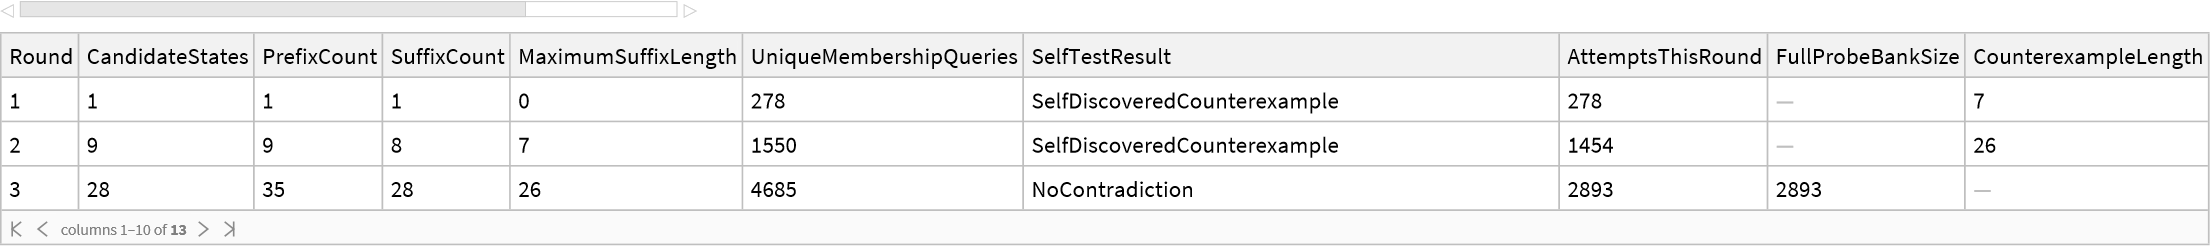

In [4703]:
Dataset[
  learningRoundLogS118R2
]

In [4708]:
Dataset[
  challengePerKindS118R2
]

Dataset[{<|Kind -> ExactShallow, Sequences -> 50, TruePositiveOutputs -> 50, 
 
>     TrueNegativeOutputs -> 0, Matches -> 50, Accuracy -> 1.|>, 
 
>    <|Kind -> ExactDeep, Sequences -> 50, TruePositiveOutputs -> 50, 
 
>     TrueNegativeOutputs -> 0, Matches -> 50, Accuracy -> 1.|>, 
 
>    <|Kind -> ShallowOneShort, Sequences -> 25, TruePositiveOutputs -> 0, 
 
>     TrueNegativeOutputs -> 25, Matches -> 25, Accuracy -> 1.|>, 
 
>    <|Kind -> ShallowOneLong, Sequences -> 25, TruePositiveOutputs -> 0, 
 
>     TrueNegativeOutputs -> 25, Matches -> 25, Accuracy -> 1.|>, 
 
>    <|Kind -> DeepOneShort, Sequences -> 25, TruePositiveOutputs -> 0, 
 
>     TrueNegativeOutputs -> 25, Matches -> 25, Accuracy -> 1.|>, 
 
>    <|Kind -> DeepOneLong, Sequences -> 25, TruePositiveOutputs -> 0, 
 
>     TrueNegativeOutputs -> 25, Matches -> 25, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Kind, Sequences, TruePositiveOutputs, 
 
>      TrueNegativeOutputs, Matches, Accuracy}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real]}], 6], 
 
>   <||>]

In [4713]:
Dataset[
  selectedBoundedProfileS118R2
]


Dataset[{<|FutureDepth -> 0, BehaviorClasses -> 2|>, 
 
>    <|FutureDepth -> 1, BehaviorClasses -> 3|>, 
 
>    <|FutureDepth -> 2, BehaviorClasses -> 4|>, 
 
>    <|FutureDepth -> 4, BehaviorClasses -> 6|>, 
 
>    <|FutureDepth -> 8, BehaviorClasses -> 11|>, 
 
>    <|FutureDepth -> 12, BehaviorClasses -> 15|>, 
 
>    <|FutureDepth -> 16, BehaviorClasses -> 19|>, 
 
>    <|FutureDepth -> 20, BehaviorClasses -> 23|>, 
 
>    <|FutureDepth -> 24, BehaviorClasses -> 27|>, 
 
>    <|FutureDepth -> 28, BehaviorClasses -> 28|>, 
 
>    <|FutureDepth -> 32, BehaviorClasses -> 28|>, 
 
>    <|FutureDepth -> 36, BehaviorClasses -> 28|>, 
 
>    <|FutureDepth -> 40, BehaviorClasses -> 28|>, 
 
>    <|FutureDepth -> 44, BehaviorClasses -> 28|>, 
 
>    <|FutureDepth -> 48, BehaviorClasses -> 28|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{FutureDepth, BehaviorClasses}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 15], <||>]

In [4718]:
Dataset[
  randomHoldoutPerDepthS118R2
]

Dataset[{<|Depth -> 80, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 200, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 500, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 1000, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Sequences, Matches, Accuracy}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 4], <||>]

<|ProbeBankSize -> 2893, Rounds -> 3, SelfDiscoveredCEs -> 2, CELengths -> {7, 26}, 
 
>   CEProbeIndices -> {278, 1454}, FinalFullScanAttempts -> 2893, 
 
>   FullScanInvariant -> True, MembershipQueries -> 4685, LearnedStates -> 28, 
 
>   MaxLearnedSuffix -> 26, RandomHoldoutTouched -> 0, ChallengeTouched -> 0, 
 
>   RandomHoldoutAccuracy -> 1., ChallengeAccuracy -> 1., ChallengePositive -> 100, 
 
>   ChallengeNegative -> 100, ExhaustiveAccuracy -> 1., HiddenDeepDelayPostHoc -> 25, 
 
>   TrueStates -> 28, TrueMinimalStates -> 28, TrueMaxDistinguishingDepth -> 25, 
 
>   FirstFullSeparationDepth -> 25, ShortestLearnedDeepWitness -> 25, 
 
>   StateBijection -> True, TransitionMatches -> 84, TransitionTotal -> 84, 
 
>   SelfCounterexampleDiscovery -> True, DeepCounterexampleDiscovered -> True, 
 
>   ExactMachineIsomorphism -> True, AllFiniteSequenceEquivalent -> True, 
 
>   ProspectiveStrong -> True, Diagnosis -> 
 
>    S118A_R2_SUCCESS_SELF_FALSIFICATION_WITHOUT_EQUIVALENCE_TEACHER_RECOVERS_THE_EXACT_\
 
>     DEEP_MINIMAL_MACHINE_FROM_SELF_DISCOVERED_COUNTEREXAMPLES_AND_PASSES_BALANCED_STRU\
 
>     CTURED_CHALLENGES|>
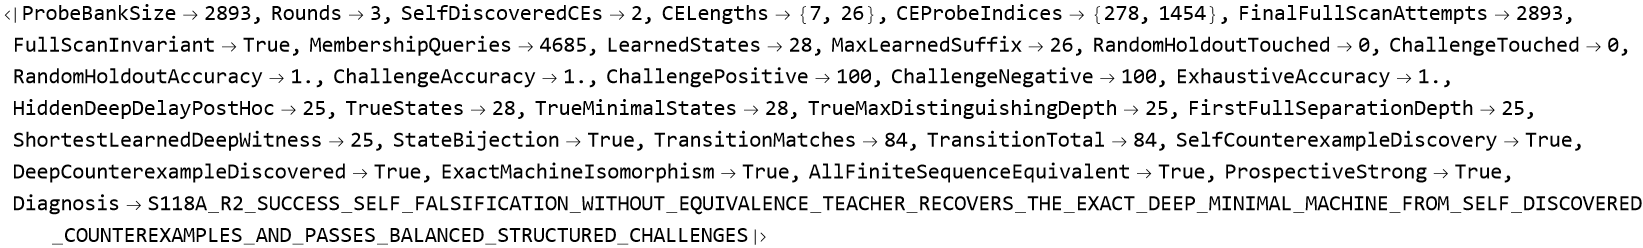

In [4723]:
<|

  "ProbeBankSize" ->
    probeBankSizeS118R2,

  "Rounds" ->
    learningRoundS118R2,

  "SelfDiscoveredCEs" ->
    Length[
      selfDiscoveredCounterexampleLogS118R2
    ],

  "CELengths" ->
    (
      #["Length"] &
    ) /@
      selfDiscoveredCounterexampleLogS118R2,

  "CEProbeIndices" ->
    (
      #["ProbeIndex"] &
    ) /@
      selfDiscoveredCounterexampleLogS118R2,

  "FinalFullScanAttempts" ->
    lastSelfTestAttemptsThisRoundS118R2,

  "FullScanInvariant" ->
    fullScanInvariantPassedS118R2,

  "MembershipQueries" ->
    membershipQueriesBeforeFreezeS118R2,

  "LearnedStates" ->
    learnedStateCountS118R2,

  "MaxLearnedSuffix" ->
    maxLearnedSuffixLengthS118R2,

  "RandomHoldoutTouched" ->
    randomHoldoutTouchedBeforeFreezeS118R2,

  "ChallengeTouched" ->
    challengeHoldoutTouchedBeforeFreezeS118R2,

  "RandomHoldoutAccuracy" ->
    randomHoldoutAccuracyS118R2,

  "ChallengeAccuracy" ->
    challengeAccuracyS118R2,

  "ChallengePositive" ->
    challengeTruePositiveCountS118R2,

  "ChallengeNegative" ->
    challengeTrueNegativeCountS118R2,

  "ExhaustiveAccuracy" ->
    auditAccuracyS118R2,

  "HiddenDeepDelayPostHoc" ->
    hiddenDeepDepthS118R2,

  "TrueStates" ->
    trueReachableCountS118R2,

  "TrueMinimalStates" ->
    trueMinimalStateCountS118R2,

  "TrueMaxDistinguishingDepth" ->
    trueMaxDistinguishingDepthS118R2,

  "FirstFullSeparationDepth" ->
    firstFullSeparationDepthS118R2,

  "ShortestLearnedDeepWitness" ->
    shortestLearnedDeepWitnessLengthS118R2,

  "StateBijection" ->
    stateBijectionPassedS118R2,

  "TransitionMatches" ->
    transitionMatchesS118R2,

  "TransitionTotal" ->
    transitionTotalS118R2,

  "SelfCounterexampleDiscovery" ->
    selfCounterexampleDiscoveryConfirmedS118R2,

  "DeepCounterexampleDiscovered" ->
    deepCounterexampleDiscoveredS118R2,

  "ExactMachineIsomorphism" ->
    exactMachineIsomorphismS118R2,

  "AllFiniteSequenceEquivalent" ->
    allFiniteSequenceEquivalentS118R2,

  "ProspectiveStrong" ->
    prospectiveStrongS118R2,

  "Diagnosis" ->
    diagnosisS118R2

|>

In [5]:
(* ============================================================ *)
(* S118B                                                        *)
(* ADAPTIVE RESIDUAL EXPERIMENT DISCOVERY                       *)
(* ============================================================ *)
(*                                                              *)
(* PURPOSE                                                      *)
(* ------------------------------------------------------------ *)
(* Remove the fixed probe bank from S118A-R2.                   *)
(*                                                              *)
(* The learner does NOT enumerate a pre-built global list of    *)
(* start-state test sequences.                                  *)
(*                                                              *)
(* Instead, after constructing its CURRENT residual machine,    *)
(* it asks:                                                     *)
(*                                                              *)
(*   "Which distinct histories do I currently Union into the    *)
(*    same learned state?"                                      *)
(*                                                              *)
(* For such histories p,q it dynamically generates future       *)
(* experiments z and asks the ordinary membership oracle:       *)
(*                                                              *)
(*            O[p.z]  versus  O[q.z]                            *)
(*                                                              *)
(* If they differ:                                              *)
(*                                                              *)
(*            p != q computationally                            *)
(*                                                              *)
(* and z becomes a self-discovered distinguishing witness.      *)
(*                                                              *)
(* NO:                                                          *)
(* - equivalence oracle                                         *)
(* - teacher counterexample                                     *)
(* - fixed probe bank                                           *)
(* - true state count                                           *)
(* - true state semantics                                       *)
(* - hidden transition table                                    *)
(* - hidden delay                                               *)
(* - hidden token roles                                         *)
(*                                                              *)
(* A bounded experiment LANGUAGE is still frozen in advance:    *)
(* - short suffixes                                             *)
(* - repeated motifs of length 1 or 2                           *)
(* - future depth <= 48                                         *)
(*                                                              *)
(* This tests ADAPTIVE EXPERIMENT SELECTION, not unrestricted    *)
(* open-world exploration.                                      *)
(* ============================================================ *)


ClearAll["Global`S118B*"];
ClearAll["Global`s118B*"];


s118BResult =
Catch[

(

(* ============================================================ *)
(* 0. FAIL SAFE                                                 *)
(* ============================================================ *)

S118BFail[msg_] := (
  Print["STOP: ", msg];
  Throw[$Failed, "S118B_STOP"];
);


Print["================================================"];
Print["S118B ADAPTIVE RESIDUAL EXPERIMENT DISCOVERY"];
Print["================================================"];


(* ============================================================ *)
(* 1. PUBLIC INTERFACE                                          *)
(* ============================================================ *)

alphabetS118B =
  {0, 1, 2};


Print[
  "Primitive alphabet = ",
  alphabetS118B
];


Print["Output alphabet = {0,1}"];
Print["NO EQUIVALENCE ORACLE."];
Print["NO TEACHER-PROVIDED COUNTEREXAMPLES."];
Print["NO FIXED PROBE BANK."];
Print["NO TRUE STATE COUNT."];
Print["NO STATE SEMANTICS."];
Print["MODEL GENERATES EXPERIMENTS FROM ITS CURRENT MERGED STATES."];


(* ============================================================ *)
(* 2. FREEZE ADAPTIVE EXPERIMENT POLICY                         *)
(*                                                              *)
(* Important: benchmark does NOT exist yet.                     *)
(*                                                              *)
(* Alias histories:                                             *)
(* - shortest representative of each learned state              *)
(* - one-token extensions of learned representatives            *)
(*                                                              *)
(* Future experiment language:                                  *)
(* - all short suffixes length <= 2                             *)
(* - repetitions of motifs length 1 or 2                        *)
(* - total suffix length <= 48                                  *)
(*                                                              *)
(* Candidate experiments are generated anew from each CURRENT   *)
(* hypothesis. There is no frozen sequence bank.                *)
(* ============================================================ *)

adaptiveAliasExtensionDepthS118B =
  1;


adaptiveShortSuffixDepthS118B =
  2;


adaptiveMotifMaxLengthS118B =
  2;


adaptiveMaximumFutureDepthS118B =
  48;


adaptiveMaximumAlternativesPerStateS118B =
  12;


adaptivePolicySpecS118B =
  <|

    "Alphabet" ->
      alphabetS118B,

    "AliasExtensionDepth" ->
      adaptiveAliasExtensionDepthS118B,

    "ShortSuffixDepth" ->
      adaptiveShortSuffixDepthS118B,

    "MotifMaximumLength" ->
      adaptiveMotifMaxLengthS118B,

    "MaximumFutureDepth" ->
      adaptiveMaximumFutureDepthS118B,

    "MaximumAlternativesPerLearnedState" ->
      adaptiveMaximumAlternativesPerStateS118B,

    "ExperimentTarget" ->
      "HistoriesCurrentlyMappedToSameLearnedState",

    "ExperimentDecision" ->
      "ObservedFutureBehaviorSplit",

    "FixedProbeBank" ->
      False

  |>;


frozenAdaptivePolicyHashS118B =
  Hash[
    adaptivePolicySpecS118B,
    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["ADAPTIVE EXPERIMENT POLICY FROZEN"];


Print[
  "Alias extension depth = ",
  adaptiveAliasExtensionDepthS118B
];


Print[
  "Short suffix depth = ",
  adaptiveShortSuffixDepthS118B
];


Print[
  "Motif maximum length = ",
  adaptiveMotifMaxLengthS118B
];


Print[
  "Maximum future experiment depth = ",
  adaptiveMaximumFutureDepthS118B
];


Print[
  "Policy hash = ",
  frozenAdaptivePolicyHashS118B
];


Print["NO EXPERIMENT BANK HAS BEEN PRECOMPUTED."];
Print["HIDDEN BENCHMARK DOES NOT YET EXIST."];
Print["================================================"];


(* ============================================================ *)
(* 3. GENERATE NEW HIDDEN BENCHMARK AFTER POLICY FREEZE         *)
(* ============================================================ *)

hiddenBenchmarkSeedS118B =
  1183409;


{
  hiddenDeepDepthS118B,
  hiddenShallowDepthS118B,
  hiddenRolePermutationS118B
} =
  BlockRandom[

    SeedRandom[
      hiddenBenchmarkSeedS118B
    ];


    {
      RandomInteger[
        {18, 36}
      ],

      RandomInteger[
        {4, 8}
      ],

      RandomSample[
        alphabetS118B
      ]
    }
  ];


hiddenDeepEntryTokenS118B =
  hiddenRolePermutationS118B[[1]];


hiddenShallowEntryTokenS118B =
  hiddenRolePermutationS118B[[2]];


hiddenCarryTokenS118B =
  hiddenRolePermutationS118B[[3]];


S118BDelayState[
  depth_Integer
] :=
  3 + depth;


hiddenStartStateS118B =
  1;


S118BEnvStep[
  hiddenState_Integer,
  token_Integer
] :=
Module[
  {
    depth
  },


  Which[

    hiddenState === 1,

      Which[

        token ===
          hiddenDeepEntryTokenS118B,

          S118BDelayState[
            hiddenDeepDepthS118B
          ],


        token ===
          hiddenShallowEntryTokenS118B,

          S118BDelayState[
            hiddenShallowDepthS118B
          ],


        token ===
          hiddenCarryTokenS118B,

          1,


        True,

          Missing[
            "UnknownToken"
          ]
      ],


    hiddenState === 2,

      2,


    hiddenState >= 3,

      depth =
        hiddenState - 3;


      If[
        depth == 0,

        2,

        If[
          token ===
            hiddenCarryTokenS118B,

          S118BDelayState[
            depth - 1
          ],

          2
        ]
      ],


    True,

      Missing[
        "UnknownHiddenState"
      ]
  ]
];


S118BEnvStateOutput[
  hiddenState_Integer
] :=
  Boole[
    hiddenState ===
      S118BDelayState[0]
  ];


S118BEnvStateAfter[
  seq_List
] :=
  Fold[
    S118BEnvStep,
    hiddenStartStateS118B,
    seq
  ];


S118BEnvRawOutput[
  seq_List
] :=
Module[
  {
    state
  },


  state =
    S118BEnvStateAfter[
      seq
    ];


  If[
    IntegerQ[state],

    S118BEnvStateOutput[
      state
    ],

    Missing[
      "EnvironmentFailure"
    ]
  ]
];


Print["NEW HIDDEN BENCHMARK GENERATED AFTER POLICY FREEZE."];
Print["Hidden delay / state count / token roles remain sealed."];


(* ============================================================ *)
(* 4. PROSPECTIVE RANDOM HOLDOUT                                *)
(* ============================================================ *)

randomHoldoutSeedS118B =
  1183410;


randomHoldoutDepthsS118B =
  {
    80,
    200,
    500,
    1000
  };


randomHoldoutPerDepthCountS118B =
  100;


prospectiveRandomHoldoutS118B =
  BlockRandom[

    SeedRandom[
      randomHoldoutSeedS118B
    ];


    Flatten[
      Table[

        Table[

          <|

            "Depth" ->
              depth,

            "Sequence" ->
              RandomChoice[
                alphabetS118B,
                depth
              ]

          |>,

          {
            randomHoldoutPerDepthCountS118B
          }
        ],

        {
          depth,
          randomHoldoutDepthsS118B
        }
      ],

      1
    ]
  ];


Print[
  "Prospective random holdout = ",
  Length[
    prospectiveRandomHoldoutS118B
  ]
];


Print[
  "Random holdout depths = ",
  randomHoldoutDepthsS118B
];


(* ============================================================ *)
(* 5. SEALED BALANCED STRUCTURED CHALLENGE                      *)
(*                                                              *)
(* 100 positive + 100 negative.                                 *)
(* All sequences > adaptive future depth.                       *)
(* Outputs remain unopened until freeze.                        *)
(* ============================================================ *)

challengeExactShallowS118B =
  Table[

    <|

      "Kind" ->
        "ExactShallow",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118B,
            preamble
          ],

          {
            hiddenShallowEntryTokenS118B
          },

          ConstantArray[
            hiddenCarryTokenS118B,
            hiddenShallowDepthS118B
          ]
        ]

    |>,

    {
      preamble,
      70,
      119
    }
  ];


challengeExactDeepS118B =
  Table[

    <|

      "Kind" ->
        "ExactDeep",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118B,
            preamble
          ],

          {
            hiddenDeepEntryTokenS118B
          },

          ConstantArray[
            hiddenCarryTokenS118B,
            hiddenDeepDepthS118B
          ]
        ]

    |>,

    {
      preamble,
      130,
      179
    }
  ];


challengeShallowShortS118B =
  Table[

    <|

      "Kind" ->
        "ShallowOneShort",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118B,
            preamble
          ],

          {
            hiddenShallowEntryTokenS118B
          },

          ConstantArray[
            hiddenCarryTokenS118B,
            hiddenShallowDepthS118B - 1
          ]
        ]

    |>,

    {
      preamble,
      190,
      214
    }
  ];


challengeShallowLongS118B =
  Table[

    <|

      "Kind" ->
        "ShallowOneLong",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118B,
            preamble
          ],

          {
            hiddenShallowEntryTokenS118B
          },

          ConstantArray[
            hiddenCarryTokenS118B,
            hiddenShallowDepthS118B + 1
          ]
        ]

    |>,

    {
      preamble,
      220,
      244
    }
  ];


challengeDeepShortS118B =
  Table[

    <|

      "Kind" ->
        "DeepOneShort",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118B,
            preamble
          ],

          {
            hiddenDeepEntryTokenS118B
          },

          ConstantArray[
            hiddenCarryTokenS118B,
            hiddenDeepDepthS118B - 1
          ]
        ]

    |>,

    {
      preamble,
      250,
      274
    }
  ];


challengeDeepLongS118B =
  Table[

    <|

      "Kind" ->
        "DeepOneLong",

      "Sequence" ->
        Join[
          ConstantArray[
            hiddenCarryTokenS118B,
            preamble
          ],

          {
            hiddenDeepEntryTokenS118B
          },

          ConstantArray[
            hiddenCarryTokenS118B,
            hiddenDeepDepthS118B + 1
          ]
        ]

    |>,

    {
      preamble,
      280,
      304
    }
  ];


prospectiveChallengeHoldoutS118B =
  Join[
    challengeExactShallowS118B,
    challengeExactDeepS118B,
    challengeShallowShortS118B,
    challengeShallowLongS118B,
    challengeDeepShortS118B,
    challengeDeepLongS118B
  ];


Print[
  "Prospective balanced challenge = ",
  Length[
    prospectiveChallengeHoldoutS118B
  ]
];


Print["Challenge outputs remain sealed."];


(* ============================================================ *)
(* 6. MEMBERSHIP ORACLE                                        *)
(* ============================================================ *)

membershipCacheS118B =
  <||>;


membershipFirstSourceS118B =
  <||>;


membershipUniqueCountS118B =
  0;


membershipTotalCallsS118B =
  0;


membershipNewBySourceS118B =
  <|

    "Table" -> 0,

    "AdaptiveExperiment" -> 0,

    "RandomHoldout" -> 0,

    "ChallengeHoldout" -> 0,

    "Audit" -> 0

  |>;


S118BSeqKey[
  seq_List
] :=
  ToString[
    InputForm[
      seq
    ]
  ];


S118BMembershipY[
  seq_List,
  source_String : "Table"
] :=
Module[
  {
    key,
    y,
    oldCount
  },


  membershipTotalCallsS118B++;


  key =
    S118BSeqKey[
      seq
    ];


  If[
    KeyExistsQ[
      membershipCacheS118B,
      key
    ],

    Lookup[
      membershipCacheS118B,
      key
    ],


    y =
      S118BEnvRawOutput[
        seq
      ];


    If[
      !MemberQ[
        {0, 1},
        y
      ],

      S118BFail[
        "Membership oracle returned non-binary output."
      ]
    ];


    membershipUniqueCountS118B++;


    AssociateTo[
      membershipCacheS118B,
      key -> y
    ];


    AssociateTo[
      membershipFirstSourceS118B,
      key -> source
    ];


    oldCount =
      Lookup[
        membershipNewBySourceS118B,
        source,
        0
      ];


    AssociateTo[
      membershipNewBySourceS118B,
      source -> (oldCount + 1)
    ];


    y
  ]
];


(* ============================================================ *)
(* 7. RESIDUAL TABLE                                            *)
(* ============================================================ *)

prefixSetS118B =
  {
    {}
  };


suffixSetS118B =
  {
    {}
  };


S118BRow[
  prefix_List
] :=
  Table[

    S118BMembershipY[
      Join[
        prefix,
        suffix
      ],
      "Table"
    ],

    {
      suffix,
      suffixSetS118B
    }
  ];


S118BRowKey[
  row_List
] :=
  ToString[
    InputForm[
      row
    ]
  ];


S118BFrontier[] :=
  DeleteDuplicates[
    Flatten[
      Table[

        Append[
          prefix,
          token
        ],

        {
          prefix,
          prefixSetS118B
        },

        {
          token,
          alphabetS118B
        }
      ],

      1
    ]
  ];


(* ============================================================ *)
(* 8. CLOSEDNESS                                                *)
(* ============================================================ *)

S118BFindUnclosed[] :=
Module[
  {
    rowsInS,
    frontier
  },


  rowsInS =
    S118BRow /@
      prefixSetS118B;


  frontier =
    S118BFrontier[];


  SelectFirst[
    frontier,

    Function[
      candidate,

      !MemberQ[
        rowsInS,
        S118BRow[
          candidate
        ]
      ]
    ],

    Missing[
      "Closed"
    ]
  ]
];


(* ============================================================ *)
(* 9. CONSISTENCY -- SAFE CATCH/THROW                           *)
(* ============================================================ *)

S118BFindInconsistency[] :=
Module[
  {
    result
  },


  result =
    Catch[

      Module[
        {
          n,
          i,
          j,
          p1,
          p2,
          row1,
          row2,
          successorRow1,
          successorRow2,
          diffPosition,
          oldSuffix,
          newSuffix
        },


        n =
          Length[
            prefixSetS118B
          ];


        For[
          i = 1,
          i <= n,
          i++,


          p1 =
            prefixSetS118B[[i]];


          row1 =
            S118BRow[
              p1
            ];


          For[
            j = i + 1,
            j <= n,
            j++,


            p2 =
              prefixSetS118B[[j]];


            row2 =
              S118BRow[
                p2
              ];


            If[
              row1 === row2,


              Do[

                successorRow1 =
                  S118BRow[
                    Append[
                      p1,
                      token
                    ]
                  ];


                successorRow2 =
                  S118BRow[
                    Append[
                      p2,
                      token
                    ]
                  ];


                If[
                  successorRow1 =!=
                    successorRow2,


                  diffPosition =
                    FirstPosition[
                      MapThread[
                        Unequal,
                        {
                          successorRow1,
                          successorRow2
                        }
                      ],
                      True,
                      Missing[
                        "NotFound"
                      ]
                    ];


                  If[
                    MissingQ[
                      diffPosition
                    ],

                    S118BFail[
                      "Consistency mismatch without suffix position."
                    ]
                  ];


                  oldSuffix =
                    suffixSetS118B[[
                      diffPosition[[1]]
                    ]];


                  newSuffix =
                    Join[
                      {token},
                      oldSuffix
                    ];


                  Throw[

                    <|

                      "Prefix1" ->
                        p1,

                      "Prefix2" ->
                        p2,

                      "Token" ->
                        token,

                      "OldSuffix" ->
                        oldSuffix,

                      "NewSuffix" ->
                        newSuffix

                    |>,

                    "S118B_INCONSISTENCY"
                  ];
                ],

                {
                  token,
                  alphabetS118B
                }
              ];
            ];
          ];
        ];


        Missing[
          "Consistent"
        ]
      ],

      "S118B_INCONSISTENCY"
    ];


  result
];


(* ============================================================ *)
(* 10. STABILIZE TABLE                                          *)
(* ============================================================ *)

tableRepairLogS118B =
  {};


S118BStabilizeTable[] :=
Module[
  {
    done,
    unclosed,
    inconsistency
  },


  done =
    False;


  While[
    !TrueQ[
      done
    ],


    unclosed =
      S118BFindUnclosed[];


    If[
      !MissingQ[
        unclosed
      ],


      prefixSetS118B =
        DeleteDuplicates[
          Append[
            prefixSetS118B,
            unclosed
          ]
        ];


      AppendTo[
        tableRepairLogS118B,

        <|

          "Type" ->
            "Closure",

          "AddedPrefix" ->
            unclosed,

          "PrefixCount" ->
            Length[
              prefixSetS118B
            ],

          "SuffixCount" ->
            Length[
              suffixSetS118B
            ]

        |>
      ],


      inconsistency =
        S118BFindInconsistency[];


      If[
        AssociationQ[
          inconsistency
        ],


        suffixSetS118B =
          DeleteDuplicates[
            Append[
              suffixSetS118B,
              inconsistency[
                "NewSuffix"
              ]
            ]
          ];


        AppendTo[
          tableRepairLogS118B,

          <|

            "Type" ->
              "Consistency",

            "AddedSuffix" ->
              inconsistency[
                "NewSuffix"
              ],

            "AddedSuffixLength" ->
              Length[
                inconsistency[
                  "NewSuffix"
                ]
              ],

            "PrefixCount" ->
              Length[
                prefixSetS118B
              ],

            "SuffixCount" ->
              Length[
                suffixSetS118B
              ]

          |>
        ],


        done =
          True;
      ];
    ];

  ];

];


(* ============================================================ *)
(* 11. BUILD HYPOTHESIS                                         *)
(* ============================================================ *)

S118BBuildHypothesis[] :=
Module[
  {
    rows,
    uniqueRows,
    rowToState,
    representativeByState,
    transitionAssoc,
    outputAssoc,
    rep,
    successorRow,
    successorState,
    i
  },


  rows =
    S118BRow /@
      prefixSetS118B;


  uniqueRows =
    DeleteDuplicates[
      rows
    ];


  rowToState =
    Association[
      Table[

        S118BRowKey[
          uniqueRows[[i]]
        ] ->
          i,

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  representativeByState =
    Association[
      Table[

        i ->

          SelectFirst[
            prefixSetS118B,

            Function[
              prefix,

              S118BRow[
                prefix
              ] ===
                uniqueRows[[i]]
            ]
          ],

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  transitionAssoc =
    <||>;


  outputAssoc =
    <||>;


  Do[

    rep =
      Lookup[
        representativeByState,
        i
      ];


    AssociateTo[
      outputAssoc,

      i ->
        S118BMembershipY[
          rep,
          "Table"
        ]
    ];


    Do[

      successorRow =
        S118BRow[
          Append[
            rep,
            token
          ]
        ];


      successorState =
        Lookup[
          rowToState,

          S118BRowKey[
            successorRow
          ],

          Missing[
            "UnclosedTransition"
          ]
        ];


      If[
        MissingQ[
          successorState
        ],

        S118BFail[
          "Hypothesis built from non-closed table."
        ]
      ];


      AssociateTo[
        transitionAssoc,

        ToString[
          InputForm[
            {
              i,
              token
            }
          ]
        ] ->
          successorState
      ],

      {
        token,
        alphabetS118B
      }
    ],

    {
      i,
      Length[
        uniqueRows
      ]
    }
  ];


  <|

    "StateCount" ->
      Length[
        uniqueRows
      ],

    "Rows" ->
      uniqueRows,

    "RowToState" ->
      rowToState,

    "RepresentativeByState" ->
      representativeByState,

    "Transitions" ->
      transitionAssoc,

    "Outputs" ->
      outputAssoc,

    "StartState" ->
      Lookup[
        rowToState,

        S118BRowKey[
          S118BRow[
            {}
          ]
        ]
      ]

  |>
];


(* ============================================================ *)
(* 12. HYPOTHESIS EXECUTION                                     *)
(* ============================================================ *)

S118BTransitionKey[
  state_Integer,
  token_Integer
] :=
  ToString[
    InputForm[
      {
        state,
        token
      }
    ]
  ];


S118BHypothesisStep[
  hypothesis_Association,
  state_Integer,
  token_Integer
] :=
  Lookup[
    hypothesis[
      "Transitions"
    ],

    S118BTransitionKey[
      state,
      token
    ],

    Missing[
      "UnknownTransition"
    ]
  ];


S118BHypothesisStateAfterFrom[
  hypothesis_Association,
  startState_Integer,
  seq_List
] :=
  Fold[

    Function[
      {
        state,
        token
      },

      If[
        IntegerQ[state],

        S118BHypothesisStep[
          hypothesis,
          state,
          token
        ],

        state
      ]
    ],

    startState,

    seq
  ];


S118BHypothesisStateAfter[
  hypothesis_Association,
  seq_List
] :=
  S118BHypothesisStateAfterFrom[
    hypothesis,
    hypothesis[
      "StartState"
    ],
    seq
  ];


S118BHypothesisOutput[
  hypothesis_Association,
  seq_List
] :=
Module[
  {
    state
  },


  state =
    S118BHypothesisStateAfter[
      hypothesis,
      seq
    ];


  If[
    IntegerQ[state],

    Lookup[
      hypothesis[
        "Outputs"
      ],

      state,

      Missing[
        "UnknownState"
      ]
    ],

    Missing[
      "UnknownTransition"
    ]
  ]
];


(* ============================================================ *)
(* 13. DYNAMICALLY GENERATE ALIAS HISTORIES                     *)
(*                                                              *)
(* No global sequence bank.                                     *)
(*                                                              *)
(* Histories are generated from CURRENT learned state reps.     *)
(*                                                              *)
(* If multiple different histories map to the same CURRENT      *)
(* learned state, they are possible over-Union candidates.      *)
(* ============================================================ *)

S118BAdaptiveHistoryRows[
  hypothesis_Association
] :=
Module[
  {
    representatives,
    extensions,
    histories
  },


  representatives =
    Values[
      hypothesis[
        "RepresentativeByState"
      ]
    ];


  extensions =
    Flatten[
      Table[

        Table[

          Join[
            rep,
            extension
          ],

          {
            extension,
            Flatten[
              Table[

                Tuples[
                  alphabetS118B,
                  len
                ],

                {
                  len,
                  0,
                  adaptiveAliasExtensionDepthS118B
                }
              ],

              1
            ]
          }
        ],

        {
          rep,
          representatives
        }
      ],

      1
    ];


  histories =
    DeleteDuplicates[
      Join[
        representatives,
        extensions
      ]
    ];


  Table[

    <|

      "History" ->
        history,

      "PredictedState" ->
        S118BHypothesisStateAfter[
          hypothesis,
          history
        ],

      "HistoryLength" ->
        Length[
          history
        ]

    |>,

    {
      history,
      histories
    }
  ]
];


(* ============================================================ *)
(* 14. DYNAMIC FUTURE EXPERIMENT LANGUAGE                       *)
(*                                                              *)
(* Generated ON DEMAND each learning round.                     *)
(*                                                              *)
(* No fixed bank is stored before the benchmark.                *)
(* ============================================================ *)

S118BGenerateFutureSuffixes[] :=
Module[
  {
    shortSuffixes,
    motifs,
    repeatedSuffixes,
    maxRepeat,
    suffixes
  },


  shortSuffixes =
    Flatten[
      Table[

        Tuples[
          alphabetS118B,
          len
        ],

        {
          len,
          0,
          adaptiveShortSuffixDepthS118B
        }
      ],

      1
    ];


  motifs =
    Flatten[
      Table[

        Tuples[
          alphabetS118B,
          len
        ],

        {
          len,
          1,
          adaptiveMotifMaxLengthS118B
        }
      ],

      1
    ];


  repeatedSuffixes =
    Flatten[
      Table[

        maxRepeat =
          Floor[
            adaptiveMaximumFutureDepthS118B /
              Length[
                motif
              ]
          ];


        Table[

          Flatten[
            ConstantArray[
              motif,
              repeatCount
            ],
            1
          ],

          {
            repeatCount,
            1,
            maxRepeat
          }
        ],

        {
          motif,
          motifs
        }
      ],

      1
    ];


  suffixes =
    DeleteDuplicates[
      Join[
        shortSuffixes,
        repeatedSuffixes
      ]
    ];


  SortBy[
    suffixes,

    Function[
      suffix,
      {
        Length[
          suffix
        ],
        ToString[
          InputForm[
            suffix
          ]
        ]
      }
    ]
  ]
];


(* ============================================================ *)
(* 15. BUILD ADAPTIVE EXPERIMENTS FROM CURRENT UNION CLASSES    *)
(*                                                              *)
(* Each experiment compares:                                    *)
(*                                                              *)
(*   canonical history p                                        *)
(*   alternative history q                                      *)
(*                                                              *)
(* where CURRENT model says:                                    *)
(*                                                              *)
(*   C(p) == C(q).                                              *)
(*                                                              *)
(* Therefore any future z with O[pz] != O[qz] directly          *)
(* falsifies the current merge.                                 *)
(* ============================================================ *)

S118BBuildAdaptiveExperiments[
  hypothesis_Association
] :=
Module[
  {
    historyRows,
    grouped,
    suffixes,
    experiments,
    state,
    rows,
    canonical,
    alternatives
  },


  historyRows =
    S118BAdaptiveHistoryRows[
      hypothesis
    ];


  grouped =
    GroupBy[
      historyRows,
      #["PredictedState"] &
    ];


  suffixes =
    S118BGenerateFutureSuffixes[];


  experiments =
    {};


  Do[

    rows =
      Lookup[
        grouped,
        state,
        {}
      ];


    canonical =
      Lookup[
        hypothesis[
          "RepresentativeByState"
        ],
        state,
        Missing[
          "NoRepresentative"
        ]
      ];


    If[
      ListQ[
        canonical
      ],


      alternatives =
        Select[
          rows,

          #["History"] =!=
            canonical &
        ];


      alternatives =
        SortBy[
          alternatives,

          Function[
            row,
            {
              row[
                "HistoryLength"
              ],
              ToString[
                InputForm[
                  row[
                    "History"
                  ]
                ]
              ]
            }
          ]
        ];


      alternatives =
        Take[
          alternatives,
          UpTo[
            adaptiveMaximumAlternativesPerStateS118B
          ]
        ];


      Do[

        Do[

          AppendTo[
            experiments,

            <|

              "LearnedState" ->
                state,

              "History1" ->
                canonical,

              "History2" ->
                alt[
                  "History"
                ],

              "Suffix" ->
                suffix,

              "SuffixLength" ->
                Length[
                  suffix
                ],

              "AlternativeHistoryLength" ->
                alt[
                  "HistoryLength"
                ]

            |>
          ],

          {
            suffix,
            suffixes
          }
        ],

        {
          alt,
          alternatives
        }
      ];
    ],

    {
      state,
      Range[
        hypothesis[
          "StateCount"
        ]
      ]
    }
  ];


  SortBy[
    experiments,

    Function[
      exp,
      {
        exp[
          "SuffixLength"
        ],
        exp[
          "AlternativeHistoryLength"
        ],
        exp[
          "LearnedState"
        ],
        ToString[
          InputForm[
            exp[
              "History2"
            ]
          ]
        ],
        ToString[
          InputForm[
            exp[
              "Suffix"
            ]
          ]
        ]
      }
    ]
  ]
];


(* ============================================================ *)
(* 16. ADAPTIVE SELF-DISCRIMINATION                             *)
(*                                                              *)
(* This replaces the fixed 2893-probe scan.                     *)
(*                                                              *)
(* Experiments are constructed from current merged histories.   *)
(* ============================================================ *)

adaptiveSearchRoundCountS118B =
  0;


adaptiveExperimentAttemptsTotalS118B =
  0;


lastAdaptiveExperimentCountS118B =
  0;


lastAdaptiveAttemptsThisRoundS118B =
  0;


adaptiveWitnessLogS118B =
  {};


S118BFindAdaptiveWitness[
  hypothesis_Association
] :=
Module[
  {
    experiments,
    result,
    attempts,
    i,
    exp,
    seq1,
    seq2,
    observed1,
    observed2,
    predictedState1,
    predictedState2,
    predictedOutput1,
    predictedOutput2
  },


  adaptiveSearchRoundCountS118B++;


  experiments =
    S118BBuildAdaptiveExperiments[
      hypothesis
    ];


  lastAdaptiveExperimentCountS118B =
    Length[
      experiments
    ];


  attempts =
    0;


  result =
    Catch[

      Do[

        exp =
          experiments[[i]];


        attempts++;


        adaptiveExperimentAttemptsTotalS118B++;


        predictedState1 =
          S118BHypothesisStateAfter[
            hypothesis,
            exp[
              "History1"
            ]
          ];


        predictedState2 =
          S118BHypothesisStateAfter[
            hypothesis,
            exp[
              "History2"
            ]
          ];


        If[
          predictedState1 =!=
            predictedState2,

          S118BFail[
            "Adaptive experiment compared histories not currently merged."
          ]
        ];


        seq1 =
          Join[
            exp[
              "History1"
            ],
            exp[
              "Suffix"
            ]
          ];


        seq2 =
          Join[
            exp[
              "History2"
            ],
            exp[
              "Suffix"
            ]
          ];


        predictedOutput1 =
          S118BHypothesisOutput[
            hypothesis,
            seq1
          ];


        predictedOutput2 =
          S118BHypothesisOutput[
            hypothesis,
            seq2
          ];


        If[
          predictedOutput1 =!=
            predictedOutput2,

          S118BFail[
            "Merged histories unexpectedly have different learned predictions."
          ]
        ];


        observed1 =
          S118BMembershipY[
            seq1,
            "AdaptiveExperiment"
          ];


        observed2 =
          S118BMembershipY[
            seq2,
            "AdaptiveExperiment"
          ];


        If[
          observed1 =!=
            observed2,


          Throw[

            <|

              "ExperimentIndex" ->
                i,

              "LearnedStateBeforeSplit" ->
                exp[
                  "LearnedState"
                ],

              "History1" ->
                exp[
                  "History1"
                ],

              "History2" ->
                exp[
                  "History2"
                ],

              "Suffix" ->
                exp[
                  "Suffix"
                ],

              "SuffixLength" ->
                exp[
                  "SuffixLength"
                ],

              "FullSequence1" ->
                seq1,

              "FullSequence2" ->
                seq2,

              "PredictedOutput1" ->
                predictedOutput1,

              "PredictedOutput2" ->
                predictedOutput2,

              "ObservedOutput1" ->
                observed1,

              "ObservedOutput2" ->
                observed2

            |>,

            "S118B_ADAPTIVE_WITNESS"
          ];
        ],

        {
          i,
          1,
          Length[
            experiments
          ]
        }
      ];


      Missing[
        "NoAdaptiveDistinguishingWitness"
      ],

      "S118B_ADAPTIVE_WITNESS"
    ];


  lastAdaptiveAttemptsThisRoundS118B =
    attempts;


  result
];


(* ============================================================ *)
(* 17. ADAPTIVE WITNESS REFINEMENT                              *)
(*                                                              *)
(* If O[pz] != O[qz], then p and q must split.                  *)
(*                                                              *)
(* Add:                                                         *)
(* - prefixes of p.z and q.z                                    *)
(* - suffix z and all tails of z                                *)
(* ============================================================ *)

S118BPrefixesOf[
  seq_List
] :=
  Table[
    Take[
      seq,
      k
    ],
    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S118BSuffixesOf[
  seq_List
] :=
  Table[
    Drop[
      seq,
      k
    ],
    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S118BRefineFromAdaptiveWitness[
  witness_Association
] :=
(

  prefixSetS118B =
    DeleteDuplicates[
      Join[
        prefixSetS118B,

        S118BPrefixesOf[
          witness[
            "FullSequence1"
          ]
        ],

        S118BPrefixesOf[
          witness[
            "FullSequence2"
          ]
        ]
      ]
    ];


  suffixSetS118B =
    DeleteDuplicates[
      Join[
        suffixSetS118B,

        S118BSuffixesOf[
          witness[
            "Suffix"
          ]
        ]
      ]
    ];

);


(* ============================================================ *)
(* 18. ACTIVE ADAPTIVE LEARNING LOOP                            *)
(* ============================================================ *)

learningRoundS118B =
  0;


learningRoundLogS118B =
  {};


candidateHypothesisS118B =
  Missing[
    "NotBuilt"
  ];


adaptiveSearchStableS118B =
  False;


adaptiveFullScanInvariantPassedS118B =
  True;


Print["================================================"];
Print["ACTIVE HYPOTHESIS-GUIDED EXPERIMENT LEARNING"];
Print["================================================"];


learningTimingS118B =
  AbsoluteTiming[

    While[
      !TrueQ[
        adaptiveSearchStableS118B
      ],


      learningRoundS118B++;


      If[
        learningRoundS118B > 100,

        S118BFail[
          "Learning-round safety limit exceeded."
        ]
      ];


      S118BStabilizeTable[];


      candidateHypothesisS118B =
        S118BBuildHypothesis[];


      adaptiveWitnessS118B =
        S118BFindAdaptiveWitness[
          candidateHypothesisS118B
        ];


      (* ------------------------------------------------------ *)
      (* HARD CONTROL-FLOW INVARIANTS                           *)
      (* ------------------------------------------------------ *)

      If[
        MissingQ[
          adaptiveWitnessS118B
        ] &&

        lastAdaptiveAttemptsThisRoundS118B =!=
          lastAdaptiveExperimentCountS118B,


        adaptiveFullScanInvariantPassedS118B =
          False;


        S118BFail[
          StringJoin[
            "No witness returned after only ",
            ToString[
              lastAdaptiveAttemptsThisRoundS118B
            ],
            " / ",
            ToString[
              lastAdaptiveExperimentCountS118B
            ],
            " dynamically generated experiments."
          ]
        ]
      ];


      If[
        AssociationQ[
          adaptiveWitnessS118B
        ] &&

        adaptiveWitnessS118B[
          "ExperimentIndex"
        ] =!=
          lastAdaptiveAttemptsThisRoundS118B,


        adaptiveFullScanInvariantPassedS118B =
          False;


        S118BFail[
          "Adaptive witness index does not equal attempts-this-round."
        ]
      ];


      If[
        AssociationQ[
          adaptiveWitnessS118B
        ] &&

        adaptiveWitnessS118B[
          "ObservedOutput1"
        ] ===
          adaptiveWitnessS118B[
            "ObservedOutput2"
          ],


        adaptiveFullScanInvariantPassedS118B =
          False;


        S118BFail[
          "Returned adaptive witness does not actually split future behavior."
        ]
      ];


      If[
        MissingQ[
          adaptiveWitnessS118B
        ],


        adaptiveSearchStableS118B =
          True;


        AppendTo[
          learningRoundLogS118B,

          <|

            "Round" ->
              learningRoundS118B,

            "CandidateStates" ->
              candidateHypothesisS118B[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS118B
              ],

            "SuffixCount" ->
              Length[
                suffixSetS118B
              ],

            "MaximumSuffixLength" ->
              Max[
                Length /@
                  suffixSetS118B
              ],

            "UniqueMembershipQueries" ->
              membershipUniqueCountS118B,

            "AdaptiveCandidateExperiments" ->
              lastAdaptiveExperimentCountS118B,

            "AdaptiveAttempts" ->
              lastAdaptiveAttemptsThisRoundS118B,

            "Result" ->
              "NoDistinguishingWitness",

            "WitnessSuffixLength" ->
              Missing[
                "None"
              ]

          |>
        ],


        AppendTo[
          adaptiveWitnessLogS118B,
          adaptiveWitnessS118B
        ];


        AppendTo[
          learningRoundLogS118B,

          <|

            "Round" ->
              learningRoundS118B,

            "CandidateStates" ->
              candidateHypothesisS118B[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS118B
              ],

            "SuffixCount" ->
              Length[
                suffixSetS118B
              ],

            "MaximumSuffixLength" ->
              Max[
                Length /@
                  suffixSetS118B
              ],

            "UniqueMembershipQueries" ->
              membershipUniqueCountS118B,

            "AdaptiveCandidateExperiments" ->
              lastAdaptiveExperimentCountS118B,

            "AdaptiveAttempts" ->
              lastAdaptiveAttemptsThisRoundS118B,

            "Result" ->
              "SelfDiscoveredStateSplit",

            "LearnedStateBeforeSplit" ->
              adaptiveWitnessS118B[
                "LearnedStateBeforeSplit"
              ],

            "WitnessSuffixLength" ->
              adaptiveWitnessS118B[
                "SuffixLength"
              ],

            "ObservedPair" ->
              {
                adaptiveWitnessS118B[
                  "ObservedOutput1"
                ],

                adaptiveWitnessS118B[
                  "ObservedOutput2"
                ]
              }

          |>
        ];


        S118BRefineFromAdaptiveWitness[
          adaptiveWitnessS118B
        ];
      ];


      Print[
        "Round ",
        learningRoundS118B,

        ": states = ",
        candidateHypothesisS118B[
          "StateCount"
        ],

        ", prefixes = ",
        Length[
          prefixSetS118B
        ],

        ", suffixes = ",
        Length[
          suffixSetS118B
        ],

        ", max suffix = ",
        Max[
          Length /@
            suffixSetS118B
        ],

        ", membership queries = ",
        membershipUniqueCountS118B,

        ", adaptive experiments = ",
        lastAdaptiveExperimentCountS118B,

        ", attempts = ",
        lastAdaptiveAttemptsThisRoundS118B,

        ", result = ",

        If[
          adaptiveSearchStableS118B,

          "FULL ADAPTIVE SEARCH: NO SPLIT",

          StringJoin[
            "SELF STATE-SPLIT SUFFIX LENGTH ",
            ToString[
              adaptiveWitnessS118B[
                "SuffixLength"
              ]
            ]
          ]
        ]
      ];

    ];

  ];


Print[
  "Learning seconds = ",
  N[
    learningTimingS118B[[1]]
  ]
];


Print[
  "Learning rounds = ",
  learningRoundS118B
];


Print[
  "Adaptive state-splitting witnesses = ",
  Length[
    adaptiveWitnessLogS118B
  ]
];


Print[
  "Witness suffix lengths = ",
  (
    #[
      "SuffixLength"
    ] &
  ) /@
    adaptiveWitnessLogS118B
];


Print[
  "Final residual states = ",
  candidateHypothesisS118B[
    "StateCount"
  ]
];


Print[
  "Final suffix count = ",
  Length[
    suffixSetS118B
  ]
];


Print[
  "Maximum learned suffix length = ",
  Max[
    Length /@
      suffixSetS118B
  ]
];


Print[
  "Final adaptive experiment candidates = ",
  lastAdaptiveExperimentCountS118B
];


Print[
  "Final adaptive experiments scanned = ",
  lastAdaptiveAttemptsThisRoundS118B
];


Print[
  "Adaptive full-scan invariant = ",
  adaptiveFullScanInvariantPassedS118B
];


Print[
  "Membership queries = ",
  membershipUniqueCountS118B
];


Print[
  "Membership queries by source = ",
  membershipNewBySourceS118B
];


(* ============================================================ *)
(* 19. HOLDOUT LEAKAGE                                          *)
(* ============================================================ *)

randomHoldoutTouchedBeforeFreezeS118B =
  Count[
    prospectiveRandomHoldoutS118B,

    row_Association /;

      KeyExistsQ[
        membershipCacheS118B,

        S118BSeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


challengeHoldoutTouchedBeforeFreezeS118B =
  Count[
    prospectiveChallengeHoldoutS118B,

    row_Association /;

      KeyExistsQ[
        membershipCacheS118B,

        S118BSeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


Print[
  "Random holdout touched before freeze = ",
  randomHoldoutTouchedBeforeFreezeS118B,
  " / ",
  Length[
    prospectiveRandomHoldoutS118B
  ]
];


Print[
  "Challenge holdout touched before freeze = ",
  challengeHoldoutTouchedBeforeFreezeS118B,
  " / ",
  Length[
    prospectiveChallengeHoldoutS118B
  ]
];


(* ============================================================ *)
(* 20. POLICY HASH CHECK                                        *)
(* ============================================================ *)

recomputedAdaptivePolicyHashS118B =
  Hash[
    adaptivePolicySpecS118B,
    "SHA256",
    "HexString"
  ];


adaptivePolicyHashUnchangedS118B =
  recomputedAdaptivePolicyHashS118B ===
    frozenAdaptivePolicyHashS118B;


Print[
  "Adaptive policy hash unchanged = ",
  adaptivePolicyHashUnchangedS118B
];


If[
  !TrueQ[
    adaptivePolicyHashUnchangedS118B
  ],

  S118BFail[
    "Adaptive experiment policy changed after benchmark generation."
  ]
];


(* ============================================================ *)
(* 21. FREEZE MACHINE                                           *)
(* ============================================================ *)

frozenHypothesisS118B =
  candidateHypothesisS118B;


frozenSuffixSetS118B =
  suffixSetS118B;


membershipQueriesBeforeFreezeS118B =
  membershipUniqueCountS118B;


frozenMachineHashS118B =
  Hash[
    {
      frozenHypothesisS118B[
        "StateCount"
      ],
      frozenHypothesisS118B[
        "Transitions"
      ],
      frozenHypothesisS118B[
        "Outputs"
      ],
      frozenHypothesisS118B[
        "StartState"
      ],
      frozenHypothesisS118B[
        "RepresentativeByState"
      ],
      frozenSuffixSetS118B
    },

    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S118B MACHINE FROZEN"];


Print[
  "States = ",
  frozenHypothesisS118B[
    "StateCount"
  ]
];


Print[
  "Transitions = ",
  Length[
    frozenHypothesisS118B[
      "Transitions"
    ]
  ]
];


Print[
  "Suffixes = ",
  Length[
    frozenSuffixSetS118B
  ]
];


Print[
  "Maximum learned suffix = ",
  Max[
    Length /@
      frozenSuffixSetS118B
  ]
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS118B
];


Print[
  "Machine hash = ",
  frozenMachineHashS118B
];


Print["NO LEARNED STATE / TRANSITION / SUFFIX CHANGES AFTER THIS POINT."];
Print["================================================"];


(* ============================================================ *)
(* 22. OPEN RANDOM HOLDOUT                                      *)
(* ============================================================ *)

Print["================================================"];
Print["OPENING RANDOM LONG HOLDOUT"];
Print["================================================"];


randomHoldoutRowsS118B =
  Table[

    Module[
      {
        seq,
        learnedY,
        trueY
      },


      seq =
        row[
          "Sequence"
        ];


      learnedY =
        S118BHypothesisOutput[
          frozenHypothesisS118B,
          seq
        ];


      trueY =
        S118BMembershipY[
          seq,
          "RandomHoldout"
        ];


      <|

        "Depth" ->
          row[
            "Depth"
          ],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY ===
              trueY
          )

      |>

    ],

    {
      row,
      prospectiveRandomHoldoutS118B
    }
  ];


randomHoldoutMatchesS118B =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      randomHoldoutRowsS118B,
    True
  ];


randomHoldoutAccuracyS118B =
  N[
    randomHoldoutMatchesS118B /
      Length[
        randomHoldoutRowsS118B
      ]
  ];


randomHoldoutPerDepthS118B =
  Table[

    Module[
      {
        rows,
        matches
      },


      rows =
        Select[
          randomHoldoutRowsS118B,
          #["Depth"] === depth &
        ];


      matches =
        Count[
          (
            TrueQ[
              #["Match"]
            ] &
          ) /@
            rows,
          True
        ];


      <|

        "Depth" ->
          depth,

        "Sequences" ->
          Length[
            rows
          ],

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      depth,
      randomHoldoutDepthsS118B
    }
  ];


Print[
  "Random holdout = ",
  randomHoldoutMatchesS118B,
  " / ",
  Length[
    randomHoldoutRowsS118B
  ]
];


(* ============================================================ *)
(* 23. OPEN BALANCED CHALLENGE                                  *)
(* ============================================================ *)

Print["================================================"];
Print["OPENING BALANCED STRUCTURED CHALLENGE"];
Print["================================================"];


challengeRowsS118B =
  Table[

    Module[
      {
        seq,
        learnedY,
        trueY
      },


      seq =
        row[
          "Sequence"
        ];


      learnedY =
        S118BHypothesisOutput[
          frozenHypothesisS118B,
          seq
        ];


      trueY =
        S118BMembershipY[
          seq,
          "ChallengeHoldout"
        ];


      <|

        "Kind" ->
          row[
            "Kind"
          ],

        "Length" ->
          Length[
            seq
          ],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY ===
              trueY
          )

      |>

    ],

    {
      row,
      prospectiveChallengeHoldoutS118B
    }
  ];


challengeMatchesS118B =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      challengeRowsS118B,
    True
  ];


challengeAccuracyS118B =
  N[
    challengeMatchesS118B /
      Length[
        challengeRowsS118B
      ]
  ];


challengePositiveCountS118B =
  Count[
    (
      #["TrueY"] &
    ) /@
      challengeRowsS118B,
    1
  ];


challengeNegativeCountS118B =
  Count[
    (
      #["TrueY"] &
    ) /@
      challengeRowsS118B,
    0
  ];


challengeBalancedS118B =
  And[
    challengePositiveCountS118B === 100,
    challengeNegativeCountS118B === 100
  ];


challengePerKindS118B =
  Table[

    Module[
      {
        rows,
        matches,
        positive,
        negative
      },


      rows =
        Select[
          challengeRowsS118B,
          #["Kind"] === kind &
        ];


      matches =
        Count[
          (
            TrueQ[
              #["Match"]
            ] &
          ) /@
            rows,
          True
        ];


      positive =
        Count[
          (
            #["TrueY"] &
          ) /@
            rows,
          1
        ];


      negative =
        Count[
          (
            #["TrueY"] &
          ) /@
            rows,
          0
        ];


      <|

        "Kind" ->
          kind,

        "Sequences" ->
          Length[
            rows
          ],

        "PositiveOutputs" ->
          positive,

        "NegativeOutputs" ->
          negative,

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      kind,
      DeleteDuplicates[
        (
          #["Kind"] &
        ) /@
          challengeRowsS118B
      ]
    }
  ];


Print[
  "Balanced challenge = ",
  challengeMatchesS118B,
  " / ",
  Length[
    challengeRowsS118B
  ]
];


Print[
  "Challenge outputs: positive = ",
  challengePositiveCountS118B,
  ", negative = ",
  challengeNegativeCountS118B
];


(* ============================================================ *)
(* 24. EXHAUSTIVE SHORT AUDIT                                   *)
(* ============================================================ *)

auditMaxLengthS118B =
  8;


auditSequencesS118B =
  Flatten[
    Table[

      Tuples[
        alphabetS118B,
        len
      ],

      {
        len,
        0,
        auditMaxLengthS118B
      }
    ],

    1
  ];


auditRowsS118B =
  Table[

    Module[
      {
        learnedY,
        trueY
      },


      learnedY =
        S118BHypothesisOutput[
          frozenHypothesisS118B,
          seq
        ];


      trueY =
        S118BMembershipY[
          seq,
          "Audit"
        ];


      <|

        "Length" ->
          Length[
            seq
          ],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY ===
              trueY
          )

      |>

    ],

    {
      seq,
      auditSequencesS118B
    }
  ];


auditMatchesS118B =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      auditRowsS118B,
    True
  ];


auditAccuracyS118B =
  N[
    auditMatchesS118B /
      Length[
        auditRowsS118B
      ]
  ];


Print[
  "Exhaustive audit length 0..",
  auditMaxLengthS118B,
  " = ",
  auditMatchesS118B,
  " / ",
  Length[
    auditRowsS118B
  ]
];


(* ============================================================ *)
(* 25. VERIFY MACHINE HASH                                      *)
(* ============================================================ *)

recomputedMachineHashS118B =
  Hash[
    {
      frozenHypothesisS118B[
        "StateCount"
      ],
      frozenHypothesisS118B[
        "Transitions"
      ],
      frozenHypothesisS118B[
        "Outputs"
      ],
      frozenHypothesisS118B[
        "StartState"
      ],
      frozenHypothesisS118B[
        "RepresentativeByState"
      ],
      frozenSuffixSetS118B
    },

    "SHA256",
    "HexString"
  ];


frozenMachineHashUnchangedS118B =
  recomputedMachineHashS118B ===
    frozenMachineHashS118B;


If[
  !TrueQ[
    frozenMachineHashUnchangedS118B
  ],

  S118BFail[
    "Frozen learned machine changed after freeze."
  ]
];


Print[
  "Frozen machine hash unchanged = ",
  frozenMachineHashUnchangedS118B
];


(* ============================================================ *)
(* 26. ONLY NOW REVEAL TRUE BENCHMARK                           *)
(* ============================================================ *)

Print["================================================"];
Print["POST-HOC HIDDEN BENCHMARK OPENED"];
Print["================================================"];


Print[
  "Hidden deep delay = ",
  hiddenDeepDepthS118B
];


Print[
  "Hidden shallow delay = ",
  hiddenShallowDepthS118B
];


Print[
  "Hidden role permutation = ",
  hiddenRolePermutationS118B
];


Print[
  "Deep-entry token = ",
  hiddenDeepEntryTokenS118B
];


Print[
  "Shallow-entry token = ",
  hiddenShallowEntryTokenS118B
];


Print[
  "Carry token = ",
  hiddenCarryTokenS118B
];


(* ============================================================ *)
(* 27. TRUE REACHABLE STATES                                    *)
(* ============================================================ *)

S118BTrueReachableStates[] :=
Module[
  {
    seen,
    queue,
    current,
    next
  },


  seen =
    {
      hiddenStartStateS118B
    };


  queue =
    {
      hiddenStartStateS118B
    };


  While[
    Length[
      queue
    ] > 0,


    current =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    Do[

      next =
        S118BEnvStep[
          current,
          token
        ];


      If[
        !MemberQ[
          seen,
          next
        ],

        AppendTo[
          seen,
          next
        ];


        AppendTo[
          queue,
          next
        ];
      ],

      {
        token,
        alphabetS118B
      }
    ];

  ];


  Sort[
    seen
  ]
];


trueReachableStatesS118B =
  S118BTrueReachableStates[];


trueReachableCountS118B =
  Length[
    trueReachableStatesS118B
  ];


Print[
  "True reachable states = ",
  trueReachableCountS118B
];


(* ============================================================ *)
(* 28. TRUE MINIMALITY                                          *)
(* ============================================================ *)

S118BTrueMinimalPartition[] :=
Module[
  {
    partition,
    stateToBlock,
    signatures,
    newPartition,
    stable
  },


  partition =
    Values[
      GroupBy[
        trueReachableStatesS118B,

        Function[
          state,
          S118BEnvStateOutput[
            state
          ]
        ]
      ]
    ];


  stable =
    False;


  While[
    !TrueQ[
      stable
    ],


    stateToBlock =
      Association[
        Flatten[
          Table[

            Table[
              state -> blockIndex,

              {
                state,
                partition[[blockIndex]]
              }
            ],

            {
              blockIndex,
              Length[
                partition
              ]
            }
          ]
        ]
      ];


    signatures =
      Association[
        Table[

          state ->

            Join[
              {
                S118BEnvStateOutput[
                  state
                ]
              },

              Table[
                Lookup[
                  stateToBlock,

                  S118BEnvStep[
                    state,
                    token
                  ]
                ],

                {
                  token,
                  alphabetS118B
                }
              ]
            ],

          {
            state,
            trueReachableStatesS118B
          }
        ]
      ];


    newPartition =
      Values[
        GroupBy[
          trueReachableStatesS118B,

          Function[
            state,
            Lookup[
              signatures,
              state
            ]
          ]
        ]
      ];


    If[
      Sort[
        Sort /@
          newPartition
      ] ===
        Sort[
          Sort /@
            partition
        ],

      stable =
        True,

      partition =
        newPartition;
    ];

  ];


  partition
];


trueMinimalPartitionS118B =
  S118BTrueMinimalPartition[];


trueMinimalStateCountS118B =
  Length[
    trueMinimalPartitionS118B
  ];


trueMachineMinimalS118B =
  And[
    trueMinimalStateCountS118B ==
      trueReachableCountS118B,

    AllTrue[
      trueMinimalPartitionS118B,
      Length[#] == 1 &
    ]
  ];


Print[
  "True behavioral-minimal states = ",
  trueMinimalStateCountS118B
];


Print[
  "True machine minimal = ",
  trueMachineMinimalS118B
];


(* ============================================================ *)
(* 29. IMMEDIATE ALIASING                                       *)
(* ============================================================ *)

immediateOutputGroupsS118B =
  Values[
    GroupBy[
      trueReachableStatesS118B,

      Function[
        state,
        S118BEnvStateOutput[
          state
        ]
      ]
    ]
  ];


immediateOutputBlockSizesS118B =
  Reverse[
    Sort[
      Length /@
        immediateOutputGroupsS118B
    ]
  ];


totalTrueStatePairsS118B =
  Binomial[
    trueReachableCountS118B,
    2
  ];


sameImmediateOutputPairsS118B =
  Total[
    (
      Binomial[
        #,
        2
      ] &
    ) /@
      immediateOutputBlockSizesS118B
  ];


immediateAliasFractionS118B =
  If[
    totalTrueStatePairsS118B > 0,

    N[
      sameImmediateOutputPairsS118B /
        totalTrueStatePairsS118B
    ],

    0.
  ];


Print[
  "Immediate output blocks = ",
  immediateOutputBlockSizesS118B
];


Print[
  "Immediate alias fraction = ",
  immediateAliasFractionS118B
];


(* ============================================================ *)
(* 30. BOUNDED FUTURE-SEPARATION PROFILE                        *)
(* ============================================================ *)

S118BBoundedPartitionProfile[] :=
Module[
  {
    partition,
    profile,
    stateToBlock,
    signatures
  },


  partition =
    Values[
      GroupBy[
        trueReachableStatesS118B,

        Function[
          state,
          S118BEnvStateOutput[
            state
          ]
        ]
      ]
    ];


  profile =
    {
      <|
        "FutureDepth" -> 0,
        "BehaviorClasses" ->
          Length[
            partition
          ]
      |>
    };


  Do[

    stateToBlock =
      Association[
        Flatten[
          Table[

            Table[
              state -> blockIndex,

              {
                state,
                partition[[blockIndex]]
              }
            ],

            {
              blockIndex,
              Length[
                partition
              ]
            }
          ]
        ]
      ];


    signatures =
      Association[
        Table[

          state ->

            Join[
              {
                S118BEnvStateOutput[
                  state
                ]
              },

              Table[
                Lookup[
                  stateToBlock,

                  S118BEnvStep[
                    state,
                    token
                  ]
                ],

                {
                  token,
                  alphabetS118B
                }
              ]
            ],

          {
            state,
            trueReachableStatesS118B
          }
        ]
      ];


    partition =
      Values[
        GroupBy[
          trueReachableStatesS118B,

          Function[
            state,
            Lookup[
              signatures,
              state
            ]
          ]
        ]
      ];


    AppendTo[
      profile,

      <|

        "FutureDepth" ->
          depth,

        "BehaviorClasses" ->
          Length[
            partition
          ]

      |>
    ],

    {
      depth,
      1,
      adaptiveMaximumFutureDepthS118B
    }
  ];


  profile
];


boundedPartitionProfileS118B =
  S118BBoundedPartitionProfile[];


fullSeparationRowsS118B =
  Select[
    boundedPartitionProfileS118B,

    #["BehaviorClasses"] ===
      trueMinimalStateCountS118B &
  ];


firstFullSeparationDepthS118B =
  If[
    Length[
      fullSeparationRowsS118B
    ] > 0,

    First[
      fullSeparationRowsS118B
    ][
      "FutureDepth"
    ],

    Missing[
      "NotFullySeparated"
    ]
  ];


selectedBoundedProfileS118B =
  Select[
    boundedPartitionProfileS118B,

    MemberQ[
      {
        0, 1, 2, 4, 8, 12,
        16, 20, 24, 28,
        32, 36, 40, 44, 48
      },
      #["FutureDepth"]
    ] &
  ];


Print[
  "First full-separation depth = ",
  firstFullSeparationDepthS118B
];


(* ============================================================ *)
(* 31. TRUE PAIRWISE DISTINGUISHING DEPTH                       *)
(* ============================================================ *)

S118BTruePairDistinguishingDepth[
  state1_Integer,
  state2_Integer
] :=
Module[
  {
    result
  },


  result =
    Catch[

      Module[
        {
          queue,
          visited,
          current,
          s1,
          s2,
          depth,
          key
        },


        queue =
          {
            {
              state1,
              state2,
              0
            }
          };


        visited =
          <||>;


        While[
          Length[
            queue
          ] > 0,


          current =
            First[
              queue
            ];


          queue =
            Rest[
              queue
            ];


          s1 =
            current[[1]];


          s2 =
            current[[2]];


          depth =
            current[[3]];


          key =
            ToString[
              InputForm[
                Sort[
                  {
                    s1,
                    s2
                  }
                ]
              ]
            ];


          If[
            !KeyExistsQ[
              visited,
              key
            ],


            AssociateTo[
              visited,
              key -> True
            ];


            If[
              S118BEnvStateOutput[
                s1
              ] =!=
                S118BEnvStateOutput[
                  s2
                ],

              Throw[
                depth,
                "S118B_DISTINGUISHED"
              ];
            ];


            Do[

              AppendTo[
                queue,

                {
                  S118BEnvStep[
                    s1,
                    token
                  ],

                  S118BEnvStep[
                    s2,
                    token
                  ],

                  depth + 1
                }
              ],

              {
                token,
                alphabetS118B
              }
            ];
          ];

        ];


        Missing[
          "NotDistinguishable"
        ]
      ],

      "S118B_DISTINGUISHED"
    ];


  result
];


trueStatePairsS118B =
  Subsets[
    trueReachableStatesS118B,
    {2}
  ];


pairDistinguishabilityRowsS118B =
  Table[

    <|

      "State1" ->
        pair[[1]],

      "State2" ->
        pair[[2]],

      "ShortestDistinguishingDepth" ->
        S118BTruePairDistinguishingDepth[
          pair[[1]],
          pair[[2]]
        ]

    |>,

    {
      pair,
      trueStatePairsS118B
    }
  ];


distinguishingDepthValuesS118B =
  Cases[
    (
      #[
        "ShortestDistinguishingDepth"
      ] &
    ) /@
      pairDistinguishabilityRowsS118B,
    _Integer
  ];


trueMaxDistinguishingDepthS118B =
  Max[
    distinguishingDepthValuesS118B
  ];


distinguishingDepthHistogramS118B =
  Counts[
    distinguishingDepthValuesS118B
  ];


deepestPairS118B =
  SelectFirst[
    pairDistinguishabilityRowsS118B,

    #[
      "ShortestDistinguishingDepth"
    ] ===
      trueMaxDistinguishingDepthS118B &,

    Missing[
      "NoDeepPair"
    ]
  ];


Print[
  "TRUE maximum distinguishing depth = ",
  trueMaxDistinguishingDepthS118B
];


Print[
  "Deepest true pair = ",
  deepestPairS118B
];


(* ============================================================ *)
(* 32. LEARNED DEEP WITNESS                                     *)
(* ============================================================ *)

S118BEnvStateAfterFrom[
  startState_Integer,
  seq_List
] :=
  Fold[
    S118BEnvStep,
    startState,
    seq
  ];


S118BEnvOutputFromState[
  startState_Integer,
  seq_List
] :=
  S118BEnvStateOutput[
    S118BEnvStateAfterFrom[
      startState,
      seq
    ]
  ];


deepWitnessesInSuffixSetS118B =
  If[
    AssociationQ[
      deepestPairS118B
    ],

    Select[
      frozenSuffixSetS118B,

      Function[
        suffix,

        S118BEnvOutputFromState[
          deepestPairS118B[
            "State1"
          ],
          suffix
        ] =!=

        S118BEnvOutputFromState[
          deepestPairS118B[
            "State2"
          ],
          suffix
        ]
      ]
    ],

    {}
  ];


shortestLearnedDeepWitnessLengthS118B =
  If[
    Length[
      deepWitnessesInSuffixSetS118B
    ] > 0,

    Min[
      Length /@
        deepWitnessesInSuffixSetS118B
    ],

    Missing[
      "NoLearnedWitness"
    ]
  ];


maxLearnedSuffixLengthS118B =
  Max[
    Length /@
      frozenSuffixSetS118B
  ];


Print[
  "Maximum learned suffix = ",
  maxLearnedSuffixLengthS118B
];


Print[
  "Shortest learned witness for deepest pair = ",
  shortestLearnedDeepWitnessLengthS118B
];


(* ============================================================ *)
(* 33. LEARNED -> TRUE STATE BIJECTION                          *)
(* ============================================================ *)

learnedStateCountS118B =
  frozenHypothesisS118B[
    "StateCount"
  ];


stateCorrespondenceS118B =
  Table[

    Module[
      {
        rep,
        trueState
      },


      rep =
        Lookup[
          frozenHypothesisS118B[
            "RepresentativeByState"
          ],
          learnedState
        ];


      trueState =
        S118BEnvStateAfter[
          rep
        ];


      <|

        "LearnedState" ->
          learnedState,

        "RepresentativeSequence" ->
          rep,

        "RepresentativeLength" ->
          Length[
            rep
          ],

        "TrueStatePostHoc" ->
          trueState

      |>

    ],

    {
      learnedState,
      Range[
        learnedStateCountS118B
      ]
    }
  ];


mappedTrueStatesS118B =
  (
    #["TrueStatePostHoc"] &
  ) /@
    stateCorrespondenceS118B;


stateBijectionPassedS118B =
  And[
    learnedStateCountS118B ==
      trueReachableCountS118B,

    Length[
      DeleteDuplicates[
        mappedTrueStatesS118B
      ]
    ] ==
      learnedStateCountS118B,

    Sort[
      DeleteDuplicates[
        mappedTrueStatesS118B
      ]
    ] ===
      Sort[
        trueReachableStatesS118B
      ]
  ];


Print[
  "Learned states = ",
  learnedStateCountS118B
];


Print[
  "State-space bijection = ",
  stateBijectionPassedS118B
];


(* ============================================================ *)
(* 34. PHI + START                                              *)
(* ============================================================ *)

phiS118B =
  Association[
    Table[

      row[
        "LearnedState"
      ] ->
        row[
          "TrueStatePostHoc"
        ],

      {
        row,
        stateCorrespondenceS118B
      }
    ]
  ];


startStateMatchS118B =
  Lookup[
    phiS118B,

    frozenHypothesisS118B[
      "StartState"
    ],

    Missing[
      "NoStartMapping"
    ]
  ] ===
    hiddenStartStateS118B;


Print[
  "Start-state correspondence = ",
  startStateMatchS118B
];


(* ============================================================ *)
(* 35. COMPLETE TRANSITION ISOMORPHISM                          *)
(* ============================================================ *)

transitionAuditRowsS118B =
  Flatten[
    Table[

      Module[
        {
          learnedDestination,
          trueSource,
          mappedDestination,
          trueDestination
        },


        learnedDestination =
          S118BHypothesisStep[
            frozenHypothesisS118B,
            learnedState,
            token
          ];


        trueSource =
          Lookup[
            phiS118B,
            learnedState,
            Missing[
              "NoPhi"
            ]
          ];


        mappedDestination =
          If[
            IntegerQ[
              learnedDestination
            ],

            Lookup[
              phiS118B,
              learnedDestination,
              Missing[
                "NoDestinationPhi"
              ]
            ],

            Missing[
              "NoLearnedDestination"
            ]
          ];


        trueDestination =
          If[
            IntegerQ[
              trueSource
            ],

            S118BEnvStep[
              trueSource,
              token
            ],

            Missing[
              "NoTrueSource"
            ]
          ];


        <|

          "LearnedSource" ->
            learnedState,

          "Token" ->
            token,

          "MappedDestination" ->
            mappedDestination,

          "TrueDestination" ->
            trueDestination,

          "Match" ->
            (
              mappedDestination ===
                trueDestination
            )

        |>

      ],

      {
        learnedState,
        Range[
          learnedStateCountS118B
        ]
      },

      {
        token,
        alphabetS118B
      }
    ],

    1
  ];


transitionTotalS118B =
  Length[
    transitionAuditRowsS118B
  ];


transitionMatchesS118B =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      transitionAuditRowsS118B,
    True
  ];


transitionIsomorphismPassedS118B =
  transitionMatchesS118B ===
    transitionTotalS118B;


Print[
  "Transition correspondence = ",
  transitionMatchesS118B,
  " / ",
  transitionTotalS118B
];


(* ============================================================ *)
(* 36. STATE OUTPUT AUDIT                                       *)
(* ============================================================ *)

stateOutputAuditRowsS118B =
  Table[

    Module[
      {
        trueState,
        learnedOutput,
        trueOutput
      },


      trueState =
        Lookup[
          phiS118B,
          learnedState
        ];


      learnedOutput =
        Lookup[
          frozenHypothesisS118B[
            "Outputs"
          ],
          learnedState
        ];


      trueOutput =
        S118BEnvStateOutput[
          trueState
        ];


      <|

        "LearnedState" ->
          learnedState,

        "TrueState" ->
          trueState,

        "LearnedOutput" ->
          learnedOutput,

        "TrueOutput" ->
          trueOutput,

        "Match" ->
          (
            learnedOutput ===
              trueOutput
          )

      |>

    ],

    {
      learnedState,
      Range[
        learnedStateCountS118B
      ]
    }
  ];


stateOutputMatchesS118B =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      stateOutputAuditRowsS118B,
    True
  ];


stateOutputExactS118B =
  stateOutputMatchesS118B ===
    learnedStateCountS118B;


Print[
  "State-output correspondence = ",
  stateOutputMatchesS118B,
  " / ",
  learnedStateCountS118B
];


(* ============================================================ *)
(* 37. SYNCHRONIZED PRODUCT                                     *)
(* ============================================================ *)

S118BProductClosure[] :=
Module[
  {
    result
  },


  result =
    Catch[

      Module[
        {
          startPair,
          reached,
          frontier,
          nextPairs,
          newPairs,
          learnedNext,
          trueNext,
          guard
        },


        startPair =
          {
            frozenHypothesisS118B[
              "StartState"
            ],
            hiddenStartStateS118B
          };


        reached =
          {
            startPair
          };


        frontier =
          {
            startPair
          };


        guard =
          0;


        While[
          Length[
            frontier
          ] > 0,


          guard++;


          If[
            guard > 5000,

            Throw[
              $Failed,
              "S118B_PRODUCT_FAIL"
            ];
          ];


          nextPairs =
            DeleteDuplicates[
              Flatten[
                Table[

                  learnedNext =
                    S118BHypothesisStep[
                      frozenHypothesisS118B,
                      pair[[1]],
                      token
                    ];


                  trueNext =
                    S118BEnvStep[
                      pair[[2]],
                      token
                    ];


                  If[
                    !IntegerQ[
                      learnedNext
                    ],

                    Throw[
                      $Failed,
                      "S118B_PRODUCT_FAIL"
                    ];
                  ];


                  {
                    learnedNext,
                    trueNext
                  },

                  {
                    pair,
                    frontier
                  },

                  {
                    token,
                    alphabetS118B
                  }
                ],

                1
              ]
            ];


          newPairs =
            Select[
              nextPairs,

              Function[
                pair,
                !MemberQ[
                  reached,
                  pair
                ]
              ]
            ];


          reached =
            Join[
              reached,
              newPairs
            ];


          frontier =
            newPairs;

        ];


        reached
      ],

      "S118B_PRODUCT_FAIL"
    ];


  result
];


productPairsS118B =
  S118BProductClosure[];


If[
  productPairsS118B ===
    $Failed,

  S118BFail[
    "Synchronized product audit failed."
  ]
];


productPairCountS118B =
  Length[
    productPairsS118B
  ];


productLearnedFunctionalS118B =
  AllTrue[
    Range[
      learnedStateCountS118B
    ],

    Function[
      learnedState,

      Length[
        DeleteDuplicates[
          (
            #[[2]] &
          ) /@
            Select[
              productPairsS118B,
              #[[1]] === learnedState &
            ]
        ]
      ] == 1
    ]
  ];


productTrueFunctionalS118B =
  AllTrue[
    trueReachableStatesS118B,

    Function[
      trueState,

      Length[
        DeleteDuplicates[
          (
            #[[1]] &
          ) /@
            Select[
              productPairsS118B,
              #[[2]] === trueState &
            ]
        ]
      ] == 1
    ]
  ];


productBijectionPassedS118B =
  And[
    productPairCountS118B ==
      learnedStateCountS118B,

    productLearnedFunctionalS118B,

    productTrueFunctionalS118B
  ];


Print[
  "Synchronized product pairs = ",
  productPairCountS118B
];


Print[
  "Product learned->true functional = ",
  productLearnedFunctionalS118B
];


Print[
  "Product true->learned functional = ",
  productTrueFunctionalS118B
];


(* ============================================================ *)
(* 38. GLOBAL EXACTNESS                                         *)
(* ============================================================ *)

exactMachineIsomorphismS118B =
  And[
    adaptivePolicyHashUnchangedS118B,
    frozenMachineHashUnchangedS118B,
    adaptiveFullScanInvariantPassedS118B,
    trueMachineMinimalS118B,
    stateBijectionPassedS118B,
    startStateMatchS118B,
    transitionIsomorphismPassedS118B,
    stateOutputExactS118B,
    productBijectionPassedS118B
  ];


allFiniteSequenceEquivalentS118B =
  exactMachineIsomorphismS118B;


(* ============================================================ *)
(* 39. SUCCESS GATES                                            *)
(* ============================================================ *)

fixedProbeBankUsedS118B =
  False;


perfectEquivalenceOracleUsedS118B =
  False;


teacherProvidedCounterexamplesS118B =
  0;


adaptiveStateSplitConfirmedS118B =
  And[
    Length[
      adaptiveWitnessLogS118B
    ] >= 1,

    AllTrue[
      adaptiveWitnessLogS118B,

      Function[
        witness,

        And[
          witness[
            "ObservedOutput1"
          ] =!=
            witness[
              "ObservedOutput2"
            ],

          witness[
            "PredictedOutput1"
          ] ===
            witness[
              "PredictedOutput2"
            ]
        ]
      ]
    ]
  ];


deepAdaptiveWitnessDiscoveredS118B =
  If[
    Length[
      adaptiveWitnessLogS118B
    ] > 0,

    Max[
      (
        #[
          "SuffixLength"
        ] &
      ) /@
        adaptiveWitnessLogS118B
    ] >=
      trueMaxDistinguishingDepthS118B,

    False
  ];


learnerAcquiredDeepWitnessS118B =
  And[
    IntegerQ[
      shortestLearnedDeepWitnessLengthS118B
    ],

    shortestLearnedDeepWitnessLengthS118B ===
      trueMaxDistinguishingDepthS118B
  ];


adaptivePolicyCoversTrueDepthS118B =
  trueMaxDistinguishingDepthS118B <=
    adaptiveMaximumFutureDepthS118B;


finalAdaptiveFullScanConfirmedS118B =
  And[
    adaptiveSearchStableS118B,

    lastAdaptiveAttemptsThisRoundS118B ===
      lastAdaptiveExperimentCountS118B
  ];


challengeStrongS118B =
  And[
    challengeBalancedS118B,

    Abs[
      challengeAccuracyS118B - 1.
    ] < 10^-12
  ];


prospectiveStrongS118B =
  And[
    fixedProbeBankUsedS118B === False,
    perfectEquivalenceOracleUsedS118B === False,
    teacherProvidedCounterexamplesS118B === 0,
    adaptiveStateSplitConfirmedS118B,
    adaptiveFullScanInvariantPassedS118B,
    finalAdaptiveFullScanConfirmedS118B,
    randomHoldoutTouchedBeforeFreezeS118B === 0,
    challengeHoldoutTouchedBeforeFreezeS118B === 0,
    adaptivePolicyCoversTrueDepthS118B,
    learnerAcquiredDeepWitnessS118B,
    Abs[
      randomHoldoutAccuracyS118B - 1.
    ] < 10^-12,
    challengeStrongS118B,
    Abs[
      auditAccuracyS118B - 1.
    ] < 10^-12,
    exactMachineIsomorphismS118B
  ];


diagnosisS118B =
  Which[

    prospectiveStrongS118B,

      "S118B_SUCCESS_ADAPTIVE_RESIDUAL_EXPERIMENT_DISCOVERY_SPLITS_INCORRECT_STATE_UNIONS_AND_RECOVERS_THE_EXACT_DEEP_MINIMAL_MACHINE_WITHOUT_FIXED_PROBE_BANK_OR_EQUIVALENCE_TEACHER",


    !adaptiveFullScanInvariantPassedS118B,

      "TEST_HARNESS_INVALID_ADAPTIVE_SCAN_INVARIANT_FAILED",


    !adaptiveStateSplitConfirmedS118B,

      "ADAPTIVE_POLICY_FAILED_TO_DISCOVER_A_BEHAVIORAL_SPLIT_INSIDE_CURRENTLY_MERGED_HISTORIES",


    !finalAdaptiveFullScanConfirmedS118B,

      "LEARNING_STOPPED_WITHOUT_FULL_SCAN_OF_CURRENT_ADAPTIVE_EXPERIMENT_SET",


    !stateBijectionPassedS118B,

      "ADAPTIVE_EXPERIMENTS_FOUND_SOME_SPLITS_BUT_FAILED_TO_RECOVER_THE_TRUE_MINIMAL_STATE_SPACE",


    !transitionIsomorphismPassedS118B,

      "STATE_SPACE_RECOVERED_BUT_TRANSITION_STRUCTURE_IS_NOT_EXACT",


    !learnerAcquiredDeepWitnessS118B,

      "MODEL_FAILED_TO_ACQUIRE_THE_TRUE_DEEPEST_DISTINGUISHING_WITNESS",


    !challengeStrongS118B,

      "MODEL_FAILS_BALANCED_STRUCTURED_CHALLENGE",


    True,

      "INCONCLUSIVE"

  ];


(* ============================================================ *)
(* 40. FINAL REPORT                                             *)
(* ============================================================ *)

finalS118B =
  <|

    "Stage" ->
      "S118B_AdaptiveResidualExperimentDiscovery",

    "FixedProbeBankUsed" ->
      fixedProbeBankUsedS118B,

    "PerfectEquivalenceOracleUsed" ->
      perfectEquivalenceOracleUsedS118B,

    "TeacherProvidedCounterexamples" ->
      teacherProvidedCounterexamplesS118B,

    "AdaptivePolicyFrozenBeforeBenchmark" ->
      True,

    "AdaptivePolicyHashUnchanged" ->
      adaptivePolicyHashUnchangedS118B,

    "MaximumFutureExperimentDepth" ->
      adaptiveMaximumFutureDepthS118B,

    "LearningRounds" ->
      learningRoundS118B,

    "AdaptiveStateSplittingWitnesses" ->
      Length[
        adaptiveWitnessLogS118B
      ],

    "AdaptiveWitnessSuffixLengths" ->
      (
        #[
          "SuffixLength"
        ] &
      ) /@
        adaptiveWitnessLogS118B,

    "FinalAdaptiveExperimentCount" ->
      lastAdaptiveExperimentCountS118B,

    "FinalAdaptiveExperimentsScanned" ->
      lastAdaptiveAttemptsThisRoundS118B,

    "AdaptiveFullScanInvariant" ->
      adaptiveFullScanInvariantPassedS118B,

    "MembershipQueriesBeforeFreeze" ->
      membershipQueriesBeforeFreezeS118B,

    "MembershipBySource" ->
      membershipNewBySourceS118B,

    "LearnedStates" ->
      learnedStateCountS118B,

    "LearnedSuffixes" ->
      Length[
        frozenSuffixSetS118B
      ],

    "MaximumLearnedSuffixLength" ->
      maxLearnedSuffixLengthS118B,

    "RandomHoldoutTouchedBeforeFreeze" ->
      randomHoldoutTouchedBeforeFreezeS118B,

    "ChallengeTouchedBeforeFreeze" ->
      challengeHoldoutTouchedBeforeFreezeS118B,

    "RandomHoldoutAccuracy" ->
      randomHoldoutAccuracyS118B,

    "ChallengeAccuracy" ->
      challengeAccuracyS118B,

    "ChallengePositive" ->
      challengePositiveCountS118B,

    "ChallengeNegative" ->
      challengeNegativeCountS118B,

    "ExhaustiveAccuracy" ->
      auditAccuracyS118B,

    "HiddenDeepDelayPostHoc" ->
      hiddenDeepDepthS118B,

    "HiddenShallowDelayPostHoc" ->
      hiddenShallowDepthS118B,

    "TrueReachableStatesPostHoc" ->
      trueReachableCountS118B,

    "TrueMinimalStatesPostHoc" ->
      trueMinimalStateCountS118B,

    "TrueMachineMinimal" ->
      trueMachineMinimalS118B,

    "ImmediateOutputBlocks" ->
      immediateOutputBlockSizesS118B,

    "ImmediateAliasFraction" ->
      immediateAliasFractionS118B,

    "TrueMaximumDistinguishingDepth" ->
      trueMaxDistinguishingDepthS118B,

    "FirstFullSeparationDepth" ->
      firstFullSeparationDepthS118B,

    "ShortestLearnedDeepWitness" ->
      shortestLearnedDeepWitnessLengthS118B,

    "StateBijectionPassed" ->
      stateBijectionPassedS118B,

    "StartStateMatch" ->
      startStateMatchS118B,

    "TransitionMatches" ->
      transitionMatchesS118B,

    "TransitionTotal" ->
      transitionTotalS118B,

    "StateOutputMatches" ->
      stateOutputMatchesS118B,

    "ProductPairs" ->
      productPairCountS118B,

    "ProductBijectionPassed" ->
      productBijectionPassedS118B,

    "AdaptiveStateSplitConfirmed" ->
      adaptiveStateSplitConfirmedS118B,

    "DeepAdaptiveWitnessDiscovered" ->
      deepAdaptiveWitnessDiscoveredS118B,

    "LearnerAcquiredDeepWitness" ->
      learnerAcquiredDeepWitnessS118B,

    "ExactMachineIsomorphism" ->
      exactMachineIsomorphismS118B,

    "AllFiniteSequenceEquivalent" ->
      allFiniteSequenceEquivalentS118B,

    "ProspectiveStrong" ->
      prospectiveStrongS118B,

    "Diagnosis" ->
      diagnosisS118B,

    "MachineHash" ->
      frozenMachineHashS118B

  |>;


(* ============================================================ *)
(* 41. FINAL PRINT                                              *)
(* ============================================================ *)

Print["================================================"];
Print["S118B COMPLETE"];


Print[
  "Fixed probe bank used = ",
  fixedProbeBankUsedS118B
];


Print[
  "Perfect equivalence oracle used = ",
  perfectEquivalenceOracleUsedS118B
];


Print[
  "Teacher-provided counterexamples = ",
  teacherProvidedCounterexamplesS118B
];


Print[
  "Learning rounds = ",
  learningRoundS118B
];


Print[
  "Adaptive state-splitting witnesses = ",
  Length[
    adaptiveWitnessLogS118B
  ]
];


Print[
  "Adaptive witness suffix lengths = ",
  (
    #[
      "SuffixLength"
    ] &
  ) /@
    adaptiveWitnessLogS118B
];


Print[
  "Final adaptive scan = ",
  lastAdaptiveAttemptsThisRoundS118B,
  " / ",
  lastAdaptiveExperimentCountS118B
];


Print[
  "Adaptive full-scan invariant = ",
  adaptiveFullScanInvariantPassedS118B
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS118B
];


Print[
  "Membership queries by source = ",
  membershipNewBySourceS118B
];


Print[
  "Learned states = ",
  learnedStateCountS118B
];


Print[
  "Maximum learned suffix = ",
  maxLearnedSuffixLengthS118B
];


Print[
  "Random holdout = ",
  randomHoldoutMatchesS118B,
  " / ",
  Length[
    randomHoldoutRowsS118B
  ]
];


Print[
  "Balanced challenge = ",
  challengeMatchesS118B,
  " / ",
  Length[
    challengeRowsS118B
  ],
  "  (positive=",
  challengePositiveCountS118B,
  ", negative=",
  challengeNegativeCountS118B,
  ")"
];


Print[
  "Exhaustive audit = ",
  auditMatchesS118B,
  " / ",
  Length[
    auditRowsS118B
  ]
];


Print[
  "Post-hoc hidden deep delay = ",
  hiddenDeepDepthS118B
];


Print[
  "Post-hoc hidden shallow delay = ",
  hiddenShallowDepthS118B
];


Print[
  "True reachable/minimal states = ",
  trueReachableCountS118B,
  " / ",
  trueMinimalStateCountS118B
];


Print[
  "Immediate output blocks = ",
  immediateOutputBlockSizesS118B
];


Print[
  "Immediate alias fraction = ",
  immediateAliasFractionS118B
];


Print[
  "TRUE maximum distinguishing depth = ",
  trueMaxDistinguishingDepthS118B
];


Print[
  "First full-separation depth = ",
  firstFullSeparationDepthS118B
];


Print[
  "Shortest learned deep witness = ",
  shortestLearnedDeepWitnessLengthS118B
];


Print[
  "State-space bijection = ",
  stateBijectionPassedS118B
];


Print[
  "Transition correspondence = ",
  transitionMatchesS118B,
  " / ",
  transitionTotalS118B
];


Print[
  "State-output correspondence = ",
  stateOutputMatchesS118B,
  " / ",
  learnedStateCountS118B
];


Print[
  "Synchronized product pairs = ",
  productPairCountS118B
];


Print[
  "Adaptive state splitting = ",
  adaptiveStateSplitConfirmedS118B
];


Print[
  "Deep adaptive witness discovered = ",
  deepAdaptiveWitnessDiscoveredS118B
];


Print[
  "Learner acquired deepest witness = ",
  learnerAcquiredDeepWitnessS118B
];


Print[
  "Exact machine isomorphism = ",
  exactMachineIsomorphismS118B
];


Print[
  "All finite-sequence equivalent = ",
  allFiniteSequenceEquivalentS118B
];


Print[
  "Prospective strong = ",
  prospectiveStrongS118B
];


Print[
  "Diagnosis = ",
  diagnosisS118B
];


Print["================================================"];


finalS118B

),

"S118B_STOP"
];

S118B ADAPTIVE RESIDUAL EXPERIMENT DISCOVERY
Primitive alphabet = {0, 1, 2}
Output alphabet = {0,1}
NO EQUIVALENCE ORACLE.
NO TEACHER-PROVIDED COUNTEREXAMPLES.
NO FIXED PROBE BANK.
NO TRUE STATE COUNT.
NO STATE SEMANTICS.
MODEL GENERATES EXPERIMENTS FROM ITS CURRENT MERGED STATES.
ADAPTIVE EXPERIMENT POLICY FROZEN
Alias extension depth = 1
Short suffix depth = 2
Motif maximum length = 2
Maximum future experiment depth = 48
Policy hash = db04ca91cdeddf1ee2ce6f92ca13288553b9be0ac610d14d9642be80ecb0dd0e
NO EXPERIMENT BANK HAS BEEN PRECOMPUTED.
HIDDEN BENCHMARK DOES NOT YET EXIST.
NEW HIDDEN BENCHMARK GENERATED AFTER POLICY FREEZE.
Hidden delay / state count / token roles remain sealed.
Prospective random holdout = 400
Random holdout depths = {80, 200, 500, 1000}
Prospective balanced challenge = 200
Challenge outputs remain sealed.
ACTIVE HYPOTHESIS-GUIDED EXPERIMENT LEARNING
Round 1: states = 1, prefixes = 14, suffixes = 7, max suffix = 6, membership\
 
>    queries = 116, adaptive experi

Dataset[{<|Round -> 1, CandidateStates -> 1, PrefixCount -> 1, SuffixCount -> 1, 
 
>     MaximumSuffixLength -> 0, UniqueMembershipQueries -> 116, 
 
>     AdaptiveCandidateExperiments -> 867, AdaptiveAttempts -> 103, 
 
>     Result -> SelfDiscoveredStateSplit, LearnedStateBeforeSplit -> 1, 
 
>     WitnessSuffixLength -> 6, ObservedPair -> {0, 1}|>, 
 
>    <|Round -> 2, CandidateStates -> 8, PrefixCount -> 14, SuffixCount -> 7, 
 
>     MaximumSuffixLength -> 6, UniqueMembershipQueries -> 1970, 
 
>     AdaptiveCandidateExperiments -> 3468, AdaptiveAttempts -> 1786, 
 
>     Result -> SelfDiscoveredStateSplit, LearnedStateBeforeSplit -> 1, 
 
>     WitnessSuffixLength -> 26, ObservedPair -> {0, 1}|>, 
 
>    <|Round -> 3, CandidateStates -> 28, PrefixCount -> 61, SuffixCount -> 27, 
 
>     MaximumSuffixLength -> 26, UniqueMembershipQueries -> 7598, 
 
>     AdaptiveCandidateExperiments -> 3757, AdaptiveAttempts -> 3757, 
 
>     Result -> NoDistinguishingWitness, WitnessSuffixLength -> Missing[None]|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Round, CandidateStates, PrefixCount, 
 
>      SuffixCount, MaximumSuffixLength, UniqueMembershipQueries, 
 
>      AdaptiveCandidateExperiments, AdaptiveAttempts, Result, LearnedStateBeforeSplit, 
 
>      WitnessSuffixLength, ObservedPair}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2]}], 3], <||>]
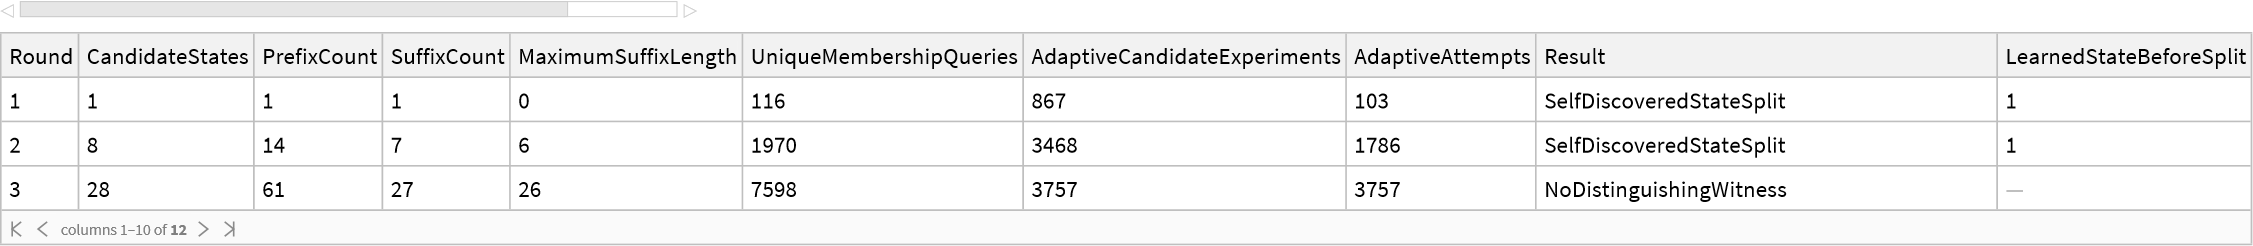

In [59]:
Dataset[
  learningRoundLogS118B
]

In [64]:
Dataset[
  challengePerKindS118B
]

Dataset[{<|Kind -> ExactShallow, Sequences -> 50, PositiveOutputs -> 50, 
 
>     NegativeOutputs -> 0, Matches -> 50, Accuracy -> 1.|>, 
 
>    <|Kind -> ExactDeep, Sequences -> 50, PositiveOutputs -> 50, NegativeOutputs -> 0, 
 
>     Matches -> 50, Accuracy -> 1.|>, 
 
>    <|Kind -> ShallowOneShort, Sequences -> 25, PositiveOutputs -> 0, 
 
>     NegativeOutputs -> 25, Matches -> 25, Accuracy -> 1.|>, 
 
>    <|Kind -> ShallowOneLong, Sequences -> 25, PositiveOutputs -> 0, 
 
>     NegativeOutputs -> 25, Matches -> 25, Accuracy -> 1.|>, 
 
>    <|Kind -> DeepOneShort, Sequences -> 25, PositiveOutputs -> 0, 
 
>     NegativeOutputs -> 25, Matches -> 25, Accuracy -> 1.|>, 
 
>    <|Kind -> DeepOneLong, Sequences -> 25, PositiveOutputs -> 0, 
 
>     NegativeOutputs -> 25, Matches -> 25, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Kind, Sequences, PositiveOutputs, 
 
>      NegativeOutputs, Matches, Accuracy}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real]}], 6], 
 
>   <||>]

In [69]:
Dataset[
  selectedBoundedProfileS118B
]

Dataset[{<|FutureDepth -> 0, BehaviorClasses -> 2|>, 
 
>    <|FutureDepth -> 1, BehaviorClasses -> 3|>, 
 
>    <|FutureDepth -> 2, BehaviorClasses -> 4|>, 
 
>    <|FutureDepth -> 4, BehaviorClasses -> 6|>, 
 
>    <|FutureDepth -> 8, BehaviorClasses -> 11|>, 
 
>    <|FutureDepth -> 12, BehaviorClasses -> 15|>, 
 
>    <|FutureDepth -> 16, BehaviorClasses -> 19|>, 
 
>    <|FutureDepth -> 20, BehaviorClasses -> 23|>, 
 
>    <|FutureDepth -> 24, BehaviorClasses -> 27|>, 
 
>    <|FutureDepth -> 28, BehaviorClasses -> 29|>, 
 
>    <|FutureDepth -> 32, BehaviorClasses -> 29|>, 
 
>    <|FutureDepth -> 36, BehaviorClasses -> 29|>, 
 
>    <|FutureDepth -> 40, BehaviorClasses -> 29|>, 
 
>    <|FutureDepth -> 44, BehaviorClasses -> 29|>, 
 
>    <|FutureDepth -> 48, BehaviorClasses -> 29|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{FutureDepth, BehaviorClasses}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 15], <||>]

In [74]:
Dataset[
  randomHoldoutPerDepthS118B
]

Dataset[{<|Depth -> 80, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 200, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 500, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 1000, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Sequences, Matches, Accuracy}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 4], <||>]

<|FixedProbeBankUsed -> False, Rounds -> 3, AdaptiveWitnesses -> 2, 
 
>   WitnessSuffixLengths -> {6, 26}, FinalAdaptiveCandidates -> 3757, 
 
>   FinalAdaptiveScanned -> 3757, AdaptiveFullScanInvariant -> True, 
 
>   MembershipQueries -> 7598, MembershipBySource -> 
 
>    <|Table -> 3120, AdaptiveExperiment -> 4478, RandomHoldout -> 400, 
 
>     ChallengeHoldout -> 200, Audit -> 9264|>, LearnedStates -> 28, 
 
>   MaxLearnedSuffix -> 26, RandomHoldoutTouched -> 0, ChallengeTouched -> 0, 
 
>   RandomHoldoutAccuracy -> 1., ChallengeAccuracy -> 1., ChallengePositive -> 100, 
 
>   ChallengeNegative -> 100, HiddenDeepDelayPostHoc -> 26, TrueStates -> 29, 
 
>   TrueMinimalStates -> 29, TrueMaxDistinguishingDepth -> 26, 
 
>   FirstFullSeparationDepth -> 26, ShortestLearnedDeepWitness -> 26, 
 
>   StateBijection -> False, TransitionMatches -> 29, TransitionTotal -> 84, 
 
>   AdaptiveStateSplit -> True, DeepAdaptiveWitness -> True, 
 
>   ExactMachineIsomorphism -> False, AllFiniteSequenceEquivalent -> False, 
 
>   ProspectiveStrong -> False, Diagnosis -> 
 
>    ADAPTIVE_EXPERIMENTS_FOUND_SOME_SPLITS_BUT_FAILED_TO_RECOVER_THE_TRUE_MINIMAL_STATE\
 
>     _SPACE|>
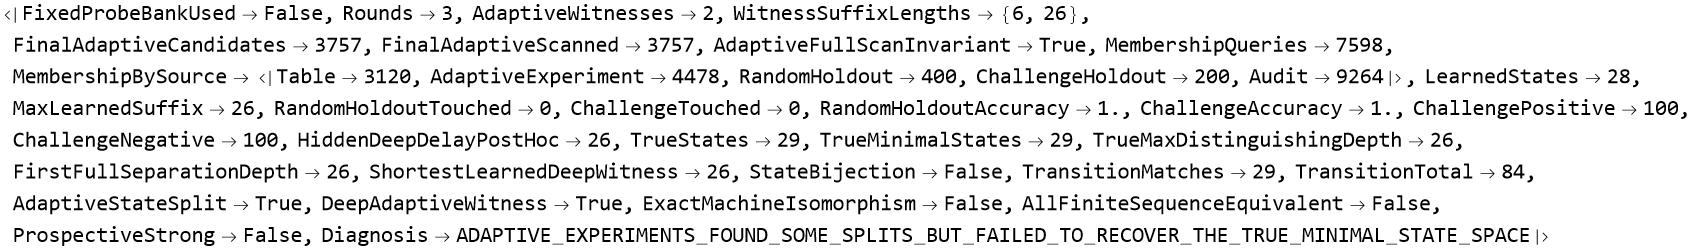

In [79]:
<|

  "FixedProbeBankUsed" ->
    fixedProbeBankUsedS118B,

  "Rounds" ->
    learningRoundS118B,

  "AdaptiveWitnesses" ->
    Length[
      adaptiveWitnessLogS118B
    ],

  "WitnessSuffixLengths" ->
    (
      #["SuffixLength"] &
    ) /@
      adaptiveWitnessLogS118B,

  "FinalAdaptiveCandidates" ->
    lastAdaptiveExperimentCountS118B,

  "FinalAdaptiveScanned" ->
    lastAdaptiveAttemptsThisRoundS118B,

  "AdaptiveFullScanInvariant" ->
    adaptiveFullScanInvariantPassedS118B,

  "MembershipQueries" ->
    membershipQueriesBeforeFreezeS118B,

  "MembershipBySource" ->
    membershipNewBySourceS118B,

  "LearnedStates" ->
    learnedStateCountS118B,

  "MaxLearnedSuffix" ->
    maxLearnedSuffixLengthS118B,

  "RandomHoldoutTouched" ->
    randomHoldoutTouchedBeforeFreezeS118B,

  "ChallengeTouched" ->
    challengeHoldoutTouchedBeforeFreezeS118B,

  "RandomHoldoutAccuracy" ->
    randomHoldoutAccuracyS118B,

  "ChallengeAccuracy" ->
    challengeAccuracyS118B,

  "ChallengePositive" ->
    challengePositiveCountS118B,

  "ChallengeNegative" ->
    challengeNegativeCountS118B,

  "HiddenDeepDelayPostHoc" ->
    hiddenDeepDepthS118B,

  "TrueStates" ->
    trueReachableCountS118B,

  "TrueMinimalStates" ->
    trueMinimalStateCountS118B,

  "TrueMaxDistinguishingDepth" ->
    trueMaxDistinguishingDepthS118B,

  "FirstFullSeparationDepth" ->
    firstFullSeparationDepthS118B,

  "ShortestLearnedDeepWitness" ->
    shortestLearnedDeepWitnessLengthS118B,

  "StateBijection" ->
    stateBijectionPassedS118B,

  "TransitionMatches" ->
    transitionMatchesS118B,

  "TransitionTotal" ->
    transitionTotalS118B,

  "AdaptiveStateSplit" ->
    adaptiveStateSplitConfirmedS118B,

  "DeepAdaptiveWitness" ->
    deepAdaptiveWitnessDiscoveredS118B,

  "ExactMachineIsomorphism" ->
    exactMachineIsomorphismS118B,

  "AllFiniteSequenceEquivalent" ->
    allFiniteSequenceEquivalentS118B,

  "ProspectiveStrong" ->
    prospectiveStrongS118B,

  "Diagnosis" ->
    diagnosisS118B

|>

<|RequiredRootSinkSuffix -> {2, 0, 0, 0, 0, 0, 0}, RequiredSuffixLength -> 7, 
 
>   SuffixExistsInAdaptiveLanguage -> False, TrueRootOutputUnderSuffix -> 1, 
 
>   TrueSinkOutputUnderSuffix -> 0, LearnedRootState -> 1, LearnedSinkState -> 1, 
 
>   RootAndSinkMergedByLearner -> True, 
 
>   CandidateGlobalCounterexample -> {2, 1, 2, 0, 0, 0, 0, 0, 0}, 
 
>   CandidateGlobalCounterexampleLength -> 9, LearnedYOnCounterexample -> 1, 
 
>   TrueYOnCounterexample -> 0|>
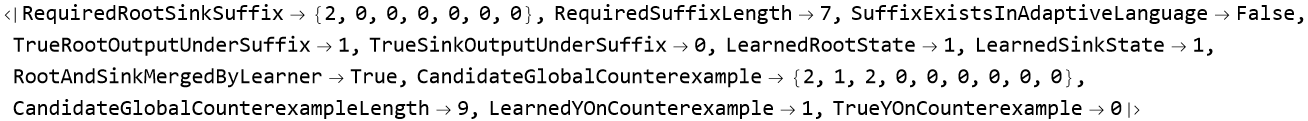

In [84]:
rootSinkSuffixS118B =
  Join[
    {
      hiddenShallowEntryTokenS118B
    },
    ConstantArray[
      hiddenCarryTokenS118B,
      hiddenShallowDepthS118B
    ]
  ];


sinkPrefixS118B =
  {
    hiddenShallowEntryTokenS118B,
    hiddenDeepEntryTokenS118B
  };


globalRootSinkCounterexampleS118B =
  Join[
    sinkPrefixS118B,
    rootSinkSuffixS118B
  ];


<|

  "RequiredRootSinkSuffix" ->
    rootSinkSuffixS118B,

  "RequiredSuffixLength" ->
    Length[
      rootSinkSuffixS118B
    ],

  "SuffixExistsInAdaptiveLanguage" ->
    MemberQ[
      S118BGenerateFutureSuffixes[],
      rootSinkSuffixS118B
    ],

  "TrueRootOutputUnderSuffix" ->
    S118BEnvOutputFromState[
      hiddenStartStateS118B,
      rootSinkSuffixS118B
    ],

  "TrueSinkOutputUnderSuffix" ->
    S118BEnvOutputFromState[
      2,
      rootSinkSuffixS118B
    ],

  "LearnedRootState" ->
    S118BHypothesisStateAfter[
      frozenHypothesisS118B,
      {}
    ],

  "LearnedSinkState" ->
    S118BHypothesisStateAfter[
      frozenHypothesisS118B,
      sinkPrefixS118B
    ],

  "RootAndSinkMergedByLearner" ->
    (
      S118BHypothesisStateAfter[
        frozenHypothesisS118B,
        {}
      ]
      ===
      S118BHypothesisStateAfter[
        frozenHypothesisS118B,
        sinkPrefixS118B
      ]
    ),

  "CandidateGlobalCounterexample" ->
    globalRootSinkCounterexampleS118B,

  "CandidateGlobalCounterexampleLength" ->
    Length[
      globalRootSinkCounterexampleS118B
    ],

  "LearnedYOnCounterexample" ->
    S118BHypothesisOutput[
      frozenHypothesisS118B,
      globalRootSinkCounterexampleS118B
    ],

  "TrueYOnCounterexample" ->
    S118BEnvRawOutput[
      globalRootSinkCounterexampleS118B
    ]

|>